# Intelligent Time-Series Forecasting and Anomaly Detection

## Project Overview

This project investigates statistical, machine learning, and deep learning
approaches for forecasting and detecting anomalies in time-series data.

The objective is to develop an intelligent framework that can:

1. Analyze temporal patterns such as trend and seasonality.
2. Forecast future observations.
3. Detect abnormal observations.
4. Compare different anomaly detection approaches.
5. Investigate a hybrid forecasting-based and machine-learning approach.
6. Explain why observations are considered anomalous.

The framework will be evaluated using labeled real-world time-series datasets.

## 1. Dataset and Data Loading

The Numenta Anomaly Benchmark (NAB) EC2 CPU utilization dataset is used as the primary time-series dataset for this project.

The dataset contains timestamped CPU utilization measurements collected at five-minute intervals. The data is inspected for its dimensions, data types, missing values, duplicate observations, and basic statistical properties before further analysis.

In [542]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [543]:
from pathlib import Path

# The notebook is inside the notebooks/ folder,
# so we go one level up (..) to reach the project folder.
data_path = Path("../data/nab/ec2_cpu_utilization_24ae8d.csv")

print("Current working directory:")
print(Path.cwd())

print("\nDataset exists:", data_path.exists())
print("Dataset path:", data_path)

Current working directory:
/Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/notebooks

Dataset exists: True
Dataset path: ../data/nab/ec2_cpu_utilization_24ae8d.csv


In [544]:
# Load the NAB EC2 CPU utilization dataset
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (4032, 2)


,timestamp,value
0,2014-02-14 14:30:00,0.132
1,2014-02-14 14:35:00,0.134
2,2014-02-14 14:40:00,0.134
3,2014-02-14 14:45:00,0.134
4,2014-02-14 14:50:00,0.134


In [545]:
# Basic information about the dataset
print("DATASET INFORMATION")
print("=" * 50)

print("\nData types:")
print(df.dtypes)

print("\nNumber of missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nStatistical summary:")
display(df.describe())

DATASET INFORMATION

Data types:
timestamp        str
value        float64
dtype: object

Number of missing values:
timestamp    0
value        0
dtype: int64

Duplicate rows:
0

Statistical summary:


,value
count,4032.000000
mean,0.126303
std,0.094813
min,0.066000
25%,0.132000
50%,0.134000
75%,0.134000
max,2.344000


## 2. Data Exploration

The dataset is first explored to understand its structure, data types, completeness, and statistical characteristics.

The analysis includes:

- Dataset dimensions and data types
- Missing-value inspection
- Duplicate-row inspection
- Descriptive statistics
- Distribution of CPU utilization
- Skewness and kurtosis
- Visualization of the complete time series

In [546]:
# Convert timestamp from string to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort chronologically
df = df.sort_values("timestamp").reset_index(drop=True)

print("Timestamp conversion completed!")
print("\nData types:")
print(df.dtypes)

print("\nStart time:", df["timestamp"].min())
print("End time:", df["timestamp"].max())

Timestamp conversion completed!

Data types:
timestamp    datetime64[us]
value               float64
dtype: object

Start time: 2014-02-14 14:30:00
End time: 2014-02-28 14:25:00


## 3. Data Preprocessing

Before modeling, the time-series data is prepared to ensure that the observations are suitable for temporal analysis.

The preprocessing steps include:

- Converting timestamps to datetime format
- Sorting observations chronologically
- Checking for missing values
- Checking for duplicate observations
- Verifying the regular sampling interval
- Resetting the dataframe index after sorting

In [547]:
# Calculate the time difference between consecutive observations
time_diff = df["timestamp"].diff().dropna()

print("Sampling interval:")
print(time_diff.value_counts())

print("\nMost common interval:", time_diff.mode()[0])

Sampling interval:
timestamp
0 days 00:05:00    4031
Name: count, dtype: int64

Most common interval: 0 days 00:05:00


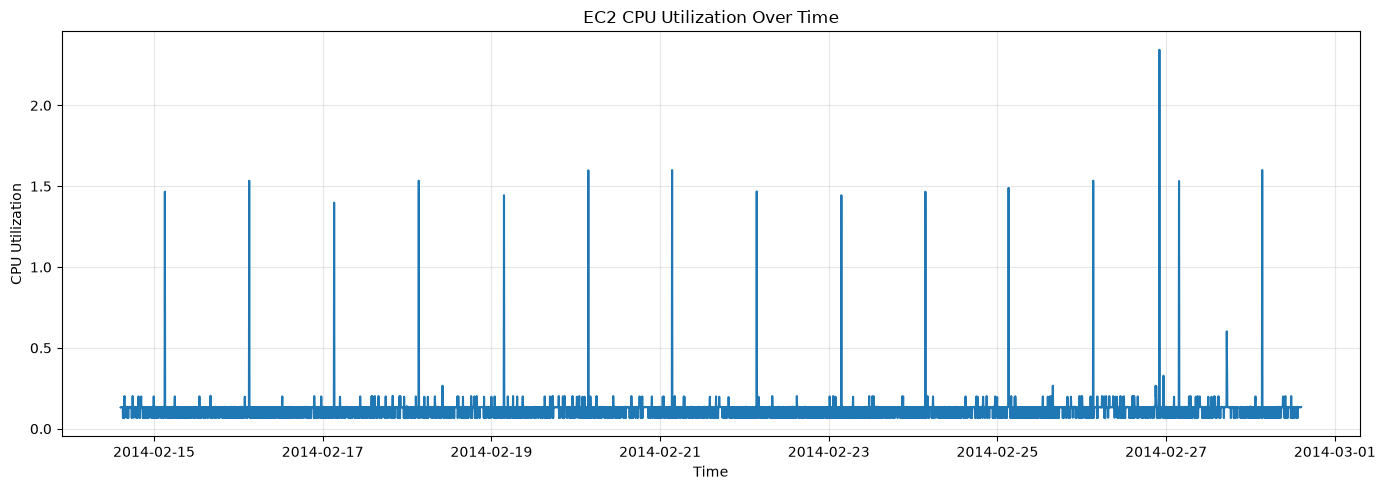

In [548]:
# Plot the complete time series

plt.figure(figsize=(14, 5))

plt.plot(df["timestamp"], df["value"])

plt.title("EC2 CPU Utilization Over Time")
plt.xlabel("Time")
plt.ylabel("CPU Utilization")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

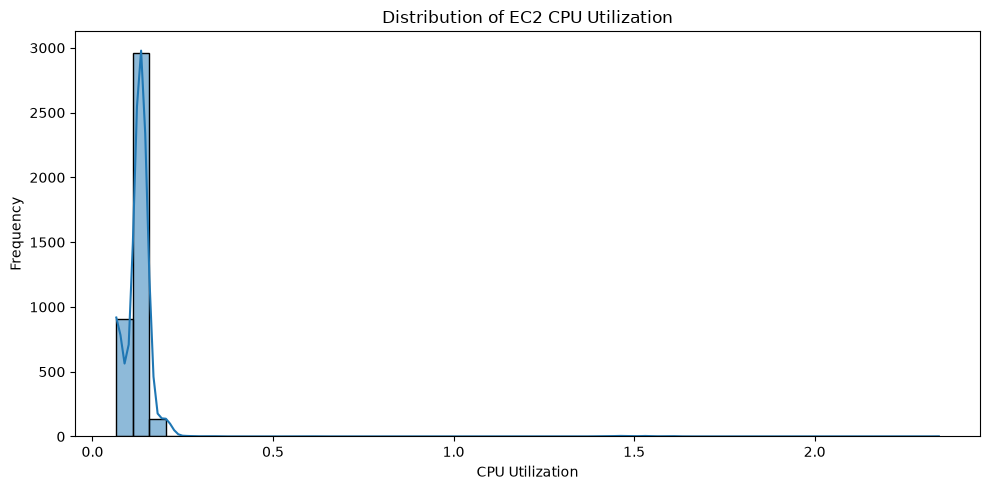

In [549]:
# Examine the distribution of CPU utilization

plt.figure(figsize=(10, 5))

sns.histplot(df["value"], bins=50, kde=True)

plt.title("Distribution of EC2 CPU Utilization")
plt.xlabel("CPU Utilization")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [550]:
# Quantify the distribution characteristics

print("Skewness:", df["value"].skew())
print("Kurtosis:", df["value"].kurtosis())

print("\nSelected quantiles:")
print(df["value"].quantile([0.50, 0.90, 0.95, 0.99, 0.995, 0.999]))

Skewness: 13.986968810505958
Kurtosis: 230.21221591641861

Selected quantiles:
0.500    0.13400
0.900    0.13400
0.950    0.13600
0.990    0.20200
0.995    0.26569
0.999    1.53400
Name: value, dtype: float64


## 4. Time-Series Analysis

The temporal structure of the CPU utilization series is analyzed before applying forecasting and anomaly-detection models.

The analysis includes:

- Rolling mean and rolling standard deviation
- Autocorrelation Function (ACF)
- Augmented Dickey-Fuller (ADF) stationarity test
- Partial Autocorrelation Function (PACF)

These analyses help identify temporal dependence, variability, stationarity, and potential lag relationships that can guide the selection of forecasting models.

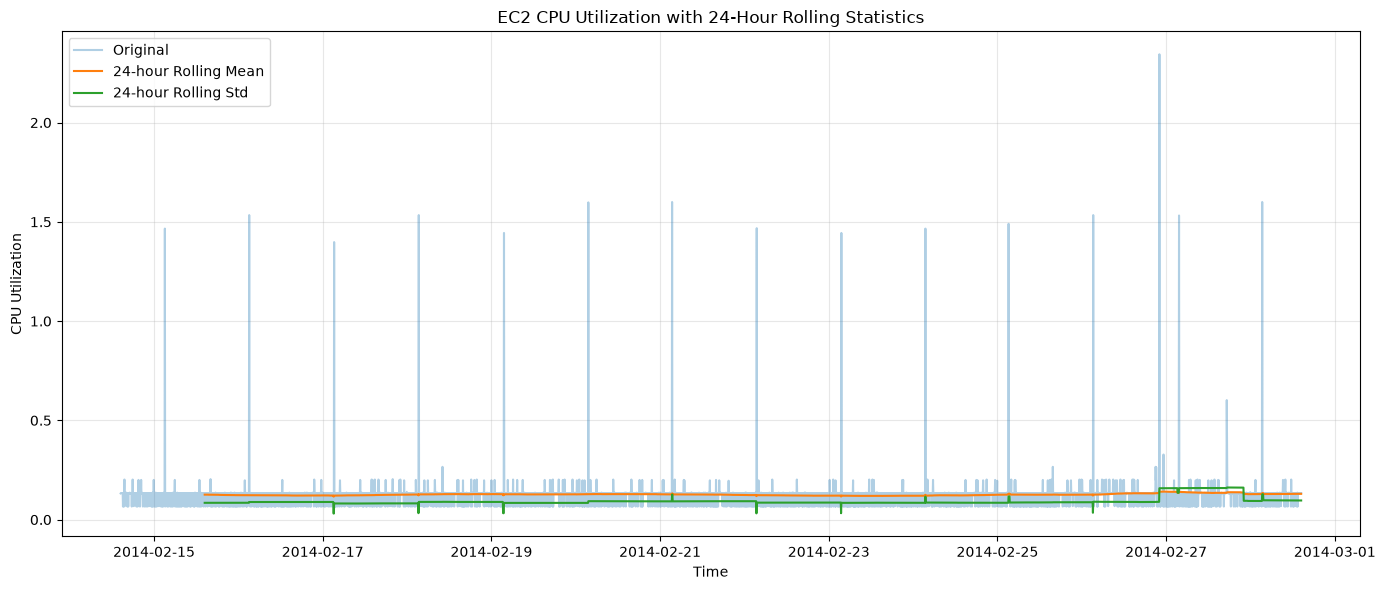

In [551]:
# Calculate rolling statistics

window = 288  # 288 five-minute observations = 24 hours

df["rolling_mean"] = df["value"].rolling(window=window).mean()
df["rolling_std"] = df["value"].rolling(window=window).std()

plt.figure(figsize=(14, 6))

plt.plot(df["timestamp"], df["value"], alpha=0.35, label="Original")
plt.plot(df["timestamp"], df["rolling_mean"], label="24-hour Rolling Mean")
plt.plot(df["timestamp"], df["rolling_std"], label="24-hour Rolling Std")

plt.title("EC2 CPU Utilization with 24-Hour Rolling Statistics")
plt.xlabel("Time")
plt.ylabel("CPU Utilization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

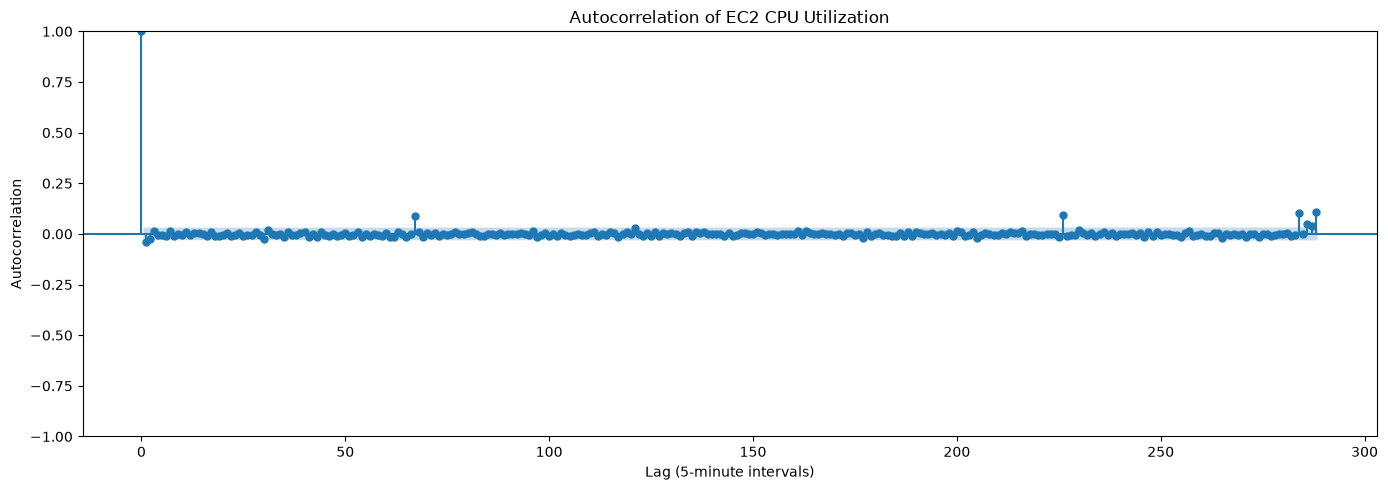

In [552]:
# Autocorrelation analysis

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(14, 5))

plot_acf(
    df["value"],
    lags=288,
    ax=plt.gca(),
    alpha=0.05
)

plt.title("Autocorrelation of EC2 CPU Utilization")
plt.xlabel("Lag (5-minute intervals)")
plt.ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

In [553]:
# Augmented Dickey-Fuller stationarity test

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df["value"])

print("AUGMENTED DICKEY-FULLER TEST")
print("=" * 40)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value}")

print("\nConclusion:")

if adf_result[1] < 0.05:
    print("The series appears to be STATIONARY (p-value < 0.05).")
else:
    print("The series appears to be NON-STATIONARY (p-value >= 0.05).")

AUGMENTED DICKEY-FULLER TEST
ADF Statistic: -46.92283631890562
p-value: 0.0

Critical Values:
  1%: -3.431973689863888
  5%: -2.862257457341372
  10%: -2.5671519099310998

Conclusion:
The series appears to be STATIONARY (p-value < 0.05).


/var/folders/r_/r_g8v2x15sx460lm4_7ybcnc0000gn/T/ipykernel_48352/1090399460.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(df["value"])


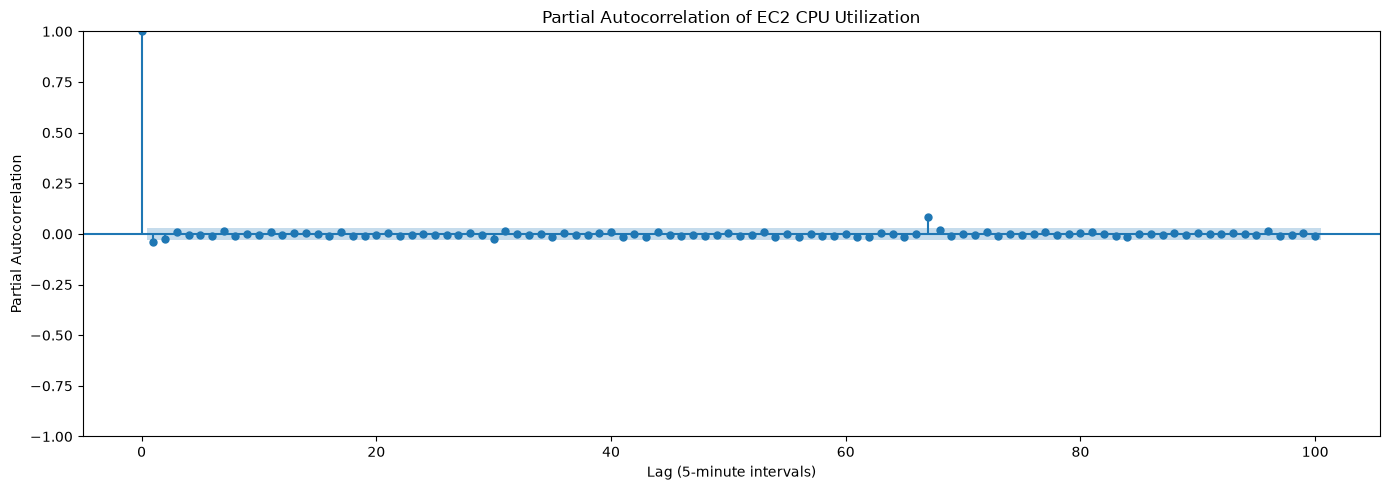

In [554]:
# Partial Autocorrelation Function (PACF)

from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(14, 5))

plot_pacf(
    df["value"],
    lags=100,
    ax=plt.gca(),
    alpha=0.05
)

plt.title("Partial Autocorrelation of EC2 CPU Utilization")
plt.xlabel("Lag (5-minute intervals)")
plt.ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

## 5. Initial Chronological Train-Test Split

An initial chronological train-test split is used to establish a baseline forecasting setup.

The observations are divided into consecutive training and testing periods rather than randomly shuffled. This preserves the temporal ordering of the data and prevents future observations from being used to predict the past.

This initial split is used for preliminary forecasting experiments. A separate leakage-safe train-validation-test split is introduced later for the final anomaly-detection evaluation.

In [555]:
# Chronological train-test split

split_index = int(len(df) * 0.80)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

print("TIME-SERIES TRAIN-TEST SPLIT")
print("=" * 40)

print("Total observations:", len(df))
print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train["timestamp"].min(), "to", train["timestamp"].max())

print("\nTesting period:")
print(test["timestamp"].min(), "to", test["timestamp"].max())

TIME-SERIES TRAIN-TEST SPLIT
Total observations: 4032
Training observations: 3225
Testing observations: 807

Training period:
2014-02-14 14:30:00 to 2014-02-25 19:10:00

Testing period:
2014-02-25 19:15:00 to 2014-02-28 14:25:00


## 6. Naive Forecasting Baseline

A naive forecasting model is used as a simple baseline for evaluating forecasting performance.

The naive method assumes that the next observation will be equal to the most recently observed value. Although simple, this baseline provides a useful reference point for determining whether more advanced forecasting methods such as ARIMA provide meaningful improvement.

In [556]:
# Naive forecasting baseline
# Prediction = previous observed value

test_naive = test.copy()

test_naive["prediction"] = df["value"].shift(1).iloc[test.index]

print("NAIVE FORECAST BASELINE")
print("=" * 40)

print(test_naive[["timestamp", "value", "prediction"]].head(10))

NAIVE FORECAST BASELINE
               timestamp  value  prediction
3225 2014-02-25 19:15:00  0.136       0.134
3226 2014-02-25 19:20:00  0.134       0.136
3227 2014-02-25 19:25:00  0.132       0.134
3228 2014-02-25 19:30:00  0.132       0.132
3229 2014-02-25 19:35:00  0.066       0.132
3230 2014-02-25 19:40:00  0.134       0.066
3231 2014-02-25 19:45:00  0.134       0.134
3232 2014-02-25 19:50:00  0.134       0.134
3233 2014-02-25 19:55:00  0.198       0.134
3234 2014-02-25 20:00:00  0.134       0.198


In [557]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_naive = mean_absolute_error(
    test_naive["value"],
    test_naive["prediction"]
)

rmse_naive = np.sqrt(
    mean_squared_error(
        test_naive["value"],
        test_naive["prediction"]
    )
)

print("NAIVE FORECAST PERFORMANCE")
print("=" * 40)

print("MAE :", mae_naive)
print("RMSE:", rmse_naive)

NAIVE FORECAST PERFORMANCE
MAE : 0.050978934324659234
RMSE: 0.17517269227524906


## 7. ARIMA Forecasting

Autoregressive Integrated Moving Average (ARIMA) is used as the primary statistical forecasting model.

The ARIMA model combines:

- **AR (Autoregression):** uses previous observations to model the current value.
- **I (Integration):** handles non-stationarity through differencing when required.
- **MA (Moving Average):** uses previous forecasting errors to improve predictions.

The stationarity analysis indicated that the series is already stationary, so the initial ARIMA models use `d = 0`.

Several low-order ARIMA configurations are compared using information criteria such as AIC and BIC, followed by out-of-sample forecasting evaluation.

In [558]:
from statsmodels.tsa.arima.model import ARIMA

# Candidate ARIMA orders
arima_orders = [
    (0, 0, 0),
    (1, 0, 0),
    (0, 0, 1),
    (1, 0, 1),
    (2, 0, 0),
    (0, 0, 2),
    (2, 0, 1),
    (1, 0, 2)
]

arima_results = []

for order in arima_orders:
    print(f"Fitting ARIMA{order}...")

    try:
        model = ARIMA(
            train["value"],
            order=order
        )

        fitted_model = model.fit()

        arima_results.append({
            "order": order,
            "AIC": fitted_model.aic,
            "BIC": fitted_model.bic
        })

    except Exception as e:
        print(f"ARIMA{order} failed: {e}")

arima_results_df = pd.DataFrame(arima_results)

print("\nARIMA MODEL COMPARISON")
print("=" * 50)

print(
    arima_results_df
    .sort_values("AIC")
    .to_string(index=False)
)

Fitting ARIMA(0, 0, 0)...
Fitting ARIMA(1, 0, 0)...
Fitting ARIMA(0, 0, 1)...
Fitting ARIMA(1, 0, 1)...
Fitting ARIMA(2, 0, 0)...
Fitting ARIMA(0, 0, 2)...
Fitting ARIMA(2, 0, 1)...
Fitting ARIMA(1, 0, 2)...

ARIMA MODEL COMPARISON
    order          AIC          BIC
(0, 0, 1) -6652.870823 -6634.634758
(1, 0, 0) -6652.434529 -6634.198464
(2, 0, 0) -6652.402036 -6628.087284
(0, 0, 2) -6652.212986 -6627.898233
(1, 0, 1) -6651.772435 -6627.457682
(1, 0, 2) -6650.812554 -6620.419113
(2, 0, 1) -6650.807664 -6620.414223
(0, 0, 0) -6645.186516 -6633.029139


/Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [559]:
# Evaluate selected ARIMA models on the test set

candidate_orders = [
    (0, 0, 1),
    (1, 0, 0),
    (2, 0, 0),
    (0, 0, 2),
    (1, 0, 1)
]

forecast_results = []

for order in candidate_orders:

    print(f"Forecasting with ARIMA{order}...")

    model = ARIMA(
        train["value"],
        order=order
    )

    fitted_model = model.fit()

    # Forecast the complete test period
    forecast = fitted_model.forecast(
        steps=len(test)
    )

    mae = mean_absolute_error(
        test["value"],
        forecast
    )

    rmse = np.sqrt(
        mean_squared_error(
            test["value"],
            forecast
        )
    )

    forecast_results.append({
        "Model": f"ARIMA{order}",
        "MAE": mae,
        "RMSE": rmse
    })

arima_forecast_results = pd.DataFrame(forecast_results)

# Add the Naive baseline
arima_forecast_results = pd.concat([
    pd.DataFrame([{
        "Model": "Naive",
        "MAE": mae_naive,
        "RMSE": rmse_naive
    }]),
    arima_forecast_results
], ignore_index=True)

print("\nFORECASTING PERFORMANCE COMPARISON")
print("=" * 60)

print(
    arima_forecast_results
    .sort_values("RMSE")
    .to_string(index=False)
)

Forecasting with ARIMA(0, 0, 1)...
Forecasting with ARIMA(1, 0, 0)...
Forecasting with ARIMA(2, 0, 0)...
Forecasting with ARIMA(0, 0, 2)...
Forecasting with ARIMA(1, 0, 1)...

FORECASTING PERFORMANCE COMPARISON
         Model      MAE     RMSE
ARIMA(1, 0, 0) 0.031119 0.123077
ARIMA(0, 0, 2) 0.031120 0.123077
ARIMA(2, 0, 0) 0.031120 0.123077
ARIMA(0, 0, 1) 0.031121 0.123077
ARIMA(1, 0, 1) 0.031121 0.123077
         Naive 0.050979 0.175173


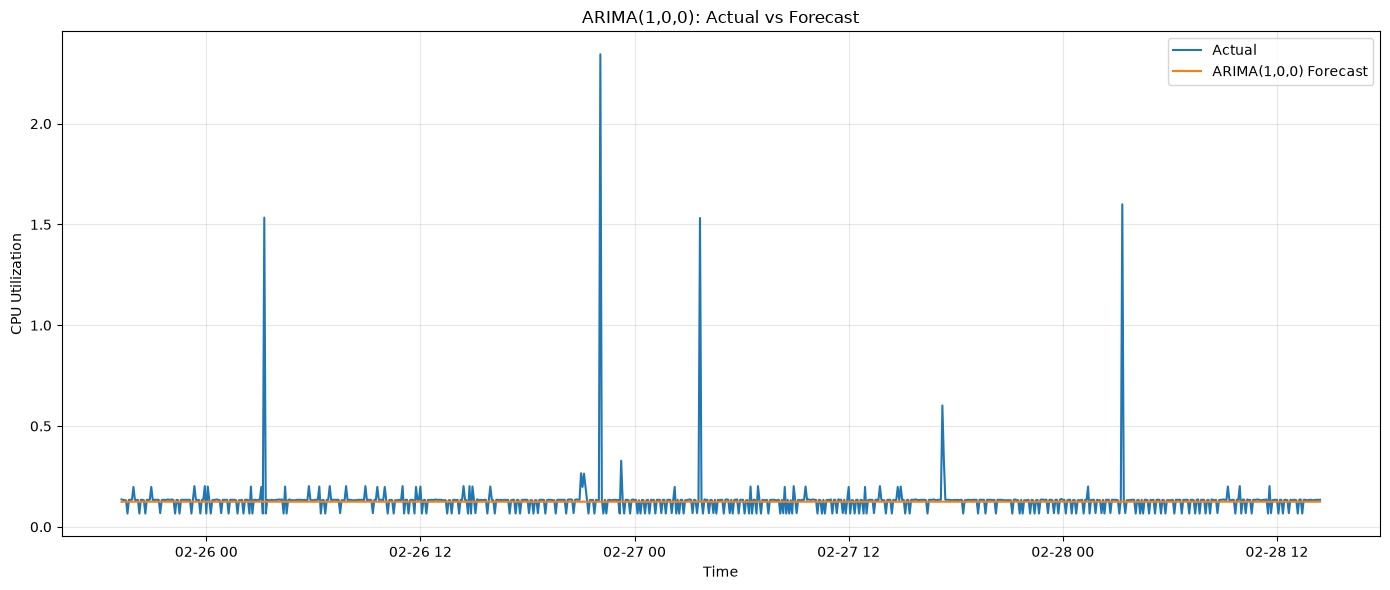

In [560]:
# Fit the best ARIMA model and visualize its forecast

best_arima_order = (1, 0, 0)

best_arima = ARIMA(
    train["value"],
    order=best_arima_order
)

best_arima_fitted = best_arima.fit()

# Forecast the test period
arima_forecast = best_arima_fitted.forecast(
    steps=len(test)
)

# Plot actual vs forecast
plt.figure(figsize=(14, 6))

plt.plot(
    test["timestamp"],
    test["value"],
    label="Actual"
)

plt.plot(
    test["timestamp"],
    arima_forecast,
    label="ARIMA(1,0,0) Forecast"
)

plt.title("ARIMA(1,0,0): Actual vs Forecast")
plt.xlabel("Time")
plt.ylabel("CPU Utilization")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. ARIMA Residual-Based Anomaly Detection

The ARIMA forecasting model is extended into an anomaly-detection method by analyzing its forecasting errors.

For each observation, the forecasting error is calculated as:

\[
e_t = y_t - \hat{y}_t
\]

where:

- \(y_t\) is the actual observation.
- \(\hat{y}_t\) is the ARIMA forecast.
- \(e_t\) is the forecasting residual.

Large absolute residuals indicate observations that differ substantially from the expected behavior of the time-series.

An anomaly threshold is determined from the training residual distribution. The threshold is fixed before evaluating the final test set to avoid test-set leakage.

In [561]:
# Calculate forecasting errors

test_results = test.copy()

test_results["forecast"] = arima_forecast.values

test_results["error"] = (
    test_results["value"] - test_results["forecast"]
)

test_results["absolute_error"] = (
    test_results["error"].abs()
)

print("FORECASTING ERROR ANALYSIS")
print("=" * 50)

print(test_results[
    ["timestamp", "value", "forecast", "error", "absolute_error"]
].head(10))

FORECASTING ERROR ANALYSIS
               timestamp  value  forecast     error  absolute_error
3225 2014-02-25 19:15:00  0.136  0.124104  0.011896        0.011896
3226 2014-02-25 19:20:00  0.134  0.124634  0.009366        0.009366
3227 2014-02-25 19:25:00  0.132  0.124605  0.007395        0.007395
3228 2014-02-25 19:30:00  0.132  0.124607  0.007393        0.007393
3229 2014-02-25 19:35:00  0.066  0.124607 -0.058607        0.058607
3230 2014-02-25 19:40:00  0.134  0.124607  0.009393        0.009393
3231 2014-02-25 19:45:00  0.134  0.124607  0.009393        0.009393
3232 2014-02-25 19:50:00  0.134  0.124607  0.009393        0.009393
3233 2014-02-25 19:55:00  0.198  0.124607  0.073393        0.073393
3234 2014-02-25 20:00:00  0.134  0.124607  0.009393        0.009393


In [562]:
# Determine anomaly threshold from training residuals

train_residuals = best_arima_fitted.resid

threshold = np.quantile(
    np.abs(train_residuals),
    0.99
)

print("ANOMALY THRESHOLD")
print("=" * 40)

print("99th percentile threshold:", threshold)

ANOMALY THRESHOLD
99th percentile threshold: 0.07778886209286896


In [563]:
# Detect anomalies using forecasting error

test_results["anomaly"] = (
    test_results["absolute_error"] > threshold
)

print("FORECASTING-BASED ANOMALY DETECTION")
print("=" * 50)

print("Threshold:", threshold)

print(
    "Detected anomalies:",
    test_results["anomaly"].sum()
)

print(
    "Percentage of test observations flagged:",
    round(test_results["anomaly"].mean() * 100, 2),
    "%"
)

FORECASTING-BASED ANOMALY DETECTION
Threshold: 0.07778886209286896
Detected anomalies: 9
Percentage of test observations flagged: 1.12 %


In [564]:
# Display observations with the largest forecasting errors

top_anomalies = test_results.sort_values(
    "absolute_error",
    ascending=False
).head(15)

print(top_anomalies[
    ["timestamp", "value", "forecast", "absolute_error", "anomaly"]
].to_string(index=False))

          timestamp  value  forecast  absolute_error  anomaly
2014-02-26 22:05:00  2.344  0.124607        2.219393     True
2014-02-28 03:20:00  1.600  0.124607        1.475393     True
2014-02-26 03:15:00  1.534  0.124607        1.409393     True
2014-02-27 03:40:00  1.532  0.124607        1.407393     True
2014-02-27 17:15:00  0.602  0.124607        0.477393     True
2014-02-27 17:20:00  0.332  0.124607        0.207393     True
2014-02-26 23:15:00  0.328  0.124607        0.203393     True
2014-02-26 21:00:00  0.266  0.124607        0.141393     True
2014-02-26 21:10:00  0.264  0.124607        0.139393     True
2014-02-26 14:45:00  0.202  0.124607        0.077393    False
2014-02-28 11:35:00  0.202  0.124607        0.077393    False
2014-02-26 05:45:00  0.202  0.124607        0.077393    False
2014-02-26 11:00:00  0.202  0.124607        0.077393    False
2014-02-26 07:50:00  0.202  0.124607        0.077393    False
2014-02-27 13:45:00  0.202  0.124607        0.077393    False


In [565]:
# Load NAB ground-truth anomaly labels

import json

labels_path = Path("../data/nab/combined_labels.json")

with open(labels_path, "r") as f:
    nab_labels = json.load(f)

# Find the label entry corresponding to our dataset
dataset_key = "realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv"

print("Dataset key found:", dataset_key in nab_labels)

print("\nGround-truth labels:")
print(nab_labels[dataset_key])

Dataset key found: True

Ground-truth labels:
['2014-02-26 22:05:00', '2014-02-27 17:15:00']


In [566]:
# Create ground-truth anomaly labels

test_results["ground_truth"] = (
    test_results["timestamp"].isin(
        pd.to_datetime(nab_labels[dataset_key])
    )
).astype(int)

print("GROUND-TRUTH LABELS")
print("=" * 50)

print(
    "Actual labeled anomalies in test set:",
    test_results["ground_truth"].sum()
)

print("\nLabeled anomaly timestamps:")

print(
    test_results[
        test_results["ground_truth"] == 1
    ][
        ["timestamp", "value", "forecast", "absolute_error"]
    ].to_string(index=False)
)

GROUND-TRUTH LABELS
Actual labeled anomalies in test set: 2

Labeled anomaly timestamps:
          timestamp  value  forecast  absolute_error
2014-02-26 22:05:00  2.344  0.124607        2.219393
2014-02-27 17:15:00  0.602  0.124607        0.477393


In [567]:
# Evaluate forecasting-based anomaly detection

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_true = test_results["ground_truth"]
y_pred = test_results["anomaly"].astype(int)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

cm = confusion_matrix(
    y_true,
    y_pred
)

print("FORECASTING-BASED ANOMALY DETECTION")
print("=" * 55)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

FORECASTING-BASED ANOMALY DETECTION
Precision : 0.2222
Recall    : 1.0000
F1-score  : 0.3636

Confusion Matrix:
[[798   7]
 [  0   2]]


In [568]:
# Calculate ROC-AUC using forecasting error as anomaly score

from sklearn.metrics import roc_auc_score

anomaly_scores = test_results["absolute_error"]

roc_auc = roc_auc_score(
    y_true,
    anomaly_scores
)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.9981


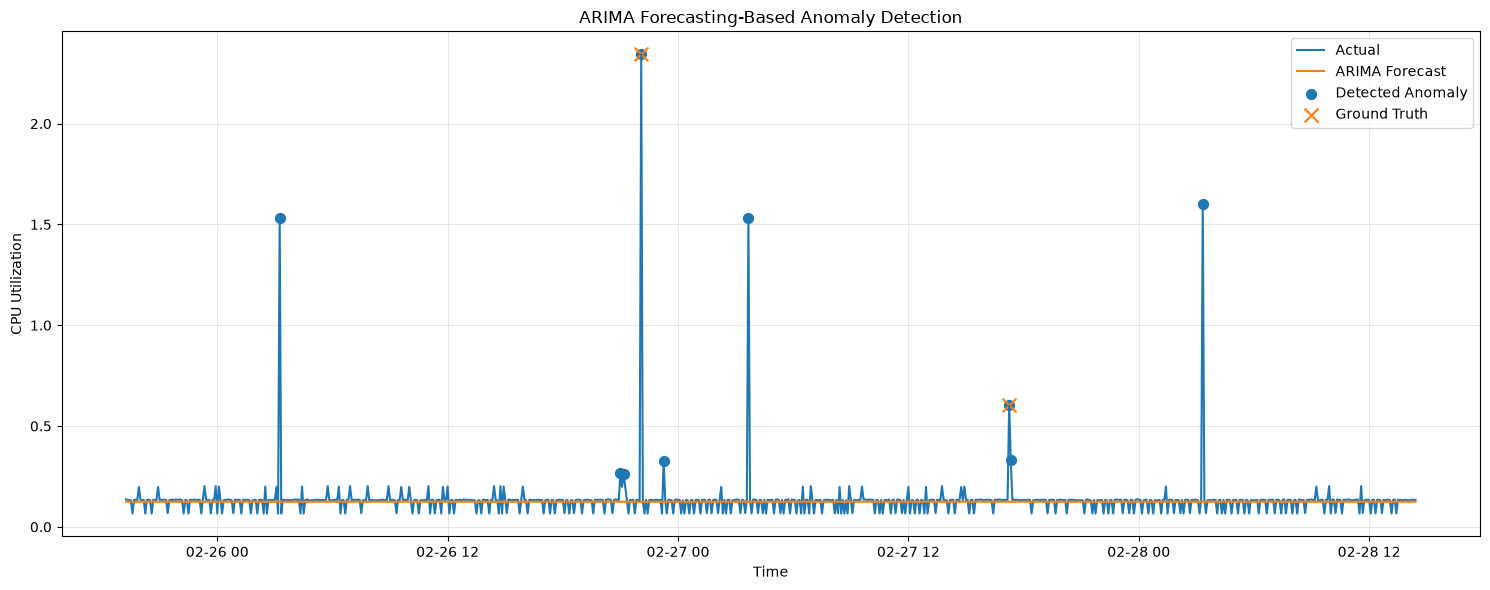

In [569]:
# Visualize forecasting-based anomaly detection

plt.figure(figsize=(15, 6))

# Actual test series
plt.plot(
    test_results["timestamp"],
    test_results["value"],
    label="Actual"
)

# Forecast
plt.plot(
    test_results["timestamp"],
    test_results["forecast"],
    label="ARIMA Forecast"
)

# Detected anomalies
detected = test_results[
    test_results["anomaly"]
]

plt.scatter(
    detected["timestamp"],
    detected["value"],
    label="Detected Anomaly",
    s=50
)

# Ground-truth anomalies
ground_truth = test_results[
    test_results["ground_truth"] == 1
]

plt.scatter(
    ground_truth["timestamp"],
    ground_truth["value"],
    label="Ground Truth",
    marker="x",
    s=100
)

plt.title(
    "ARIMA Forecasting-Based Anomaly Detection"
)

plt.xlabel("Time")
plt.ylabel("CPU Utilization")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [570]:
# ========================================
# STATISTICAL ANOMALY DETECTION
# Rolling Z-Score
# ========================================

window = 288  # 24 hours (5-minute observations)

# Calculate rolling statistics
test_results["rolling_mean"] = (
    test_results["value"]
    .rolling(window=window, min_periods=1)
    .mean()
)

test_results["rolling_std"] = (
    test_results["value"]
    .rolling(window=window, min_periods=1)
    .std()
)

# Calculate rolling Z-score
test_results["z_score"] = (
    (test_results["value"] - test_results["rolling_mean"])
    / test_results["rolling_std"]
)

# Handle division by zero
test_results["z_score"] = (
    test_results["z_score"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# Use |Z| > 3 as the initial anomaly threshold
z_threshold = 3

test_results["statistical_anomaly"] = (
    test_results["z_score"].abs() > z_threshold
)

print("STATISTICAL ANOMALY DETECTION")
print("=" * 50)
print("Rolling window:", window, "observations")
print("Window duration: 24 hours")
print("Z-score threshold:", z_threshold)

print(
    "Detected anomalies:",
    test_results["statistical_anomaly"].sum()
)

print(
    "Percentage of test observations flagged:",
    round(
        test_results["statistical_anomaly"].mean() * 100,
        2
    ),
    "%"
)

STATISTICAL ANOMALY DETECTION
Rolling window: 288 observations
Window duration: 24 hours
Z-score threshold: 3
Detected anomalies: 4
Percentage of test observations flagged: 0.5 %


In [571]:
# ========================================
# EVALUATE STATISTICAL ANOMALY DETECTION
# ========================================

y_true = test_results["ground_truth"].astype(int)
y_pred_stat = test_results["statistical_anomaly"].astype(int)

precision_stat = precision_score(
    y_true,
    y_pred_stat,
    zero_division=0
)

recall_stat = recall_score(
    y_true,
    y_pred_stat,
    zero_division=0
)

f1_stat = f1_score(
    y_true,
    y_pred_stat,
    zero_division=0
)

roc_auc_stat = roc_auc_score(
    y_true,
    test_results["z_score"].abs()
)

print("STATISTICAL ANOMALY DETECTION PERFORMANCE")
print("=" * 55)

print(f"Precision : {precision_stat:.4f}")
print(f"Recall    : {recall_stat:.4f}")
print(f"F1-score  : {f1_stat:.4f}")
print(f"ROC-AUC   : {roc_auc_stat:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_true,
        y_pred_stat
    )
)

STATISTICAL ANOMALY DETECTION PERFORMANCE
Precision : 0.2500
Recall    : 0.5000
F1-score  : 0.3333
ROC-AUC   : 0.9981

Confusion Matrix:
[[802   3]
 [  1   1]]


In [572]:
# ========================================
# FEATURE ENGINEERING FOR MACHINE LEARNING
# ========================================

ml_data = test_results.copy()

# Lag features
ml_data["lag_1"] = ml_data["value"].shift(1)
ml_data["lag_12"] = ml_data["value"].shift(12)
ml_data["lag_288"] = ml_data["value"].shift(288)

# Rolling features
ml_data["rolling_mean_24h"] = (
    ml_data["value"].rolling(288).mean()
)

ml_data["rolling_std_24h"] = (
    ml_data["value"].rolling(288).std()
)

# Deviation from recent mean
ml_data["deviation_from_mean"] = (
    ml_data["value"] - ml_data["rolling_mean_24h"]
)

# Time-based features
ml_data["hour"] = ml_data["timestamp"].dt.hour
ml_data["day_of_week"] = ml_data["timestamp"].dt.dayofweek

# Remove rows with missing lag/rolling values
ml_data = ml_data.dropna().reset_index(drop=True)

print("MACHINE LEARNING FEATURE ENGINEERING")
print("=" * 50)

print("Number of observations:", len(ml_data))

print("\nFeatures used:")
features = [
    "value",
    "lag_1",
    "lag_12",
    "lag_288",
    "rolling_mean_24h",
    "rolling_std_24h",
    "deviation_from_mean",
    "hour",
    "day_of_week"
]

for feature in features:
    print("-", feature)

MACHINE LEARNING FEATURE ENGINEERING
Number of observations: 519

Features used:
- value
- lag_1
- lag_12
- lag_288
- rolling_mean_24h
- rolling_std_24h
- deviation_from_mean
- hour
- day_of_week


## 9. Isolation Forest — V1

Isolation Forest is introduced as a machine-learning approach for unsupervised anomaly detection.

Unlike ARIMA, which detects anomalies through forecasting errors, Isolation Forest identifies observations that are easier to separate from the majority of the data.

The first version uses a combination of:

- Current CPU utilization
- Lagged observations
- 24-hour rolling statistics
- Deviation from the rolling mean
- Hour of day
- Day of week

The model is trained only on the chronological training period. An anomaly threshold is then determined from the training anomaly-score distribution and kept fixed for final test evaluation.

In [573]:
# ========================================
# ISOLATION FOREST ANOMALY DETECTION
# ========================================

X = ml_data[features]

# Create Isolation Forest model
iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.01,
    random_state=42
)

# Train the model
iso_forest.fit(X)

# Generate anomaly predictions
# 1  = normal
# -1 = anomaly
ml_data["if_prediction"] = iso_forest.predict(X)

# Convert prediction into True/False
ml_data["if_anomaly"] = (
    ml_data["if_prediction"] == -1
)

# Generate continuous anomaly score
# Higher value = more anomalous
ml_data["if_score"] = -iso_forest.decision_function(X)

print("ISOLATION FOREST ANOMALY DETECTION")
print("=" * 50)

print("Number of observations:", len(ml_data))
print("Number of trees:", 300)
print("Contamination:", 0.01)

print(
    "Detected anomalies:",
    ml_data["if_anomaly"].sum()
)

print(
    "Percentage flagged:",
    round(
        ml_data["if_anomaly"].mean() * 100,
        2
    ),
    "%"
)

ISOLATION FOREST ANOMALY DETECTION
Number of observations: 519
Number of trees: 300
Contamination: 0.01
Detected anomalies: 6
Percentage flagged: 1.16 %


In [574]:
# ========================================
# EVALUATE ISOLATION FOREST
# ========================================

y_true_if = ml_data["ground_truth"].astype(int)
y_pred_if = ml_data["if_anomaly"].astype(int)

precision_if = precision_score(
    y_true_if,
    y_pred_if,
    zero_division=0
)

recall_if = recall_score(
    y_true_if,
    y_pred_if,
    zero_division=0
)

f1_if = f1_score(
    y_true_if,
    y_pred_if,
    zero_division=0
)

roc_auc_if = roc_auc_score(
    y_true_if,
    ml_data["if_score"]
)

print("ISOLATION FOREST PERFORMANCE")
print("=" * 55)

print(f"Precision : {precision_if:.4f}")
print(f"Recall    : {recall_if:.4f}")
print(f"F1-score  : {f1_if:.4f}")
print(f"ROC-AUC   : {roc_auc_if:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_true_if,
        y_pred_if
    )
)

ISOLATION FOREST PERFORMANCE
Precision : 0.1667
Recall    : 0.5000
F1-score  : 0.2500
ROC-AUC   : 0.9913

Confusion Matrix:
[[512   5]
 [  1   1]]


In [575]:
# ========================================
# INSPECT ISOLATION FOREST DETECTIONS
# ========================================

if_anomalies = ml_data[
    ml_data["if_anomaly"]
].sort_values(
    "if_score",
    ascending=False
)

print("ISOLATION FOREST DETECTED ANOMALIES")
print("=" * 70)

print(
    if_anomalies[
        [
            "timestamp",
            "value",
            "ground_truth",
            "if_score",
            "deviation_from_mean"
        ]
    ].to_string(index=False)
)

ISOLATION FOREST DETECTED ANOMALIES
          timestamp  value  ground_truth  if_score  deviation_from_mean
2014-02-26 22:05:00  2.344             1  0.100268             2.203014
2014-02-28 03:20:00  1.600             0  0.083032             1.466104
2014-02-27 03:40:00  1.532             0  0.034926             1.392208
2014-02-27 03:15:00  0.068             0  0.028935            -0.066924
2014-02-26 22:10:00  0.134             0  0.013438            -0.006993
2014-02-27 17:20:00  0.332             0  0.000192             0.194389


In [576]:
# ========================================
# ARIMA THRESHOLD SENSITIVITY ANALYSIS
# ========================================

percentiles = [
    90,
    92,
    94,
    95,
    96,
    97,
    98,
    99,
    99.5
]

threshold_results = []

for percentile in percentiles:

    threshold_value = np.percentile(
        np.abs(train_residuals),
        percentile
    )

    predictions = (
        test_results["absolute_error"] > threshold_value
    ).astype(int)

    precision = precision_score(
        y_true,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "Percentile": percentile,
        "Threshold": threshold_value,
        "Detected": predictions.sum(),
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

print("ARIMA THRESHOLD SENSITIVITY")
print("=" * 75)

print(
    threshold_df.to_string(index=False)
)

ARIMA THRESHOLD SENSITIVITY
 Percentile  Threshold  Detected  Precision  Recall       F1
       90.0   0.058104       175   0.011429     1.0 0.022599
       92.0   0.058211       175   0.011429     1.0 0.022599
       94.0   0.058211       175   0.011429     1.0 0.022599
       95.0   0.058211       175   0.011429     1.0 0.022599
       96.0   0.058211       175   0.011429     1.0 0.022599
       97.0   0.072257        48   0.041667     1.0 0.080000
       98.0   0.074257        36   0.055556     1.0 0.105263
       99.0   0.077789         9   0.222222     1.0 0.363636
       99.5   0.082173         9   0.222222     1.0 0.363636


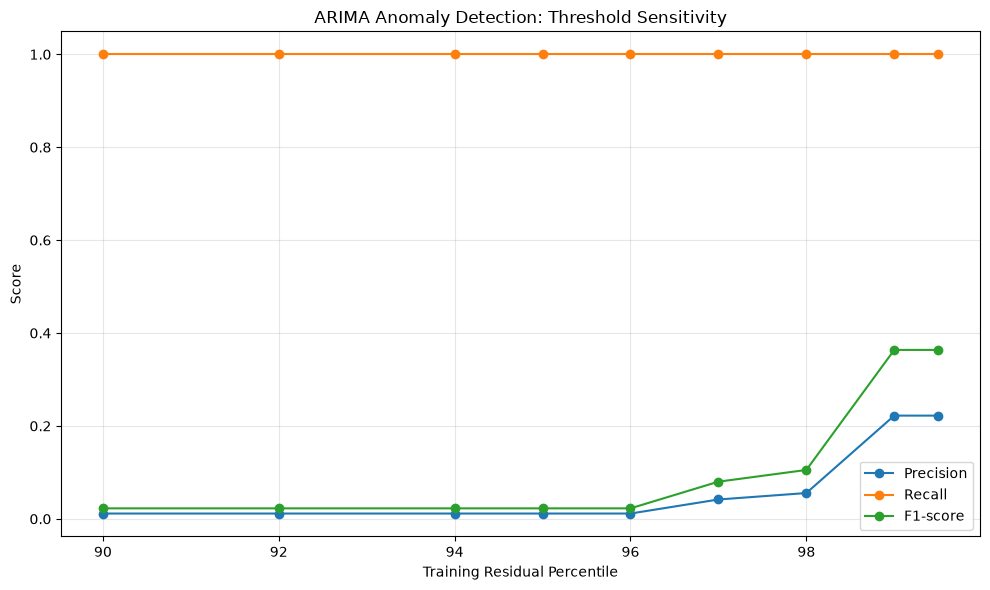

In [577]:
# ========================================
# THRESHOLD PERFORMANCE CURVES
# ========================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Percentile"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Percentile"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Percentile"],
    threshold_df["F1"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Training Residual Percentile")
plt.ylabel("Score")

plt.title(
    "ARIMA Anomaly Detection: Threshold Sensitivity"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [578]:
# ========================================
# CHECK CURRENT DATASET STRUCTURE
# ========================================

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nTime range:")
print(df["timestamp"].min())
print("to")
print(df["timestamp"].max())

print("\nNumber of observations:", len(df))

Dataset shape: (4032, 4)

Columns:
['timestamp', 'value', 'rolling_mean', 'rolling_std']

Time range:
2014-02-14 14:30:00
to
2014-02-28 14:25:00

Number of observations: 4032


In [579]:
# ========================================
# CLEAN DATASET & FINAL EXPERIMENTAL SPLIT
# ========================================

# Reload the original dataset
clean_df = pd.read_csv(
    "../data/nab/ec2_cpu_utilization_24ae8d.csv"
)

# Convert timestamp
clean_df["timestamp"] = pd.to_datetime(
    clean_df["timestamp"]
)

# Sort chronologically
clean_df = clean_df.sort_values(
    "timestamp"
).reset_index(drop=True)

# Make sure there are no accidental derived columns
clean_df = clean_df[
    ["timestamp", "value"]
]

# Calculate split sizes
n = len(clean_df)

train_end = int(n * 0.60)
validation_end = int(n * 0.80)

# Chronological split
train_clean = clean_df.iloc[:train_end].copy()

validation_clean = clean_df.iloc[
    train_end:validation_end
].copy()

test_clean = clean_df.iloc[
    validation_end:
].copy()

print("FINAL EXPERIMENTAL SPLIT")
print("=" * 50)

print("Total observations:", n)

print("\nTraining observations:", len(train_clean))
print(
    "Training period:",
    train_clean["timestamp"].min(),
    "to",
    train_clean["timestamp"].max()
)

print("\nValidation observations:", len(validation_clean))
print(
    "Validation period:",
    validation_clean["timestamp"].min(),
    "to",
    validation_clean["timestamp"].max()
)

print("\nFinal test observations:", len(test_clean))
print(
    "Final test period:",
    test_clean["timestamp"].min(),
    "to",
    test_clean["timestamp"].max()
)

FINAL EXPERIMENTAL SPLIT
Total observations: 4032

Training observations: 2419
Training period: 2014-02-14 14:30:00 to 2014-02-23 00:00:00

Validation observations: 806
Validation period: 2014-02-23 00:05:00 to 2014-02-25 19:10:00

Final test observations: 807
Final test period: 2014-02-25 19:15:00 to 2014-02-28 14:25:00


In [580]:
# ============================================================
# ARIMA VALIDATION-BASED THRESHOLD SELECTION
# ============================================================

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import precision_score, recall_score, f1_score

print("ARIMA VALIDATION EXPERIMENT")
print("=" * 60)

# Use the best ARIMA model identified earlier
arima_order = (1, 0, 0)

# Fit ARIMA only on training data
arima_model = ARIMA(
    train_clean["value"],
    order=arima_order
)

arima_fitted = arima_model.fit()

# Forecast validation period
validation_forecast = arima_fitted.forecast(
    steps=len(validation_clean)
)

# Calculate validation errors
validation_actual = validation_clean["value"].values
validation_error = validation_actual - validation_forecast.values
validation_abs_error = abs(validation_error)

print("ARIMA model:", arima_order)
print("Validation observations:", len(validation_clean))
print("Validation MAE:",
      np.mean(validation_abs_error))
print("Validation RMSE:",
      np.sqrt(np.mean(validation_error ** 2)))

ARIMA VALIDATION EXPERIMENT
ARIMA model: (1, 0, 0)
Validation observations: 806
Validation MAE: 0.028475059225505302
Validation RMSE: 0.08847992156347981


In [581]:
# ============================================================
# VALIDATION-BASED ANOMALY THRESHOLD SELECTION
# ============================================================

percentiles = [90, 92, 94, 95, 96, 97, 98, 99, 99.5]

threshold_results = []

# Get validation ground-truth labels
validation_labels = validation_clean["ground_truth"].values

for percentile in percentiles:

    threshold = np.percentile(
        validation_abs_error,
        percentile
    )

    predictions = (
        validation_abs_error > threshold
    ).astype(int)

    precision = precision_score(
        validation_labels,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        validation_labels,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        validation_labels,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "Percentile": percentile,
        "Threshold": threshold,
        "Detected": predictions.sum(),
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

print("VALIDATION-BASED THRESHOLD SELECTION")
print("=" * 75)
print(threshold_df.to_string(index=False))

KeyError: 'ground_truth'

In [ ]:
# ============================================================
# TRAINING RESIDUALS FOR ANOMALY THRESHOLD
# ============================================================

print("CALCULATING TRAINING RESIDUALS")
print("=" * 60)

# Generate in-sample predictions from the fitted ARIMA model
training_fitted = arima_fitted.fittedvalues

# Calculate training residuals
training_actual = train_clean["value"].values
training_residual = training_actual - training_fitted.values

training_abs_error = np.abs(training_residual)

print("Training observations:", len(training_actual))
print("Mean absolute residual:",
      training_abs_error.mean())
print("Maximum absolute residual:",
      training_abs_error.max())

print("\nSelected residual percentiles:")

for p in [90, 95, 97, 98, 99, 99.5, 99.9]:
    print(
        f"{p:5.1f}% : "
        f"{np.percentile(training_abs_error, p):.6f}"
    )

CALCULATING TRAINING RESIDUALS
Training observations: 2419
Mean absolute residual: 0.025945784786010374
Maximum absolute residual: 1.4735931651203218

Selected residual percentiles:
 90.0% : 0.058509
 95.0% : 0.058611
 97.0% : 0.072023
 98.0% : 0.074023
 99.0% : 0.076153
 99.5% : 0.079350
 99.9% : 1.409491


In [ ]:
# ============================================================
# FINAL ARIMA ANOMALY DETECTION
# ============================================================

# Freeze threshold using TRAINING residuals only
final_threshold = np.percentile(training_abs_error, 99)

print("FINAL ARIMA ANOMALY DETECTION")
print("=" * 60)
print(f"Frozen threshold: {final_threshold:.6f}")

# Generate forecasts for the final test period
final_forecast = arima_fitted.forecast(
    steps=len(test_clean)
)

# Calculate final test errors
test_actual = test_clean["value"].values
test_error = test_actual - final_forecast.values
test_abs_error = np.abs(test_error)

# Detect anomalies
test_predictions = (
    test_abs_error > final_threshold
).astype(int)

print("Final test observations:", len(test_clean))
print("Detected anomalies:", test_predictions.sum())
print(
    "Percentage flagged:",
    f"{100 * test_predictions.mean():.2f}%"
)

FINAL ARIMA ANOMALY DETECTION
Frozen threshold: 0.076153
Final test observations: 807
Detected anomalies: 23
Percentage flagged: 2.85%


In [ ]:
# ============================================================
# FINAL ARIMA PERFORMANCE EVALUATION
# ============================================================

print("FINAL ARIMA PERFORMANCE")
print("=" * 60)

# Create ground-truth labels for the final test set
test_timestamps = test_clean["timestamp"]

ground_truth = test_timestamps.isin(
    pd.to_datetime([
        "2014-02-26 22:05:00",
        "2014-02-27 17:15:00"
    ])
).astype(int).values

# Calculate performance metrics
precision = precision_score(
    ground_truth,
    test_predictions,
    zero_division=0
)

recall = recall_score(
    ground_truth,
    test_predictions,
    zero_division=0
)

f1 = f1_score(
    ground_truth,
    test_predictions,
    zero_division=0
)

# ROC-AUC using anomaly magnitude as the score
roc_auc = roc_auc_score(
    ground_truth,
    test_abs_error
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nGround-truth anomalies:", ground_truth.sum())
print("Detected anomalies:", test_predictions.sum())

print("\nConfusion Matrix:")
print(confusion_matrix(ground_truth, test_predictions))

FINAL ARIMA PERFORMANCE
Precision : 0.0870
Recall    : 1.0000
F1-score  : 0.1600
ROC-AUC   : 0.9981

Ground-truth anomalies: 2
Detected anomalies: 23

Confusion Matrix:
[[784  21]
 [  0   2]]


In [ ]:
# ============================================================
# MACHINE LEARNING FEATURE ENGINEERING
# ============================================================

print("MACHINE LEARNING FEATURE ENGINEERING")
print("=" * 60)

# Work on a copy of the complete cleaned dataset
ml_df = clean_df.copy()

# Temporal features
ml_df["hour"] = ml_df["timestamp"].dt.hour
ml_df["day_of_week"] = ml_df["timestamp"].dt.dayofweek

# Lag features
ml_df["lag_1"] = ml_df["value"].shift(1)
ml_df["lag_12"] = ml_df["value"].shift(12)
ml_df["lag_288"] = ml_df["value"].shift(288)

# 24-hour rolling statistics
ml_df["rolling_mean_24h"] = (
    ml_df["value"]
    .rolling(window=288)
    .mean()
)

ml_df["rolling_std_24h"] = (
    ml_df["value"]
    .rolling(window=288)
    .std()
)

# Deviation from local mean
ml_df["deviation_from_mean"] = (
    ml_df["value"] - ml_df["rolling_mean_24h"]
)

# Remove rows created by lag/rolling operations
ml_df = ml_df.dropna().reset_index(drop=True)

features = [
    "value",
    "lag_1",
    "lag_12",
    "lag_288",
    "rolling_mean_24h",
    "rolling_std_24h",
    "deviation_from_mean",
    "hour",
    "day_of_week"
]

print("Number of observations:", len(ml_df))

print("\nFeatures used:")
for feature in features:
    print("-", feature)

print("\nFinal ML dataset shape:", ml_df.shape)

MACHINE LEARNING FEATURE ENGINEERING
Number of observations: 3744

Features used:
- value
- lag_1
- lag_12
- lag_288
- rolling_mean_24h
- rolling_std_24h
- deviation_from_mean
- hour
- day_of_week

Final ML dataset shape: (3744, 10)


In [ ]:
# ============================================================
# ML TRAIN / VALIDATION / TEST SPLIT
# ============================================================

print("ML CHRONOLOGICAL DATA SPLIT")
print("=" * 60)

# Define the same time boundaries used in the ARIMA experiment
train_end = pd.Timestamp("2014-02-23 00:00:00")
validation_end = pd.Timestamp("2014-02-25 19:10:00")

# Chronological split
ml_train = ml_df[
    ml_df["timestamp"] <= train_end
].copy()

ml_validation = ml_df[
    (ml_df["timestamp"] > train_end) &
    (ml_df["timestamp"] <= validation_end)
].copy()

ml_test = ml_df[
    ml_df["timestamp"] > validation_end
].copy()

print("Training observations:", len(ml_train))
print(
    "Training period:",
    ml_train["timestamp"].min(),
    "to",
    ml_train["timestamp"].max()
)

print("\nValidation observations:", len(ml_validation))
print(
    "Validation period:",
    ml_validation["timestamp"].min(),
    "to",
    ml_validation["timestamp"].max()
)

print("\nFinal test observations:", len(ml_test))
print(
    "Final test period:",
    ml_test["timestamp"].min(),
    "to",
    ml_test["timestamp"].max()
)

ML CHRONOLOGICAL DATA SPLIT
Training observations: 2131
Training period: 2014-02-15 14:30:00 to 2014-02-23 00:00:00

Validation observations: 806
Validation period: 2014-02-23 00:05:00 to 2014-02-25 19:10:00

Final test observations: 807
Final test period: 2014-02-25 19:15:00 to 2014-02-28 14:25:00


In [ ]:
# ============================================================
# ISOLATION FOREST — TRAINING
# ============================================================

from sklearn.ensemble import IsolationForest

X_train = ml_train[features]

iso_model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

# Train only on the training data
iso_model.fit(X_train)

# Generate anomaly scores
# Higher score = more anomalous
train_scores = -iso_model.decision_function(X_train)

print("ISOLATION FOREST TRAINING")
print("=" * 60)

print("Training observations:", len(X_train))
print("Number of trees:", 300)
print("Contamination:", "auto")

print("\nTraining anomaly-score statistics:")
print("Minimum:", train_scores.min())
print("Maximum:", train_scores.max())
print("Mean:", train_scores.mean())

ISOLATION FOREST TRAINING
Training observations: 2131
Number of trees: 300
Contamination: auto

Training anomaly-score statistics:
Minimum: -0.12308275273085711
Maximum: 0.2144038394285226
Mean: -0.04542177095169746


In [ ]:
# ============================================================
# ISOLATION FOREST — TRAINING THRESHOLD
# ============================================================

iso_threshold = np.percentile(
    train_scores,
    99
)

print("ISOLATION FOREST THRESHOLD")
print("=" * 60)

print("99th percentile threshold:", iso_threshold)

print("\nSelected score percentiles:")

for p in [95, 97, 98, 99, 99.5, 99.9]:
    print(
        f"{p:5.1f}% : "
        f"{np.percentile(train_scores, p):.6f}"
    )

ISOLATION FOREST THRESHOLD
99th percentile threshold: 0.08853268086424532

Selected score percentiles:
 95.0% : 0.039421
 97.0% : 0.053454
 98.0% : 0.065225
 99.0% : 0.088533
 99.5% : 0.118836
 99.9% : 0.192224


In [ ]:
# ============================================================
# ISOLATION FOREST — FINAL TEST DETECTION
# ============================================================

X_test = ml_test[features]

# Generate anomaly scores for the final test set
test_scores = -iso_model.decision_function(X_test)

# Apply the frozen training threshold
test_anomaly = test_scores >= iso_threshold

# Create a copy for analysis
iso_test_results = ml_test.copy()

iso_test_results["anomaly_score"] = test_scores
iso_test_results["predicted_anomaly"] = test_anomaly.astype(int)

print("ISOLATION FOREST — FINAL TEST")
print("=" * 60)

print("Test observations:", len(iso_test_results))
print("Threshold:", iso_threshold)

print("Detected anomalies:", test_anomaly.sum())
print(
    "Anomaly percentage:",
    round(test_anomaly.mean() * 100, 2),
    "%"
)

ISOLATION FOREST — FINAL TEST
Test observations: 807
Threshold: 0.08853268086424532
Detected anomalies: 19
Anomaly percentage: 2.35 %


In [ ]:
# ============================================================
# ISOLATION FOREST — FINAL EVALUATION
# ============================================================

# Create ground-truth labels for the final test set
iso_test_results["ground_truth"] = (
    iso_test_results["timestamp"].isin(
        [
            pd.Timestamp("2014-02-26 22:05:00"),
            pd.Timestamp("2014-02-27 17:15:00")
        ]
    )
).astype(int)

y_true = iso_test_results["ground_truth"]
y_pred = iso_test_results["predicted_anomaly"]
y_score = iso_test_results["anomaly_score"]

# Calculate metrics
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
auc = roc_auc_score(y_true, y_score)

cm = confusion_matrix(y_true, y_pred)

print("ISOLATION FOREST — FINAL EVALUATION")
print("=" * 60)

print("Ground-truth anomalies:", y_true.sum())
print("Detected anomalies:", y_pred.sum())

print("\nPerformance Metrics")
print("-" * 60)
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("\nConfusion Matrix")
print(cm)

ISOLATION FOREST — FINAL EVALUATION
Ground-truth anomalies: 2
Detected anomalies: 19

Performance Metrics
------------------------------------------------------------
Precision : 0.0526
Recall    : 0.5000
F1 Score  : 0.0952
ROC-AUC   : 0.9845

Confusion Matrix
[[787  18]
 [  1   1]]


In [ ]:
# ============================================================
# INSPECT ISOLATION FOREST DETECTIONS
# ============================================================

detected_iso = iso_test_results[
    iso_test_results["predicted_anomaly"] == 1
].copy()

detected_iso = detected_iso.sort_values(
    "anomaly_score",
    ascending=False
)

print("ISOLATION FOREST DETECTED ANOMALIES")
print("=" * 60)

print(
    detected_iso[
        [
            "timestamp",
            "value",
            "anomaly_score",
            "ground_truth"
        ]
    ].to_string(index=False)
)

ISOLATION FOREST DETECTED ANOMALIES
          timestamp  value  anomaly_score  ground_truth
2014-02-26 03:10:00  0.066       0.182147             0
2014-02-28 03:20:00  1.600       0.176725             0
2014-02-26 22:05:00  2.344       0.176355             1
2014-02-27 03:40:00  1.532       0.155260             0
2014-02-26 03:15:00  1.534       0.147753             0
2014-02-27 03:15:00  0.068       0.140818             0
2014-02-26 23:15:00  0.328       0.132625             0
2014-02-27 17:20:00  0.332       0.130408             0
2014-02-27 14:45:00  0.198       0.124108             0
2014-02-26 22:10:00  0.134       0.117769             0
2014-02-26 21:10:00  0.264       0.111749             0
2014-02-25 20:55:00  0.198       0.109100             0
2014-02-27 08:55:00  0.202       0.100718             0
2014-02-27 06:55:00  0.202       0.100589             0
2014-02-28 04:20:00  0.066       0.097696             0
2014-02-27 12:05:00  0.066       0.089648             0
2014-02-27 0

## 10. Isolation Forest — V2

Isolation Forest V2 improves the first version by providing a richer representation of temporal information.

Instead of treating hour of day and day of week as ordinary numerical variables, cyclic encoding is used:

- Sine and cosine transformations for hour of day
- Sine and cosine transformations for day of week

Lagged observations and rolling statistics are retained from V1.

This representation allows the model to capture the cyclical nature of time more naturally, particularly the fact that the end of one time cycle is close to the beginning of the next.

The performance of V2 is compared with V1 using the same leakage-safe evaluation framework.

In [ ]:
# ============================================================
# IMPROVED TEMPORAL FEATURE ENGINEERING
# ============================================================

ml_df_v2 = clean_df.copy()

# Basic time features
ml_df_v2["hour"] = ml_df_v2["timestamp"].dt.hour
ml_df_v2["day_of_week"] = ml_df_v2["timestamp"].dt.dayofweek

# Cyclical time encoding
ml_df_v2["hour_sin"] = np.sin(
    2 * np.pi * ml_df_v2["hour"] / 24
)

ml_df_v2["hour_cos"] = np.cos(
    2 * np.pi * ml_df_v2["hour"] / 24
)

ml_df_v2["dow_sin"] = np.sin(
    2 * np.pi * ml_df_v2["day_of_week"] / 7
)

ml_df_v2["dow_cos"] = np.cos(
    2 * np.pi * ml_df_v2["day_of_week"] / 7
)

# Lag features
ml_df_v2["lag_1"] = ml_df_v2["value"].shift(1)
ml_df_v2["lag_12"] = ml_df_v2["value"].shift(12)
ml_df_v2["lag_288"] = ml_df_v2["value"].shift(288)

# 24-hour rolling statistics
ml_df_v2["rolling_mean_24h"] = (
    ml_df_v2["value"].rolling(window=288).mean()
)

ml_df_v2["rolling_std_24h"] = (
    ml_df_v2["value"].rolling(window=288).std()
)

ml_df_v2["deviation_from_mean"] = (
    ml_df_v2["value"]
    - ml_df_v2["rolling_mean_24h"]
)

# Remove rows with insufficient history
ml_df_v2 = ml_df_v2.dropna().reset_index(drop=True)

features_v2 = [
    "value",
    "lag_1",
    "lag_12",
    "lag_288",
    "rolling_mean_24h",
    "rolling_std_24h",
    "deviation_from_mean",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos"
]

print("IMPROVED FEATURE SET")
print("=" * 60)
print("Observations:", len(ml_df_v2))
print("Number of features:", len(features_v2))
print("\nFeatures:")
for feature in features_v2:
    print("-", feature)

IMPROVED FEATURE SET
Observations: 3744
Number of features: 11

Features:
- value
- lag_1
- lag_12
- lag_288
- rolling_mean_24h
- rolling_std_24h
- deviation_from_mean
- hour_sin
- hour_cos
- dow_sin
- dow_cos


In [ ]:
# ============================================================
# ISOLATION FOREST V2 — CHRONOLOGICAL SPLIT
# ============================================================

# Same boundaries used throughout the project
train_end = pd.Timestamp("2014-02-23 00:00:00")
validation_end = pd.Timestamp("2014-02-25 19:15:00")

ml_train_v2 = ml_df_v2[
    ml_df_v2["timestamp"] < train_end
].copy()

ml_validation_v2 = ml_df_v2[
    (ml_df_v2["timestamp"] >= train_end) &
    (ml_df_v2["timestamp"] < validation_end)
].copy()

ml_test_v2 = ml_df_v2[
    ml_df_v2["timestamp"] >= validation_end
].copy()

print("ISOLATION FOREST V2 — DATA SPLIT")
print("=" * 60)

print("Training observations:", len(ml_train_v2))
print("Validation observations:", len(ml_validation_v2))
print("Final test observations:", len(ml_test_v2))

print("\nTraining period:")
print(ml_train_v2["timestamp"].min(), "to",
      ml_train_v2["timestamp"].max())

print("\nValidation period:")
print(ml_validation_v2["timestamp"].min(), "to",
      ml_validation_v2["timestamp"].max())

print("\nFinal test period:")
print(ml_test_v2["timestamp"].min(), "to",
      ml_test_v2["timestamp"].max())

ISOLATION FOREST V2 — DATA SPLIT
Training observations: 2130
Validation observations: 807
Final test observations: 807

Training period:
2014-02-15 14:30:00 to 2014-02-22 23:55:00

Validation period:
2014-02-23 00:00:00 to 2014-02-25 19:10:00

Final test period:
2014-02-25 19:15:00 to 2014-02-28 14:25:00


In [ ]:
# ============================================================
# ISOLATION FOREST V2 — TRAINING
# ============================================================

X_train_v2 = ml_train_v2[features_v2]

iso_model_v2 = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

# Train only on the training data
iso_model_v2.fit(X_train_v2)

# Convert decision function so:
# higher score = more anomalous
train_scores_v2 = -iso_model_v2.decision_function(X_train_v2)

print("ISOLATION FOREST V2 — TRAINING")
print("=" * 60)

print("Training observations:", len(X_train_v2))
print("Number of trees:", 300)
print("Number of features:", len(features_v2))
print("Contamination:", "auto")

print("\nTraining anomaly-score statistics:")
print("Minimum:", train_scores_v2.min())
print("Maximum:", train_scores_v2.max())
print("Mean:", train_scores_v2.mean())

ISOLATION FOREST V2 — TRAINING
Training observations: 2130
Number of trees: 300
Number of features: 11
Contamination: auto

Training anomaly-score statistics:
Minimum: -0.07457698201620672
Maximum: 0.20771083939926938
Mean: -0.021971125417322337


In [ ]:
# ============================================================
# ISOLATION FOREST V2 — TRAINING THRESHOLD
# ============================================================

iso_threshold_v2 = np.percentile(
    train_scores_v2,
    99
)

print("ISOLATION FOREST V2 THRESHOLD")
print("=" * 60)

print("99th percentile threshold:", iso_threshold_v2)

print("\nSelected score percentiles:")

for p in [95, 97, 98, 99, 99.5, 99.9]:
    print(
        f"{p:5.1f}% : "
        f"{np.percentile(train_scores_v2, p):.6f}"
    )

ISOLATION FOREST V2 THRESHOLD
99th percentile threshold: 0.08179236078011909

Selected score percentiles:
 95.0% : 0.044059
 97.0% : 0.056730
 98.0% : 0.062315
 99.0% : 0.081792
 99.5% : 0.107005
 99.9% : 0.175706


In [ ]:
# ============================================================
# ISOLATION FOREST V2 — FINAL TEST DETECTION
# ============================================================

X_test_v2 = ml_test_v2[features_v2]

# Generate anomaly scores
test_scores_v2 = -iso_model_v2.decision_function(X_test_v2)

# Apply the frozen training threshold
test_anomaly_v2 = test_scores_v2 >= iso_threshold_v2

# Store results
iso_test_results_v2 = ml_test_v2.copy()

iso_test_results_v2["anomaly_score"] = test_scores_v2
iso_test_results_v2["predicted_anomaly"] = (
    test_anomaly_v2.astype(int)
)

print("ISOLATION FOREST V2 — FINAL TEST")
print("=" * 60)

print("Test observations:", len(iso_test_results_v2))
print("Threshold:", iso_threshold_v2)

print("Detected anomalies:", test_anomaly_v2.sum())

print(
    "Anomaly percentage:",
    round(test_anomaly_v2.mean() * 100, 2),
    "%"
)

ISOLATION FOREST V2 — FINAL TEST
Test observations: 807
Threshold: 0.08179236078011909
Detected anomalies: 36
Anomaly percentage: 4.46 %


In [ ]:
# ============================================================
# ISOLATION FOREST V2 — FINAL EVALUATION
# ============================================================

iso_test_results_v2["ground_truth"] = (
    iso_test_results_v2["timestamp"].isin(
        [
            pd.Timestamp("2014-02-26 22:05:00"),
            pd.Timestamp("2014-02-27 17:15:00")
        ]
    )
).astype(int)

y_true_v2 = iso_test_results_v2["ground_truth"]
y_pred_v2 = iso_test_results_v2["predicted_anomaly"]
y_score_v2 = iso_test_results_v2["anomaly_score"]

precision_v2 = precision_score(
    y_true_v2, y_pred_v2, zero_division=0
)

recall_v2 = recall_score(
    y_true_v2, y_pred_v2, zero_division=0
)

f1_v2 = f1_score(
    y_true_v2, y_pred_v2, zero_division=0
)

auc_v2 = roc_auc_score(
    y_true_v2, y_score_v2
)

cm_v2 = confusion_matrix(
    y_true_v2, y_pred_v2
)

print("ISOLATION FOREST V2 — FINAL EVALUATION")
print("=" * 60)

print("Ground-truth anomalies:", y_true_v2.sum())
print("Detected anomalies:", y_pred_v2.sum())

print("\nPerformance Metrics")
print("-" * 60)

print(f"Precision : {precision_v2:.4f}")
print(f"Recall    : {recall_v2:.4f}")
print(f"F1 Score  : {f1_v2:.4f}")
print(f"ROC-AUC   : {auc_v2:.4f}")

print("\nConfusion Matrix")
print(cm_v2)

ISOLATION FOREST V2 — FINAL EVALUATION
Ground-truth anomalies: 2
Detected anomalies: 36

Performance Metrics
------------------------------------------------------------
Precision : 0.0556
Recall    : 1.0000
F1 Score  : 0.1053
ROC-AUC   : 0.9795

Confusion Matrix
[[771  34]
 [  0   2]]


## 11. Event/Window-Based Anomaly Evaluation

Point-wise evaluation considers an anomaly detected correctly only when the
prediction occurs at the exact labeled timestamp. For time-series anomaly
detection, this can be overly strict because an anomaly may span multiple
observations.

Therefore, we evaluate the models using NAB anomaly windows in addition to
point-wise metrics.

In [ ]:
# ============================================================
# NAB ANOMALY WINDOWS
# ============================================================

import json

labels_path = Path("../data/nab/combined_labels.json")

with open(labels_path, "r") as f:
    nab_labels = json.load(f)

# Get labels for our specific dataset
dataset_name = "realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv"

dataset_labels = nab_labels[dataset_name]

print("NAB LABEL INFORMATION")
print("=" * 60)

print("Dataset:", dataset_name)

print("\nLabeled anomaly points:")
for label in dataset_labels:
    print("-", label)

print("\nNumber of labeled points:", len(dataset_labels))

NAB LABEL INFORMATION
Dataset: realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv

Labeled anomaly points:
- 2014-02-26 22:05:00
- 2014-02-27 17:15:00

Number of labeled points: 2


In [ ]:
# ============================================================
# LOAD NAB ANOMALY WINDOWS
# ============================================================

windows_path = Path("../data/nab/combined_windows.json")

with open(windows_path, "r") as f:
    nab_windows = json.load(f)

dataset_windows = nab_windows[dataset_name]

print("NAB ANOMALY WINDOWS")
print("=" * 60)

print("Dataset:", dataset_name)

print("\nAnomaly windows:")

for window in dataset_windows:
    print("-", window[0], "to", window[1])

print("\nNumber of anomaly windows:", len(dataset_windows))

NAB ANOMALY WINDOWS
Dataset: realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv

Anomaly windows:
- 2014-02-26 13:45:00.000000 to 2014-02-27 06:25:00.000000
- 2014-02-27 08:55:00.000000 to 2014-02-28 01:35:00.000000

Number of anomaly windows: 2


In [ ]:
# ============================================================
# WINDOW-BASED GROUND TRUTH
# ============================================================

def is_anomaly_window(timestamp):
    """
    Return 1 if timestamp falls inside any NAB anomaly window,
    otherwise return 0.
    """
    
    for start, end in dataset_windows:
        start = pd.Timestamp(start)
        end = pd.Timestamp(end)
        
        if start <= timestamp <= end:
            return 1
    
    return 0


# Apply window labels to the final test set
window_ground_truth = iso_test_results_v2["timestamp"].apply(
    is_anomaly_window
)

# Store the result
iso_test_results_v2["window_ground_truth"] = window_ground_truth

print("WINDOW-BASED GROUND TRUTH")
print("=" * 60)

print(
    "Anomalous observations inside windows:",
    window_ground_truth.sum()
)

print(
    "Normal observations:",
    (window_ground_truth == 0).sum()
)

print(
    "Total observations:",
    len(window_ground_truth)
)

WINDOW-BASED GROUND TRUTH
Anomalous observations inside windows: 402
Normal observations: 405
Total observations: 807


In [ ]:
# ============================================================
# ISOLATION FOREST V2 — WINDOW-BASED EVALUATION
# ============================================================

y_true_window = iso_test_results_v2["window_ground_truth"]
y_pred_window = iso_test_results_v2["predicted_anomaly"]

precision_window_v2 = precision_score(
    y_true_window,
    y_pred_window,
    zero_division=0
)

recall_window_v2 = recall_score(
    y_true_window,
    y_pred_window,
    zero_division=0
)

f1_window_v2 = f1_score(
    y_true_window,
    y_pred_window,
    zero_division=0
)

cm_window_v2 = confusion_matrix(
    y_true_window,
    y_pred_window
)

print("ISOLATION FOREST V2 — WINDOW-BASED EVALUATION")
print("=" * 60)

print("Actual anomalous observations:", y_true_window.sum())
print("Actual normal observations:", (y_true_window == 0).sum())

print("Detected anomalies:", y_pred_window.sum())

print("\nPerformance Metrics")
print("-" * 60)

print(f"Precision : {precision_window_v2:.4f}")
print(f"Recall    : {recall_window_v2:.4f}")
print(f"F1 Score  : {f1_window_v2:.4f}")

print("\nConfusion Matrix")
print(cm_window_v2)

ISOLATION FOREST V2 — WINDOW-BASED EVALUATION
Actual anomalous observations: 402
Actual normal observations: 405
Detected anomalies: 36

Performance Metrics
------------------------------------------------------------
Precision : 0.7222
Recall    : 0.0647
F1 Score  : 0.1187

Confusion Matrix
[[395  10]
 [376  26]]


In [ ]:
# ============================================================
# ISOLATION FOREST V1 — WINDOW-BASED EVALUATION
# ============================================================

# Add window-based ground truth to V1 results
iso_test_results["window_ground_truth"] = (
    iso_test_results["timestamp"].apply(
        is_anomaly_window
    )
)

y_true_window_v1 = (
    iso_test_results["window_ground_truth"]
)

y_pred_window_v1 = (
    iso_test_results["predicted_anomaly"]
)

precision_window_v1 = precision_score(
    y_true_window_v1,
    y_pred_window_v1,
    zero_division=0
)

recall_window_v1 = recall_score(
    y_true_window_v1,
    y_pred_window_v1,
    zero_division=0
)

f1_window_v1 = f1_score(
    y_true_window_v1,
    y_pred_window_v1,
    zero_division=0
)

cm_window_v1 = confusion_matrix(
    y_true_window_v1,
    y_pred_window_v1
)

print("ISOLATION FOREST V1 — WINDOW-BASED EVALUATION")
print("=" * 60)

print("Actual anomalous observations:",
      y_true_window_v1.sum())

print("Actual normal observations:",
      (y_true_window_v1 == 0).sum())

print("Detected anomalies:",
      y_pred_window_v1.sum())

print("\nPerformance Metrics")
print("-" * 60)

print(f"Precision : {precision_window_v1:.4f}")
print(f"Recall    : {recall_window_v1:.4f}")
print(f"F1 Score  : {f1_window_v1:.4f}")

print("\nConfusion Matrix")
print(cm_window_v1)

ISOLATION FOREST V1 — WINDOW-BASED EVALUATION
Actual anomalous observations: 402
Actual normal observations: 405
Detected anomalies: 19

Performance Metrics
------------------------------------------------------------
Precision : 0.6842
Recall    : 0.0323
F1 Score  : 0.0618

Confusion Matrix
[[399   6]
 [389  13]]


In [ ]:
# ============================================================
# ARIMA — WINDOW-BASED EVALUATION
# ============================================================

# Recreate the final-test ARIMA forecast
# using ONLY the training data.

arima_model_final = ARIMA(
    train_clean["value"],
    order=(1, 0, 0)
)

arima_fitted_final = arima_model_final.fit()

arima_test_forecast = arima_fitted_final.forecast(
    steps=len(test_clean)
)

# Calculate forecasting error
arima_test_error = (
    test_clean["value"].values
    - arima_test_forecast.values
)

arima_test_score = np.abs(arima_test_error)

# Use the SAME threshold calibrated from training residuals
arima_threshold_final = np.percentile(
    np.abs(arima_fitted_final.resid),
    99
)

# Predict anomalies
arima_pred_window = (
    arima_test_score >= arima_threshold_final
).astype(int)

# Create results dataframe
arima_window_results = test_clean[
    ["timestamp", "value"]
].copy()

arima_window_results["anomaly_score"] = arima_test_score
arima_window_results["predicted_anomaly"] = arima_pred_window

# Apply NAB anomaly windows
arima_window_results["window_ground_truth"] = (
    arima_window_results["timestamp"].apply(
        is_anomaly_window
    )
)

# Evaluation
y_true_arima_window = (
    arima_window_results["window_ground_truth"]
)

y_pred_arima_window = (
    arima_window_results["predicted_anomaly"]
)

precision_arima_window = precision_score(
    y_true_arima_window,
    y_pred_arima_window,
    zero_division=0
)

recall_arima_window = recall_score(
    y_true_arima_window,
    y_pred_arima_window,
    zero_division=0
)

f1_arima_window = f1_score(
    y_true_arima_window,
    y_pred_arima_window,
    zero_division=0
)

cm_arima_window = confusion_matrix(
    y_true_arima_window,
    y_pred_arima_window
)

print("ARIMA — WINDOW-BASED EVALUATION")
print("=" * 60)

print("Test observations:",
      len(arima_window_results))

print("Threshold:",
      arima_threshold_final)

print("Actual anomalous observations:",
      y_true_arima_window.sum())

print("Detected anomalies:",
      y_pred_arima_window.sum())

print("\nPerformance Metrics")
print("-" * 60)

print(f"Precision : {precision_arima_window:.4f}")
print(f"Recall    : {recall_arima_window:.4f}")
print(f"F1 Score  : {f1_arima_window:.4f}")

print("\nConfusion Matrix")
print(cm_arima_window)

ARIMA — WINDOW-BASED EVALUATION
Test observations: 807
Threshold: 0.07615334829925355
Actual anomalous observations: 402
Detected anomalies: 23

Performance Metrics
------------------------------------------------------------
Precision : 0.4783
Recall    : 0.0274
F1 Score  : 0.0518

Confusion Matrix
[[393  12]
 [391  11]]


In [ ]:
# ============================================================
# ISOLATION FOREST V2 — EVENT-LEVEL EVALUATION
# ============================================================

def evaluate_events(results_df):
    """
    Check whether each NAB anomaly window contains
    at least one predicted anomaly.
    """
    
    event_results = []

    for i, (start, end) in enumerate(dataset_windows, start=1):
        
        start = pd.Timestamp(start)
        end = pd.Timestamp(end)

        window_data = results_df[
            (results_df["timestamp"] >= start) &
            (results_df["timestamp"] <= end)
        ]

        detections = window_data[
            window_data["predicted_anomaly"] == 1
        ]

        event_results.append({
            "event": i,
            "start": start,
            "end": end,
            "observations": len(window_data),
            "detections": len(detections),
            "detected": len(detections) > 0
        })

    return pd.DataFrame(event_results)


v2_event_results = evaluate_events(
    iso_test_results_v2
)

print("ISOLATION FOREST V2 — EVENT-LEVEL EVALUATION")
print("=" * 60)

print(v2_event_results.to_string(index=False))

event_detection_rate_v2 = (
    v2_event_results["detected"].sum()
    / len(v2_event_results)
)

print("\nEvent Detection Rate:",
      f"{event_detection_rate_v2:.2%}")

ISOLATION FOREST V2 — EVENT-LEVEL EVALUATION
 event               start                 end  observations  detections  detected
     1 2014-02-26 13:45:00 2014-02-27 06:25:00           201          13      True
     2 2014-02-27 08:55:00 2014-02-28 01:35:00           201          13      True

Event Detection Rate: 100.00%


In [ ]:
# ============================================================
# EVENT-LEVEL COMPARISON
# ============================================================

v1_event_results = evaluate_events(
    iso_test_results
)

arima_event_results = evaluate_events(
    arima_window_results
)

v1_event_rate = (
    v1_event_results["detected"].sum()
    / len(v1_event_results)
)

arima_event_rate = (
    arima_event_results["detected"].sum()
    / len(arima_event_results)
)

print("EVENT-LEVEL COMPARISON")
print("=" * 60)

print(
    f"ARIMA Event Detection Rate            : "
    f"{arima_event_rate:.2%}"
)

print(
    f"Isolation Forest V1 Event Detection Rate : "
    f"{v1_event_rate:.2%}"
)

print(
    f"Isolation Forest V2 Event Detection Rate : "
    f"{event_detection_rate_v2:.2%}"
)

print("\nARIMA:")
print(arima_event_results.to_string(index=False))

print("\nIsolation Forest V1:")
print(v1_event_results.to_string(index=False))

print("\nIsolation Forest V2:")
print(v2_event_results.to_string(index=False))

EVENT-LEVEL COMPARISON
ARIMA Event Detection Rate            : 100.00%
Isolation Forest V1 Event Detection Rate : 100.00%
Isolation Forest V2 Event Detection Rate : 100.00%

ARIMA:
 event               start                 end  observations  detections  detected
     1 2014-02-26 13:45:00 2014-02-27 06:25:00           201           7      True
     2 2014-02-27 08:55:00 2014-02-28 01:35:00           201           4      True

Isolation Forest V1:
 event               start                 end  observations  detections  detected
     1 2014-02-26 13:45:00 2014-02-27 06:25:00           201           8      True
     2 2014-02-27 08:55:00 2014-02-28 01:35:00           201           5      True

Isolation Forest V2:
 event               start                 end  observations  detections  detected
     1 2014-02-26 13:45:00 2014-02-27 06:25:00           201          13      True
     2 2014-02-27 08:55:00 2014-02-28 01:35:00           201          13      True


## 12. Deep Learning — LSTM Autoencoder

In [ ]:
# ============================================================
# DEEP LEARNING ENVIRONMENT CHECK
# ============================================================

try:
    import tensorflow as tf
    
    print("TensorFlow version:", tf.__version__)
    print("TensorFlow is ready.")
    
except ImportError:
    print("TensorFlow is not installed.")

TensorFlow version: 2.21.0
TensorFlow is ready.


## 12.1 Temporal Sequence Construction

For deep-learning-based anomaly detection, individual observations are converted
into overlapping temporal sequences. Each sequence contains 24 consecutive
five-minute observations, representing approximately two hours of system behavior.

In [ ]:
# ============================================================
# LSTM AUTOENCODER — SEQUENCE CONSTRUCTION
# ============================================================

SEQUENCE_LENGTH = 24

def create_sequences(values, sequence_length):
    """
    Convert a 1D time series into overlapping sequences.
    """
    
    sequences = []
    
    for i in range(
        len(values) - sequence_length + 1
    ):
        sequence = values[
            i:i + sequence_length
        ]
        sequences.append(sequence)
    
    return np.array(sequences)


# Use only the value column
values = clean_df["value"].values

sequences = create_sequences(
    values,
    SEQUENCE_LENGTH
)

print("SEQUENCE CONSTRUCTION")
print("=" * 60)

print("Original observations:", len(values))
print("Sequence length:", SEQUENCE_LENGTH)
print("Number of sequences:", len(sequences))
print("Sequence shape:", sequences.shape)

SEQUENCE CONSTRUCTION
Original observations: 4032
Sequence length: 24
Number of sequences: 4009
Sequence shape: (4009, 24)


In [ ]:
# ============================================================
# LSTM AUTOENCODER — LEAKAGE-SAFE SEQUENCE SPLIT
# ============================================================

# Create sequences together with their ending timestamps
sequence_end_times = clean_df["timestamp"].iloc[
    SEQUENCE_LENGTH - 1:
].reset_index(drop=True)

# Split boundaries
train_end = pd.Timestamp("2014-02-23 00:00:00")
validation_end = pd.Timestamp("2014-02-25 19:15:00")

# Assign sequences based on their LAST timestamp
train_mask = sequence_end_times < train_end

validation_mask = (
    (sequence_end_times >= train_end) &
    (sequence_end_times < validation_end)
)

test_mask = sequence_end_times >= validation_end

# Create the three datasets
X_train_lstm = sequences[train_mask.values]
X_validation_lstm = sequences[validation_mask.values]
X_test_lstm = sequences[test_mask.values]

# Add the feature dimension required by LSTM
# Shape becomes: (samples, timesteps, features)
X_train_lstm = X_train_lstm[..., np.newaxis]
X_validation_lstm = X_validation_lstm[..., np.newaxis]
X_test_lstm = X_test_lstm[..., np.newaxis]

print("LSTM SEQUENCE SPLIT")
print("=" * 60)

print("Training sequences:", len(X_train_lstm))
print("Validation sequences:", len(X_validation_lstm))
print("Test sequences:", len(X_test_lstm))

print("\nTraining shape:", X_train_lstm.shape)
print("Validation shape:", X_validation_lstm.shape)
print("Test shape:", X_test_lstm.shape)

print("\nLast timestamp in training:",
      sequence_end_times[train_mask].max())

print("Last timestamp in validation:",
      sequence_end_times[validation_mask].max())

print("First timestamp in test:",
      sequence_end_times[test_mask].min())

LSTM SEQUENCE SPLIT
Training sequences: 2395
Validation sequences: 807
Test sequences: 807

Training shape: (2395, 24, 1)
Validation shape: (807, 24, 1)
Test shape: (807, 24, 1)

Last timestamp in training: 2014-02-22 23:55:00
Last timestamp in validation: 2014-02-25 19:10:00
First timestamp in test: 2014-02-25 19:15:00


In [ ]:
# ============================================================
# LSTM AUTOENCODER — TRAINING-ONLY NORMALIZATION
# ============================================================

from sklearn.preprocessing import MinMaxScaler

# Create scaler
lstm_scaler = MinMaxScaler()

# Fit ONLY on training observations
train_values = clean_df[
    clean_df["timestamp"] < train_end
]["value"].values.reshape(-1, 1)

lstm_scaler.fit(train_values)

# Function to scale sequence data
def scale_sequences(sequences, scaler):
    original_shape = sequences.shape
    
    scaled = scaler.transform(
        sequences.reshape(-1, 1)
    )
    
    return scaled.reshape(original_shape)


# Transform all datasets using the training-fitted scaler
X_train_lstm_scaled = scale_sequences(
    X_train_lstm,
    lstm_scaler
)

X_validation_lstm_scaled = scale_sequences(
    X_validation_lstm,
    lstm_scaler
)

X_test_lstm_scaled = scale_sequences(
    X_test_lstm,
    lstm_scaler
)

print("LSTM NORMALIZATION")
print("=" * 60)

print("Scaler:", "MinMaxScaler")
print("Scaler fitted on training data only")

print("\nTraining range:")
print(
    "Min:",
    X_train_lstm_scaled.min()
)
print(
    "Max:",
    X_train_lstm_scaled.max()
)

print("\nValidation range:")
print(
    "Min:",
    X_validation_lstm_scaled.min()
)
print(
    "Max:",
    X_validation_lstm_scaled.max()
)

print("\nTest range:")
print(
    "Min:",
    X_test_lstm_scaled.min()
)
print(
    "Max:",
    X_test_lstm_scaled.max()
)

LSTM NORMALIZATION
Scaler: MinMaxScaler
Scaler fitted on training data only

Training range:
Min: 0.0
Max: 1.0

Validation range:
Min: 0.0
Max: 0.9282920469361147

Test range:
Min: 0.0
Max: 1.4850065189048238


## 12.2 LSTM Autoencoder Architecture

An LSTM-based autoencoder is trained to reconstruct normal temporal sequences.
The encoder compresses each 24-step sequence into a lower-dimensional
representation, while the decoder reconstructs the original sequence.

Reconstruction error is later used as the anomaly score.

In [ ]:
# ============================================================
# LSTM AUTOENCODER — MODEL ARCHITECTURE
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    RepeatVector,
    TimeDistributed
)

# Build the LSTM Autoencoder
lstm_autoencoder = Sequential([
    
    # Encoder
    LSTM(
        32,
        activation="tanh",
        return_sequences=True,
        input_shape=(SEQUENCE_LENGTH, 1)
    ),
    
    LSTM(
        16,
        activation="tanh",
        return_sequences=False
    ),
    
    # Latent representation → sequence
    RepeatVector(SEQUENCE_LENGTH),
    
    # Decoder
    LSTM(
        16,
        activation="tanh",
        return_sequences=True
    ),
    
    LSTM(
        32,
        activation="tanh",
        return_sequences=True
    ),
    
    # Reconstruct original feature
    TimeDistributed(
        Dense(1)
    )
])

# Compile
lstm_autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

# Display architecture
lstm_autoencoder.summary()

/Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24, 16)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 24, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,905 (62.13 KB)

 Trainable params: 15,905 (62.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# LSTM AUTOENCODER — TRAINING
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping

# Stop training when validation loss stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

# Train the autoencoder
history = lstm_autoencoder.fit(
    X_train_lstm_scaled,
    X_train_lstm_scaled,
    epochs=50,
    batch_size=32,
    validation_data=(
        X_validation_lstm_scaled,
        X_validation_lstm_scaled
    ),
    callbacks=[early_stopping],
    shuffle=False,
    verbose=1
)

print("\nTRAINING COMPLETE")
print("=" * 60)

print("Epochs actually completed:", len(history.history["loss"]))

print(
    "Best validation loss:",
    min(history.history["val_loss"])
)

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0023 - val_loss: 0.0023
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0021 - val_loss: 0.0021
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0021 - val_loss: 0.0019
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0023 - val_loss: 0.0026
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0020 - val_loss: 0.0018
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0021 - val_loss: 0.0019
Epoch 9/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 10/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0021 - val_loss: 0.0021
Epoch 11/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 12/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0020 - val_lo

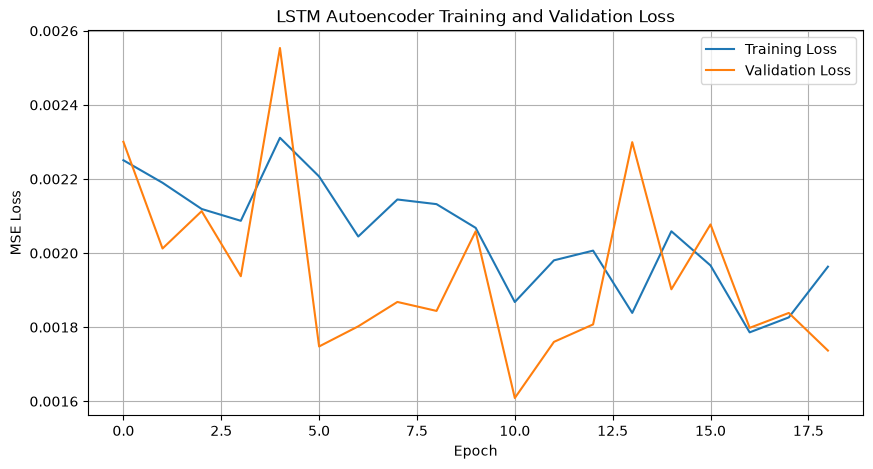

In [ ]:
# ============================================================
# LSTM AUTOENCODER — TRAINING CURVES
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Autoencoder Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# LSTM AUTOENCODER — RECONSTRUCTION ERROR
# ============================================================

# Reconstruct the training sequences
train_reconstructed = lstm_autoencoder.predict(
    X_train_lstm_scaled,
    verbose=0
)

# Reconstruct the validation sequences
validation_reconstructed = lstm_autoencoder.predict(
    X_validation_lstm_scaled,
    verbose=0
)

# Reconstruct the final test sequences
test_reconstructed = lstm_autoencoder.predict(
    X_test_lstm_scaled,
    verbose=0
)

# Calculate Mean Squared Reconstruction Error
train_reconstruction_error = np.mean(
    np.square(
        X_train_lstm_scaled - train_reconstructed
    ),
    axis=(1, 2)
)

validation_reconstruction_error = np.mean(
    np.square(
        X_validation_lstm_scaled - validation_reconstructed
    ),
    axis=(1, 2)
)

test_reconstruction_error = np.mean(
    np.square(
        X_test_lstm_scaled - test_reconstructed
    ),
    axis=(1, 2)
)

print("LSTM AUTOENCODER — RECONSTRUCTION ERROR")
print("=" * 60)

print("Training sequences:", len(train_reconstruction_error))
print("Validation sequences:", len(validation_reconstruction_error))
print("Test sequences:", len(test_reconstruction_error))

print("\nTraining reconstruction error:")
print("Minimum:", train_reconstruction_error.min())
print("Maximum:", train_reconstruction_error.max())
print("Mean:", train_reconstruction_error.mean())

print("\nValidation reconstruction error:")
print("Minimum:", validation_reconstruction_error.min())
print("Maximum:", validation_reconstruction_error.max())
print("Mean:", validation_reconstruction_error.mean())

print("\nTest reconstruction error:")
print("Minimum:", test_reconstruction_error.min())
print("Maximum:", test_reconstruction_error.max())
print("Mean:", test_reconstruction_error.mean())

LSTM AUTOENCODER — RECONSTRUCTION ERROR
Training sequences: 2395
Validation sequences: 807
Test sequences: 807

Training reconstruction error:
Minimum: 8.396022632107564e-05
Maximum: 0.03008959233078173
Mean: 0.001514521653929209

Validation reconstruction error:
Minimum: 0.00015520137561121614
Maximum: 0.025571492004514796
Mean: 0.0016088043470453988

Test reconstruction error:
Minimum: 0.00014454562646274381
Maximum: 0.06666351450183076
Mean: 0.003363917441862024


In [ ]:
# ============================================================
# LSTM AUTOENCODER — TRAINING THRESHOLD
# ============================================================

lstm_threshold = np.percentile(
    train_reconstruction_error,
    99
)

print("LSTM AUTOENCODER THRESHOLD")
print("=" * 60)

print("99th percentile threshold:", lstm_threshold)

print("\nSelected reconstruction-error percentiles:")

for p in [95, 97, 98, 99, 99.5, 99.9]:
    print(
        f"{p:5.1f}% : "
        f"{np.percentile(train_reconstruction_error, p):.6f}"
    )

LSTM AUTOENCODER THRESHOLD
99th percentile threshold: 0.020251801330746014

Selected reconstruction-error percentiles:
 95.0% : 0.011861
 97.0% : 0.014688
 98.0% : 0.017752
 99.0% : 0.020252
 99.5% : 0.023582
 99.9% : 0.027063


In [ ]:
# ============================================================
# LSTM AUTOENCODER — FINAL TEST DETECTION
# ============================================================

# Apply the frozen training threshold
lstm_test_anomaly = (
    test_reconstruction_error >= lstm_threshold
)

# Create results dataframe
lstm_test_results = pd.DataFrame({
    "timestamp": sequence_end_times[test_mask].values,
    "reconstruction_error": test_reconstruction_error,
    "predicted_anomaly": lstm_test_anomaly.astype(int)
})

print("LSTM AUTOENCODER — FINAL TEST")
print("=" * 60)

print("Test sequences:", len(lstm_test_results))

print("Threshold:", lstm_threshold)

print(
    "Detected anomalies:",
    lstm_test_anomaly.sum()
)

print(
    "Anomaly percentage:",
    round(
        lstm_test_anomaly.mean() * 100,
        2
    ),
    "%"
)

LSTM AUTOENCODER — FINAL TEST
Test sequences: 807
Threshold: 0.020251801330746014
Detected anomalies: 35
Anomaly percentage: 4.34 %


In [ ]:
# ============================================================
# LSTM AUTOENCODER — EXACT-POINT EVALUATION
# ============================================================

# Create exact-point ground truth
lstm_test_results["ground_truth"] = (
    lstm_test_results["timestamp"].isin(
        [
            pd.Timestamp("2014-02-26 22:05:00"),
            pd.Timestamp("2014-02-27 17:15:00")
        ]
    )
).astype(int)

y_true_lstm = lstm_test_results["ground_truth"]
y_pred_lstm = lstm_test_results["predicted_anomaly"]
y_score_lstm = lstm_test_results["reconstruction_error"]

# Calculate metrics
precision_lstm = precision_score(
    y_true_lstm,
    y_pred_lstm,
    zero_division=0
)

recall_lstm = recall_score(
    y_true_lstm,
    y_pred_lstm,
    zero_division=0
)

f1_lstm = f1_score(
    y_true_lstm,
    y_pred_lstm,
    zero_division=0
)

auc_lstm = roc_auc_score(
    y_true_lstm,
    y_score_lstm
)

cm_lstm = confusion_matrix(
    y_true_lstm,
    y_pred_lstm
)

print("LSTM AUTOENCODER — EXACT-POINT EVALUATION")
print("=" * 60)

print("Ground-truth anomalies:", y_true_lstm.sum())
print("Detected anomalies:", y_pred_lstm.sum())

print("\nPerformance Metrics")
print("-" * 60)

print(f"Precision : {precision_lstm:.4f}")
print(f"Recall    : {recall_lstm:.4f}")
print(f"F1 Score  : {f1_lstm:.4f}")
print(f"ROC-AUC   : {auc_lstm:.4f}")

print("\nConfusion Matrix")
print(cm_lstm)

LSTM AUTOENCODER — EXACT-POINT EVALUATION
Ground-truth anomalies: 2
Detected anomalies: 35

Performance Metrics
------------------------------------------------------------
Precision : 0.0286
Recall    : 0.5000
F1 Score  : 0.0541
ROC-AUC   : 0.9298

Confusion Matrix
[[771  34]
 [  1   1]]


In [ ]:
# ============================================================
# LSTM AUTOENCODER — WINDOW-BASED EVALUATION
# ============================================================

# Apply NAB anomaly windows
lstm_test_results["window_ground_truth"] = (
    lstm_test_results["timestamp"].apply(
        is_anomaly_window
    )
)

y_true_lstm_window = (
    lstm_test_results["window_ground_truth"]
)

y_pred_lstm_window = (
    lstm_test_results["predicted_anomaly"]
)

precision_lstm_window = precision_score(
    y_true_lstm_window,
    y_pred_lstm_window,
    zero_division=0
)

recall_lstm_window = recall_score(
    y_true_lstm_window,
    y_pred_lstm_window,
    zero_division=0
)

f1_lstm_window = f1_score(
    y_true_lstm_window,
    y_pred_lstm_window,
    zero_division=0
)

cm_lstm_window = confusion_matrix(
    y_true_lstm_window,
    y_pred_lstm_window
)

print("LSTM AUTOENCODER — WINDOW-BASED EVALUATION")
print("=" * 60)

print("Actual anomalous observations:",
      y_true_lstm_window.sum())

print("Actual normal observations:",
      (y_true_lstm_window == 0).sum())

print("Detected anomalies:",
      y_pred_lstm_window.sum())

print("\nPerformance Metrics")
print("-" * 60)

print(f"Precision : {precision_lstm_window:.4f}")
print(f"Recall    : {recall_lstm_window:.4f}")
print(f"F1 Score  : {f1_lstm_window:.4f}")

print("\nConfusion Matrix")
print(cm_lstm_window)

LSTM AUTOENCODER — WINDOW-BASED EVALUATION
Actual anomalous observations: 402
Actual normal observations: 405
Detected anomalies: 35

Performance Metrics
------------------------------------------------------------
Precision : 0.8286
Recall    : 0.0721
F1 Score  : 0.1327

Confusion Matrix
[[399   6]
 [373  29]]


In [ ]:
# ============================================================
# LSTM AUTOENCODER — EVENT-LEVEL EVALUATION
# ============================================================

lstm_event_results = evaluate_events(
    lstm_test_results
)

lstm_event_rate = (
    lstm_event_results["detected"].sum()
    / len(lstm_event_results)
)

print("LSTM AUTOENCODER — EVENT-LEVEL EVALUATION")
print("=" * 60)

print(lstm_event_results.to_string(index=False))

print(
    "\nEvent Detection Rate:",
    f"{lstm_event_rate:.2%}"
)

LSTM AUTOENCODER — EVENT-LEVEL EVALUATION
 event               start                 end  observations  detections  detected
     1 2014-02-26 13:45:00 2014-02-27 06:25:00           201          29      True
     2 2014-02-27 08:55:00 2014-02-28 01:35:00           201           0     False

Event Detection Rate: 50.00%


In [ ]:
# ============================================================
# CORRECTED MODEL PERFORMANCE SUMMARY
# ============================================================

model_comparison = pd.DataFrame({
    "Model": [
        "ARIMA Residual",
        "Isolation Forest V1",
        "Isolation Forest V2",
        "LSTM Autoencoder"
    ],

    # Exact-point evaluation
    "Point Precision": [
        0.0870,
        0.0526,
        0.0556,
        precision_lstm
    ],

    "Point Recall": [
        1.0000,
        0.5000,
        1.0000,
        recall_lstm
    ],

    "Point F1": [
        0.1600,
        0.0952,
        0.1053,
        f1_lstm
    ],

    "Point ROC-AUC": [
        0.9981,
        0.9845,
        0.9795,
        auc_lstm
    ],

    # Window-based evaluation
    "Window Precision": [
        precision_arima_window,
        precision_window_v1,
        precision_window_v2,
        precision_lstm_window
    ],

    "Window Recall": [
        recall_arima_window,
        recall_window_v1,
        recall_window_v2,
        recall_lstm_window
    ],

    "Window F1": [
        f1_arima_window,
        f1_window_v1,
        f1_window_v2,
        f1_lstm_window
    ],

    # Event-level evaluation
    "Event Detection Rate": [
        arima_event_rate,
        v1_event_rate,
        event_detection_rate_v2,
        lstm_event_rate
    ]
})

print("CORRECTED FINAL MODEL COMPARISON")
print("=" * 110)

display(model_comparison.round(4))

CORRECTED FINAL MODEL COMPARISON


,Model,Point Precision,Point Recall,Point F1,Point ROC-AUC,Window Precision,Window Recall,Window F1,Event Detection Rate
0,ARIMA Residual,0.0870,1.0,0.1600,0.9981,0.4783,0.0274,0.0518,1.0
1,Isolation Forest V1,0.0526,0.5,0.0952,0.9845,0.6842,0.0323,0.0618,1.0
2,Isolation Forest V2,0.0556,1.0,0.1053,0.9795,0.7222,0.0647,0.1187,1.0
3,LSTM Autoencoder,0.0286,0.5,0.0541,0.9298,0.8286,0.0721,0.1327,0.5


## 13. Hybrid Anomaly Detection

The individual models capture different characteristics of abnormal behavior. ARIMA focuses on forecasting deviations, Isolation Forest identifies unusual feature combinations, and the LSTM Autoencoder detects sequences that are difficult to reconstruct.

To investigate whether these complementary signals can improve anomaly detection, their anomaly scores are combined into hybrid scores.

Two hybrid strategies are investigated:

- **Hybrid V1:** threshold-normalized score combination.
- **Hybrid V2:** percentile-based score normalization followed by score combination.

The hybrid approaches are evaluated using the same final test set and fixed training-derived thresholds.

### 13.1 Hybrid V1 — Threshold-Normalized Score Combination

The first hybrid approach combines the anomaly scores produced by ARIMA, Isolation Forest V2, and the LSTM Autoencoder.

Each score is normalized using its corresponding training-derived anomaly threshold:

\[
s'_m = \min\left(\frac{s_m}{T_m}, 1\right)
\]

where \(s_m\) is the anomaly score from model \(m\) and \(T_m\) is its training-derived threshold.

The three normalized scores are then averaged to produce a single hybrid anomaly score.

An observation is classified as anomalous when the hybrid score exceeds a threshold determined from the training distribution.

In [ ]:
# Training-derived thresholds for the three anomaly signals

arima_threshold = 0.07615334829925355
iso_v2_threshold = 0.08179236078011909
lstm_threshold = 0.020251801330746014

# Normalize each test score to a common 0-1 scale.
# Scores at the training 99th-percentile threshold become 1.

hybrid_df = pd.DataFrame({
    "timestamp": test_results["timestamp"].values,
    "arima_score": test_results["absolute_error"].values,
    "iso_v2_score": iso_test_results_v2["anomaly_score"].values,
    "lstm_score": lstm_test_results["reconstruction_error"].values
})

hybrid_df["arima_norm"] = (
    hybrid_df["arima_score"] / arima_threshold
).clip(0, 1)

hybrid_df["iso_v2_norm"] = (
    hybrid_df["iso_v2_score"] / iso_v2_threshold
).clip(0, 1)

hybrid_df["lstm_norm"] = (
    hybrid_df["lstm_score"] / lstm_threshold
).clip(0, 1)

print(hybrid_df.head())

print("\nNormalized score ranges:")
print(
    hybrid_df[
        ["arima_norm", "iso_v2_norm", "lstm_norm"]
    ].describe()
)

            timestamp  arima_score  iso_v2_score  lstm_score  arima_norm  \
0 2014-02-25 19:15:00     0.011896     -0.057093    0.000200    0.156210   
1 2014-02-25 19:20:00     0.009366     -0.058937    0.000201    0.122992   
2 2014-02-25 19:25:00     0.007395     -0.057074    0.000204    0.097102   
3 2014-02-25 19:30:00     0.007393     -0.058743    0.000147    0.097082   
4 2014-02-25 19:35:00     0.058607      0.018580    0.000208    0.769589   

   iso_v2_norm  lstm_norm  
0     0.000000   0.009864  
1     0.000000   0.009931  
2     0.000000   0.010077  
3     0.000000   0.007262  
4     0.227162   0.010262  

Normalized score ranges:
       arima_norm  iso_v2_norm   lstm_norm
count  807.000000   807.000000  807.000000
mean     0.294534     0.197473    0.118229
std      0.309072     0.295923    0.260820
min      0.097082     0.000000    0.007137
25%      0.123346     0.000000    0.017519
50%      0.123346     0.000000    0.022413
75%      0.743327     0.311234    0.031267
max  

In [ ]:
# Verify that all three model outputs refer to exactly the same timestamps

arima_timestamps = pd.to_datetime(test_results["timestamp"]).reset_index(drop=True)
iso_timestamps = pd.to_datetime(iso_test_results_v2["timestamp"]).reset_index(drop=True)
lstm_timestamps = pd.to_datetime(lstm_test_results["timestamp"]).reset_index(drop=True)

print("ARIMA vs Isolation Forest V2:",
      arima_timestamps.equals(iso_timestamps))

print("ARIMA vs LSTM:",
      arima_timestamps.equals(lstm_timestamps))

print("Isolation Forest V2 vs LSTM:",
      iso_timestamps.equals(lstm_timestamps))

print("\nNumber of timestamps:", len(arima_timestamps))
print("First timestamp:", arima_timestamps.iloc[0])
print("Last timestamp:", arima_timestamps.iloc[-1])

ARIMA vs Isolation Forest V2: True
ARIMA vs LSTM: True
Isolation Forest V2 vs LSTM: True

Number of timestamps: 807
First timestamp: 2014-02-25 19:15:00
Last timestamp: 2014-02-28 14:25:00


In [ ]:
# Step 5: Combine the three normalized anomaly signals
# using equal weights.

hybrid_df["hybrid_score"] = (
    hybrid_df["arima_norm"]
    + hybrid_df["iso_v2_norm"]
    + hybrid_df["lstm_norm"]
) / 3

# Add the ground-truth labels from the test set
hybrid_df["ground_truth"] = test_results["ground_truth"].values
hybrid_df["window_ground_truth"] = test_results["ground_truth"].map(
    lambda x: 0
)

print(hybrid_df[
    [
        "timestamp",
        "arima_norm",
        "iso_v2_norm",
        "lstm_norm",
        "hybrid_score",
        "ground_truth"
    ]
].head(10))

print("\nHybrid score statistics:")
print(hybrid_df["hybrid_score"].describe())

            timestamp  arima_norm  iso_v2_norm  lstm_norm  hybrid_score  \
0 2014-02-25 19:15:00    0.156210     0.000000   0.009864      0.055358   
1 2014-02-25 19:20:00    0.122992     0.000000   0.009931      0.044308   
2 2014-02-25 19:25:00    0.097102     0.000000   0.010077      0.035726   
3 2014-02-25 19:30:00    0.097082     0.000000   0.007262      0.034781   
4 2014-02-25 19:35:00    0.769589     0.227162   0.010262      0.335671   
5 2014-02-25 19:40:00    0.123346     0.000000   0.010310      0.044552   
6 2014-02-25 19:45:00    0.123346     0.000000   0.010415      0.044587   
7 2014-02-25 19:50:00    0.123346     0.000000   0.010488      0.044611   
8 2014-02-25 19:55:00    0.963755     0.723976   0.015144      0.567625   
9 2014-02-25 20:00:00    0.123346     0.181248   0.015038      0.106544   

   ground_truth  
0             0  
1             0  
2             0  
3             0  
4             0  
5             0  
6             0  
7             0  
8           

In [ ]:
# Remove the temporary placeholder column

if "window_ground_truth" in hybrid_df.columns:
    hybrid_df = hybrid_df.drop(columns=["window_ground_truth"])

print("Hybrid dataframe shape:", hybrid_df.shape)
print("Columns:", list(hybrid_df.columns))

Hybrid dataframe shape: (807, 9)
Columns: ['timestamp', 'arima_score', 'iso_v2_score', 'lstm_score', 'arima_norm', 'iso_v2_norm', 'lstm_norm', 'hybrid_score', 'ground_truth']


In [ ]:
# Step 7: Normalize the aligned training scores
# and calculate the training hybrid anomaly score.

hybrid_train_df["arima_norm"] = (
    hybrid_train_df["arima_score"] / arima_threshold
).clip(0, 1)

hybrid_train_df["iso_v2_norm"] = (
    hybrid_train_df["iso_v2_score"] / iso_v2_threshold
).clip(0, 1)

hybrid_train_df["lstm_norm"] = (
    hybrid_train_df["lstm_score"] / lstm_threshold
).clip(0, 1)

# Equal-weight hybrid score
hybrid_train_df["hybrid_score"] = (
    hybrid_train_df["arima_norm"]
    + hybrid_train_df["iso_v2_norm"]
    + hybrid_train_df["lstm_norm"]
) / 3

print(hybrid_train_df[
    [
        "timestamp",
        "arima_norm",
        "iso_v2_norm",
        "lstm_norm",
        "hybrid_score"
    ]
].head())

print("\nTraining hybrid score statistics:")
print(hybrid_train_df["hybrid_score"].describe())

            timestamp  arima_norm  iso_v2_norm  lstm_norm  hybrid_score
0 2014-02-15 14:30:00    0.124632          0.0   0.018409      0.047680
1 2014-02-15 14:35:00    0.768303          0.0   0.018471      0.262258
2 2014-02-15 14:40:00    0.079094          0.0   0.021705      0.033600
3 2014-02-15 14:45:00    0.124632          0.0   0.021781      0.048804
4 2014-02-15 14:50:00    0.098370          0.0   0.018701      0.039024

Training hybrid score statistics:
count    2130.000000
mean        0.143678
std         0.161124
min         0.020055
25%         0.040394
50%         0.048670
75%         0.262107
max         0.946571
Name: hybrid_score, dtype: float64


In [ ]:
# Step 8: Calculate the hybrid anomaly threshold
# using only the training hybrid scores.

hybrid_threshold = hybrid_train_df["hybrid_score"].quantile(0.99)

print("Hybrid 99th-percentile threshold:", hybrid_threshold)

print("\nTraining hybrid score percentiles:")
print(
    hybrid_train_df["hybrid_score"].quantile(
        [0.90, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999]
    )
)

Hybrid 99th-percentile threshold: 0.6725436726332151

Training hybrid score percentiles:
0.900    0.365412
0.950    0.490935
0.970    0.561466
0.980    0.592536
0.990    0.672544
0.995    0.721914
0.999    0.905135
Name: hybrid_score, dtype: float64


In [ ]:
# Step 9: Apply the frozen training-derived threshold
# to the final test set.

hybrid_df["predicted_anomaly"] = (
    hybrid_df["hybrid_score"] >= hybrid_threshold
).astype(int)

print("Hybrid threshold:", hybrid_threshold)

print("\nTest observations:", len(hybrid_df))
print(
    "Predicted anomalies:",
    hybrid_df["predicted_anomaly"].sum()
)
print(
    "Predicted anomaly rate:",
    hybrid_df["predicted_anomaly"].mean() * 100,
    "%"
)

print("\nDetected observations:")
print(
    hybrid_df[
        hybrid_df["predicted_anomaly"] == 1
    ][
        [
            "timestamp",
            "arima_norm",
            "iso_v2_norm",
            "lstm_norm",
            "hybrid_score",
            "ground_truth"
        ]
    ]
)

Hybrid threshold: 0.6725436726332151

Test observations: 807
Predicted anomalies: 33
Predicted anomaly rate: 4.089219330855019 %

Detected observations:
              timestamp  arima_norm  iso_v2_norm  lstm_norm  hybrid_score  \
96  2014-02-26 03:15:00    1.000000     1.000000   0.969226      0.989742   
97  2014-02-26 03:20:00    0.769590     0.935123   1.000000      0.901571   
110 2014-02-26 04:25:00    0.990018     0.602490   0.725882      0.772797   
189 2014-02-26 11:00:00    1.000000     1.000000   0.023062      0.674354   
201 2014-02-26 12:00:00    0.990018     1.000000   0.030065      0.673361   
234 2014-02-26 14:45:00    1.000000     1.000000   0.023878      0.674626   
236 2014-02-26 14:55:00    0.990018     1.000000   0.031276      0.673765   
248 2014-02-26 15:55:00    0.990018     1.000000   0.035417      0.675145   
311 2014-02-26 21:10:00    1.000000     1.000000   0.043342      0.681114   
322 2014-02-26 22:05:00    1.000000     1.000000   1.000000      1.000000   


In [ ]:
# Step 10: Point-level evaluation of the hybrid model

y_true = hybrid_df["ground_truth"]
y_pred = hybrid_df["predicted_anomaly"]
y_score = hybrid_df["hybrid_score"]

hybrid_precision = precision_score(y_true, y_pred, zero_division=0)
hybrid_recall = recall_score(y_true, y_pred, zero_division=0)
hybrid_f1 = f1_score(y_true, y_pred, zero_division=0)
hybrid_auc = roc_auc_score(y_true, y_score)
hybrid_cm = confusion_matrix(y_true, y_pred)

print("Hybrid Point-Level Performance")
print("-" * 40)
print(f"Precision : {hybrid_precision:.4f}")
print(f"Recall    : {hybrid_recall:.4f}")
print(f"F1 Score  : {hybrid_f1:.4f}")
print(f"ROC-AUC   : {hybrid_auc:.4f}")

print("\nConfusion Matrix:")
print(hybrid_cm)

Hybrid Point-Level Performance
----------------------------------------
Precision : 0.0606
Recall    : 1.0000
F1 Score  : 0.1143
ROC-AUC   : 0.9904

Confusion Matrix:
[[774  31]
 [  0   2]]


In [ ]:
# Step 11: Window-level evaluation of the hybrid model

y_window_true = hybrid_df["timestamp"].apply(
    is_anomaly_window
).astype(int)

y_window_pred = hybrid_df["predicted_anomaly"]

hybrid_window_precision = precision_score(
    y_window_true,
    y_window_pred,
    zero_division=0
)

hybrid_window_recall = recall_score(
    y_window_true,
    y_window_pred,
    zero_division=0
)

hybrid_window_f1 = f1_score(
    y_window_true,
    y_window_pred,
    zero_division=0
)

hybrid_window_cm = confusion_matrix(
    y_window_true,
    y_window_pred
)

print("Hybrid Window-Level Performance")
print("-" * 40)
print(f"Precision : {hybrid_window_precision:.4f}")
print(f"Recall    : {hybrid_window_recall:.4f}")
print(f"F1 Score  : {hybrid_window_f1:.4f}")

print("\nConfusion Matrix:")
print(hybrid_window_cm)

print("\nWindow ground-truth counts:")
print(y_window_true.value_counts().sort_index())

Hybrid Window-Level Performance
----------------------------------------
Precision : 0.6667
Recall    : 0.0547
F1 Score  : 0.1011

Confusion Matrix:
[[394  11]
 [380  22]]

Window ground-truth counts:
timestamp
0    405
1    402
Name: count, dtype: int64


In [ ]:
# Step 12: Event-level evaluation of the hybrid model

hybrid_event_results = evaluate_events(
    hybrid_df[["timestamp", "predicted_anomaly"]]
)

print("Hybrid Event-Level Results")
print("-" * 40)
print(hybrid_event_results)

hybrid_event_rate = hybrid_event_results["detected"].mean()

print("\nEvent Detection Rate:", hybrid_event_rate)

Hybrid Event-Level Results
----------------------------------------
   event               start                 end  observations  detections  \
0      1 2014-02-26 13:45:00 2014-02-27 06:25:00           201          17   
1      2 2014-02-27 08:55:00 2014-02-28 01:35:00           201           5   

   detected  
0      True  
1      True  

Event Detection Rate: 1.0


In [ ]:
# Step 13: Analyze model agreement for hybrid detections

hybrid_df["arima_flag"] = (
    hybrid_df["arima_norm"] >= 1
).astype(int)

hybrid_df["iso_v2_flag"] = (
    hybrid_df["iso_v2_norm"] >= 1
).astype(int)

hybrid_df["lstm_flag"] = (
    hybrid_df["lstm_norm"] >= 1
).astype(int)

hybrid_df["model_agreement"] = (
    hybrid_df["arima_flag"]
    + hybrid_df["iso_v2_flag"]
    + hybrid_df["lstm_flag"]
)

agreement_counts = (
    hybrid_df[hybrid_df["predicted_anomaly"] == 1]
    ["model_agreement"]
    .value_counts()
    .sort_index()
)

print("Model agreement among hybrid detections:")
print(agreement_counts)

print("\nMeaning:")
print("1 = detected by one model")
print("2 = detected by two models")
print("3 = detected by all three models")

Model agreement among hybrid detections:
model_agreement
0     2
1    14
2    13
3     4
Name: count, dtype: int64

Meaning:
1 = detected by one model
2 = detected by two models
3 = detected by all three models


In [ ]:
# Step 14: Add Hybrid V1 to the model comparison table

hybrid_comparison_row = pd.DataFrame([{
    "Model": "Hybrid V1",
    "Point Precision": hybrid_precision,
    "Point Recall": hybrid_recall,
    "Point F1": hybrid_f1,
    "Point ROC-AUC": hybrid_auc,
    "Window Precision": hybrid_window_precision,
    "Window Recall": hybrid_window_recall,
    "Window F1": hybrid_window_f1,
    "Event Detection Rate": hybrid_event_rate
}])

model_comparison_v2 = pd.concat(
    [model_comparison, hybrid_comparison_row],
    ignore_index=True
)

print(model_comparison_v2)

                 Model  Point Precision  Point Recall  Point F1  \
0       ARIMA Residual         0.087000           1.0  0.160000   
1  Isolation Forest V1         0.052600           0.5  0.095200   
2  Isolation Forest V2         0.055600           1.0  0.105300   
3     LSTM Autoencoder         0.028571           0.5  0.054054   
4            Hybrid V1         0.060606           1.0  0.114286   

   Point ROC-AUC  Window Precision  Window Recall  Window F1  \
0       0.998100          0.478261       0.027363   0.051765   
1       0.984500          0.684211       0.032338   0.061758   
2       0.979500          0.722222       0.064677   0.118721   
3       0.929814          0.828571       0.072139   0.132723   
4       0.990373          0.666667       0.054726   0.101149   

   Event Detection Rate  
0                   1.0  
1                   1.0  
2                   1.0  
3                   0.5  
4                   1.0  


### 13.2 Hybrid V2 — Percentile-Based Score Combination

Hybrid V2 improves the score-combination strategy by using empirical percentile normalization instead of directly dividing by fixed anomaly thresholds.

For each model, a test anomaly score is converted into its percentile relative to the corresponding training-score distribution.

The three percentile scores are then averaged:

\[
S_{hybrid} =
\frac{P_{ARIMA} + P_{IF} + P_{LSTM}}{3}
\]

This approach preserves information about the relative extremeness of an observation and places the anomaly scores from the three models on a comparable scale.

The final Hybrid V2 threshold is determined from the training hybrid-score distribution and is kept fixed during final test evaluation.

In [ ]:
# Step 16: Create percentile-based normalization functions
# using training data only.

from scipy.stats import percentileofscore

def percentile_normalize(train_scores, test_scores):
    """
    Convert scores into their percentile rank relative to training data.
    Higher percentile = more anomalous.
    """
    train_scores = np.asarray(train_scores)

    return np.array([
        percentileofscore(train_scores, score, kind="rank") / 100
        for score in test_scores
    ])

# Normalize the three test scores relative to their training distributions

hybrid_df["arima_percentile"] = percentile_normalize(
    hybrid_train_df["arima_score"],
    hybrid_df["arima_score"]
)

hybrid_df["iso_v2_percentile"] = percentile_normalize(
    hybrid_train_df["iso_v2_score"],
    hybrid_df["iso_v2_score"]
)

hybrid_df["lstm_percentile"] = percentile_normalize(
    hybrid_train_df["lstm_score"],
    hybrid_df["lstm_score"]
)

print(hybrid_df[
    [
        "timestamp",
        "arima_score",
        "arima_percentile",
        "iso_v2_score",
        "iso_v2_percentile",
        "lstm_score",
        "lstm_percentile"
    ]
].head(10))

            timestamp  arima_score  arima_percentile  iso_v2_score  \
0 2014-02-25 19:15:00     0.011896          0.722535     -0.057093   
1 2014-02-25 19:20:00     0.009366          0.359624     -0.058937   
2 2014-02-25 19:25:00     0.007395          0.247887     -0.057074   
3 2014-02-25 19:30:00     0.007393          0.247887     -0.058743   
4 2014-02-25 19:35:00     0.058607          0.918310      0.018580   
5 2014-02-25 19:40:00     0.009393          0.464789     -0.032937   
6 2014-02-25 19:45:00     0.009393          0.464789     -0.033357   
7 2014-02-25 19:50:00     0.009393          0.464789     -0.059702   
8 2014-02-25 19:55:00     0.073393          0.974178      0.059216   
9 2014-02-25 20:00:00     0.009393          0.464789      0.014825   

   iso_v2_percentile  lstm_score  lstm_percentile  
0           0.178873    0.000200         0.004695  
1           0.161033    0.000201         0.004695  
2           0.178873    0.000204         0.005164  
3           0.163380 

In [ ]:
# Step 17: Calculate the Hybrid V2 anomaly score
# using equal weights on percentile-normalized scores.

hybrid_df["hybrid_v2_score"] = (
    hybrid_df["arima_percentile"]
    + hybrid_df["iso_v2_percentile"]
    + hybrid_df["lstm_percentile"]
) / 3

print(
    hybrid_df[
        [
            "timestamp",
            "arima_percentile",
            "iso_v2_percentile",
            "lstm_percentile",
            "hybrid_v2_score"
        ]
    ].head(10)
)

print("\nHybrid V2 score statistics:")
print(hybrid_df["hybrid_v2_score"].describe())

            timestamp  arima_percentile  iso_v2_percentile  lstm_percentile  \
0 2014-02-25 19:15:00          0.722535           0.178873         0.004695   
1 2014-02-25 19:20:00          0.359624           0.161033         0.004695   
2 2014-02-25 19:25:00          0.247887           0.178873         0.005164   
3 2014-02-25 19:30:00          0.247887           0.163380         0.003286   
4 2014-02-25 19:35:00          0.918310           0.886385         0.007042   
5 2014-02-25 19:40:00          0.464789           0.418779         0.007981   
6 2014-02-25 19:45:00          0.464789           0.413615         0.010798   
7 2014-02-25 19:50:00          0.464789           0.152582         0.012207   
8 2014-02-25 19:55:00          0.974178           0.976526         0.077465   
9 2014-02-25 20:00:00          0.464789           0.871831         0.071362   

   hybrid_v2_score  
0         0.302034  
1         0.175117  
2         0.143975  
3         0.138185  
4         0.603912  
5   

In [ ]:
# Step 18: Calculate percentile-normalized scores for the
# aligned training data.

hybrid_train_df["arima_percentile"] = [
    percentileofscore(
        hybrid_train_df["arima_score"].values,
        score,
        kind="rank"
    ) / 100
    for score in hybrid_train_df["arima_score"]
]

hybrid_train_df["iso_v2_percentile"] = [
    percentileofscore(
        hybrid_train_df["iso_v2_score"].values,
        score,
        kind="rank"
    ) / 100
    for score in hybrid_train_df["iso_v2_score"]
]

hybrid_train_df["lstm_percentile"] = [
    percentileofscore(
        hybrid_train_df["lstm_score"].values,
        score,
        kind="rank"
    ) / 100
    for score in hybrid_train_df["lstm_score"]
]

# Equal-weight Hybrid V2 training score
hybrid_train_df["hybrid_v2_score"] = (
    hybrid_train_df["arima_percentile"]
    + hybrid_train_df["iso_v2_percentile"]
    + hybrid_train_df["lstm_percentile"]
) / 3

print(
    hybrid_train_df[
        [
            "timestamp",
            "arima_percentile",
            "iso_v2_percentile",
            "lstm_percentile",
            "hybrid_v2_score"
        ]
    ].head()
)

print("\nTraining Hybrid V2 statistics:")
print(hybrid_train_df["hybrid_v2_score"].describe())

            timestamp  arima_percentile  iso_v2_percentile  lstm_percentile  \
0 2014-02-15 14:30:00          0.573944           0.167136         0.357277   
1 2014-02-15 14:35:00          0.863615           0.631925         0.365728   
2 2014-02-15 14:40:00          0.120188           0.398122         0.607981   
3 2014-02-15 14:45:00          0.573944           0.129577         0.609859   
4 2014-02-15 14:50:00          0.295305           0.187324         0.380751   

   hybrid_v2_score  
0         0.366119  
1         0.620423  
2         0.375430  
3         0.437793  
4         0.287793  

Training Hybrid V2 statistics:
count    2130.000000
mean        0.500235
std         0.180375
min         0.088811
25%         0.366236
50%         0.483568
75%         0.620286
max         0.990923
Name: hybrid_v2_score, dtype: float64


In [ ]:
# Step 19: Calculate the Hybrid V2 threshold
# using only the training Hybrid V2 scores.

hybrid_v2_threshold = hybrid_train_df["hybrid_v2_score"].quantile(0.99)

print("Hybrid V2 99th-percentile threshold:",
      hybrid_v2_threshold)

print("\nTraining Hybrid V2 percentiles:")
print(
    hybrid_train_df["hybrid_v2_score"].quantile(
        [0.90, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999]
    )
)

Hybrid V2 99th-percentile threshold: 0.9321572769953052

Training Hybrid V2 percentiles:
0.900    0.756103
0.950    0.834624
0.970    0.865741
0.980    0.889706
0.990    0.932157
0.995    0.952380
0.999    0.979837
Name: hybrid_v2_score, dtype: float64


In [ ]:
# Apply the training-derived Hybrid V2 threshold to the final test set

hybrid_df["hybrid_v2_predicted_anomaly"] = (
    hybrid_df["hybrid_v2_score"] >= hybrid_v2_threshold
).astype(int)

print("Hybrid V2 test observations:", len(hybrid_df))
print("Hybrid V2 predicted anomalies:", hybrid_df["hybrid_v2_predicted_anomaly"].sum())
print(
    "Hybrid V2 anomaly rate:",
    round(hybrid_df["hybrid_v2_predicted_anomaly"].mean() * 100, 2),
    "%"
)

Hybrid V2 test observations: 807
Hybrid V2 predicted anomalies: 40
Hybrid V2 anomaly rate: 4.96 %


In [ ]:
# Point-level evaluation for Hybrid V2

y_true_hybrid_v2 = hybrid_df["ground_truth"]
y_pred_hybrid_v2 = hybrid_df["hybrid_v2_predicted_anomaly"]
y_score_hybrid_v2 = hybrid_df["hybrid_v2_score"]

hybrid_v2_precision = precision_score(y_true_hybrid_v2, y_pred_hybrid_v2)
hybrid_v2_recall = recall_score(y_true_hybrid_v2, y_pred_hybrid_v2)
hybrid_v2_f1 = f1_score(y_true_hybrid_v2, y_pred_hybrid_v2)
hybrid_v2_auc = roc_auc_score(y_true_hybrid_v2, y_score_hybrid_v2)
hybrid_v2_cm = confusion_matrix(y_true_hybrid_v2, y_pred_hybrid_v2)

print("Hybrid V2 Point-Level Results")
print("--------------------------------")
print("Precision:", round(hybrid_v2_precision, 4))
print("Recall:", round(hybrid_v2_recall, 4))
print("F1 Score:", round(hybrid_v2_f1, 4))
print("ROC-AUC:", round(hybrid_v2_auc, 4))

print("\nConfusion Matrix:")
print(hybrid_v2_cm)

Hybrid V2 Point-Level Results
--------------------------------
Precision: 0.05
Recall: 1.0
F1 Score: 0.0952
ROC-AUC: 0.995

Confusion Matrix:
[[767  38]
 [  0   2]]


In [ ]:
# Window-level evaluation for Hybrid V2

hybrid_v2_window_pred = hybrid_df["hybrid_v2_predicted_anomaly"].values
hybrid_v2_window_true = hybrid_df["timestamp"].apply(is_anomaly_window).values

hybrid_v2_window_precision = precision_score(
    hybrid_v2_window_true,
    hybrid_v2_window_pred
)

hybrid_v2_window_recall = recall_score(
    hybrid_v2_window_true,
    hybrid_v2_window_pred
)

hybrid_v2_window_f1 = f1_score(
    hybrid_v2_window_true,
    hybrid_v2_window_pred
)

hybrid_v2_window_cm = confusion_matrix(
    hybrid_v2_window_true,
    hybrid_v2_window_pred
)

print("Hybrid V2 Window-Level Results")
print("--------------------------------")
print("Precision:", round(hybrid_v2_window_precision, 4))
print("Recall:", round(hybrid_v2_window_recall, 4))
print("F1 Score:", round(hybrid_v2_window_f1, 4))

print("\nConfusion Matrix:")
print(hybrid_v2_window_cm)

print("\nWindow Ground Truth Counts:")
print("Normal:", (hybrid_v2_window_true == 0).sum())
print("Anomalous:", (hybrid_v2_window_true == 1).sum())

Hybrid V2 Window-Level Results
--------------------------------
Precision: 0.625
Recall: 0.0622
F1 Score: 0.1131

Confusion Matrix:
[[390  15]
 [377  25]]

Window Ground Truth Counts:
Normal: 405
Anomalous: 402


In [ ]:
# Event-level evaluation for Hybrid V2

hybrid_v2_event_results = []

for start_time, end_time in dataset_windows:
    start_time = pd.to_datetime(start_time)
    end_time = pd.to_datetime(end_time)

    event_mask = (
        (hybrid_df["timestamp"] >= start_time) &
        (hybrid_df["timestamp"] <= end_time)
    )

    event_predictions = hybrid_df.loc[
        event_mask,
        "hybrid_v2_predicted_anomaly"
    ]

    detected = event_predictions.sum() > 0

    hybrid_v2_event_results.append({
        "window_start": start_time,
        "window_end": end_time,
        "window_observations": event_mask.sum(),
        "detections": int(event_predictions.sum()),
        "event_detected": detected
    })

hybrid_v2_event_results_df = pd.DataFrame(hybrid_v2_event_results)

print(hybrid_v2_event_results_df)

hybrid_v2_event_detection_rate = (
    hybrid_v2_event_results_df["event_detected"].mean()
)

print(
    "\nHybrid V2 Event Detection Rate:",
    round(hybrid_v2_event_detection_rate, 4)
)

         window_start          window_end  window_observations  detections  \
0 2014-02-26 13:45:00 2014-02-27 06:25:00                  201          16   
1 2014-02-27 08:55:00 2014-02-28 01:35:00                  201           9   

   event_detected  
0            True  
1            True  

Hybrid V2 Event Detection Rate: 1.0


In [ ]:
# Add Hybrid V2 to the overall model comparison

hybrid_v2_comparison_row = pd.DataFrame([{
    "Model": "Hybrid V2",
    "Point Precision": hybrid_v2_precision,
    "Point Recall": hybrid_v2_recall,
    "Point F1": hybrid_v2_f1,
    "Point ROC-AUC": hybrid_v2_auc,
    "Window Precision": hybrid_v2_window_precision,
    "Window Recall": hybrid_v2_window_recall,
    "Window F1": hybrid_v2_window_f1,
    "Event Detection Rate": hybrid_v2_event_detection_rate
}])

model_comparison_final = pd.concat(
    [model_comparison_v2, hybrid_v2_comparison_row],
    ignore_index=True
)

model_comparison_final.round(4)

,Model,Point Precision,Point Recall,Point F1,Point ROC-AUC,Window Precision,Window Recall,Window F1,Event Detection Rate
0,ARIMA Residual,0.0870,1.0,0.1600,0.9981,0.4783,0.0274,0.0518,1.0
1,Isolation Forest V1,0.0526,0.5,0.0952,0.9845,0.6842,0.0323,0.0618,1.0
2,Isolation Forest V2,0.0556,1.0,0.1053,0.9795,0.7222,0.0647,0.1187,1.0
3,LSTM Autoencoder,0.0286,0.5,0.0541,0.9298,0.8286,0.0721,0.1327,0.5
4,Hybrid V1,0.0606,1.0,0.1143,0.9904,0.6667,0.0547,0.1011,1.0
5,Hybrid V2,0.0500,1.0,0.0952,0.9950,0.6250,0.0622,0.1131,1.0


## 14. Model Agreement Analysis

The predictions of ARIMA, Isolation Forest V2, and the LSTM Autoencoder are compared to study how consistently the different approaches identify anomalous observations.

For each timestamp, the number of models predicting an anomaly is calculated as the model-agreement count:

- **0:** no model detects an anomaly
- **1:** one model detects an anomaly
- **2:** two models agree
- **3:** all three models agree

The analysis helps determine whether the models provide complementary anomaly signals and whether stronger model agreement is associated with the official anomaly windows.

Single-model detections are also examined separately to identify which methods contribute unique anomaly signals.

In [ ]:
# Compare anomaly decisions from the three main models

agreement_df = pd.DataFrame({
    "timestamp": hybrid_df["timestamp"],
    "ARIMA": (
        hybrid_df["arima_score"] >= arima_threshold
    ).astype(int),
    "Isolation Forest V2": (
        hybrid_df["iso_v2_score"] >= iso_v2_threshold
    ).astype(int),
    "LSTM Autoencoder": (
        hybrid_df["lstm_score"] >= lstm_threshold
    ).astype(int),
    "ground_truth": hybrid_df["ground_truth"]
})

agreement_df["model_agreement"] = (
    agreement_df["ARIMA"]
    + agreement_df["Isolation Forest V2"]
    + agreement_df["LSTM Autoencoder"]
)

print("Model Agreement Counts")
print("----------------------")
print(
    agreement_df["model_agreement"]
    .value_counts()
    .sort_index()
)

print("\nAgreement percentages")
print(
    (agreement_df["model_agreement"].value_counts(normalize=True)
     .sort_index() * 100).round(2)
)

Model Agreement Counts
----------------------
model_agreement
0    734
1     56
2     13
3      4
Name: count, dtype: int64

Agreement percentages
model_agreement
0    90.95
1     6.94
2     1.61
3     0.50
Name: proportion, dtype: float64


In [ ]:
# Count which model is responsible for single-model detections

single_arima = (
    (agreement_df["ARIMA"] == 1) &
    (agreement_df["Isolation Forest V2"] == 0) &
    (agreement_df["LSTM Autoencoder"] == 0)
).sum()

single_iso = (
    (agreement_df["ARIMA"] == 0) &
    (agreement_df["Isolation Forest V2"] == 1) &
    (agreement_df["LSTM Autoencoder"] == 0)
).sum()

single_lstm = (
    (agreement_df["ARIMA"] == 0) &
    (agreement_df["Isolation Forest V2"] == 0) &
    (agreement_df["LSTM Autoencoder"] == 1)
).sum()

print("Single-model detections")
print("-----------------------")
print("ARIMA only:", single_arima)
print("Isolation Forest V2 only:", single_iso)
print("LSTM Autoencoder only:", single_lstm)

print("\nTotal single-model detections:",
      single_arima + single_iso + single_lstm)

Single-model detections
-----------------------
ARIMA only: 9
Isolation Forest V2 only: 19
LSTM Autoencoder only: 28

Total single-model detections: 56


In [ ]:
# Check whether unique single-model detections fall
# inside or outside the official anomaly windows

agreement_df["window_ground_truth"] = agreement_df["timestamp"].apply(
    is_anomaly_window
)

single_mask = agreement_df["model_agreement"] == 1

single_detection_df = agreement_df[single_mask].copy()

print("Single-model detections inside/outside anomaly windows")
print("------------------------------------------------------")

for model in ["ARIMA", "Isolation Forest V2", "LSTM Autoencoder"]:
    model_mask = (
        (single_detection_df[model] == 1)
    )

    inside = (
        single_detection_df.loc[model_mask, "window_ground_truth"] == 1
    ).sum()

    outside = (
        single_detection_df.loc[model_mask, "window_ground_truth"] == 0
    ).sum()

    print(f"\n{model} only:")
    print("  Inside anomaly window:", inside)
    print("  Outside anomaly window:", outside)

Single-model detections inside/outside anomaly windows
------------------------------------------------------

ARIMA only:
  Inside anomaly window: 2
  Outside anomaly window: 7

Isolation Forest V2 only:
  Inside anomaly window: 14
  Outside anomaly window: 5

LSTM Autoencoder only:
  Inside anomaly window: 23
  Outside anomaly window: 5


In [ ]:
# Analyze whether stronger model agreement corresponds
# to anomaly-window observations

agreement_summary = (
    agreement_df
    .groupby("model_agreement")["window_ground_truth"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

agreement_summary["inside_window_percentage"] = (
    agreement_summary["mean"] * 100
)

agreement_summary = agreement_summary.rename(columns={
    "count": "observations",
    "sum": "inside_window",
    "mean": "inside_window_rate"
})

print("Agreement Strength Analysis")
print("---------------------------")
print(
    agreement_summary[
        ["model_agreement",
         "observations",
         "inside_window",
         "inside_window_percentage"]
    ].round(2)
)

Agreement Strength Analysis
---------------------------
   model_agreement  observations  inside_window  inside_window_percentage
0                0           734            351                     47.82
1                1            56             39                     69.64
2                2            13              9                     69.23
3                3             4              3                     75.00


In [ ]:
# Add the actual CPU utilization values to hybrid_df
# using positional alignment

hybrid_df["value"] = test_results["value"].to_numpy()

print(hybrid_df[["timestamp", "value", "hybrid_v2_predicted_anomaly"]].head())
print("\nNumber of rows:", len(hybrid_df))

            timestamp  value  hybrid_v2_predicted_anomaly
0 2014-02-25 19:15:00  0.136                            0
1 2014-02-25 19:20:00  0.134                            0
2 2014-02-25 19:25:00  0.132                            0
3 2014-02-25 19:30:00  0.132                            0
4 2014-02-25 19:35:00  0.066                            0

Number of rows: 807


## 15. Visualization and Anomaly Analysis

Visualizations are used to examine the behavior of the anomaly-detection methods and to compare model predictions with the known anomaly events.

The final visual analysis includes:

- Hybrid V2 detections over the complete final test period
- A detailed view of the first official anomaly event
- A detailed view of the second official anomaly event
- Comparison of window-level F1 scores across all models

These visualizations provide qualitative evidence alongside the numerical evaluation metrics and help illustrate how the models respond to large and subtle deviations in the time series.

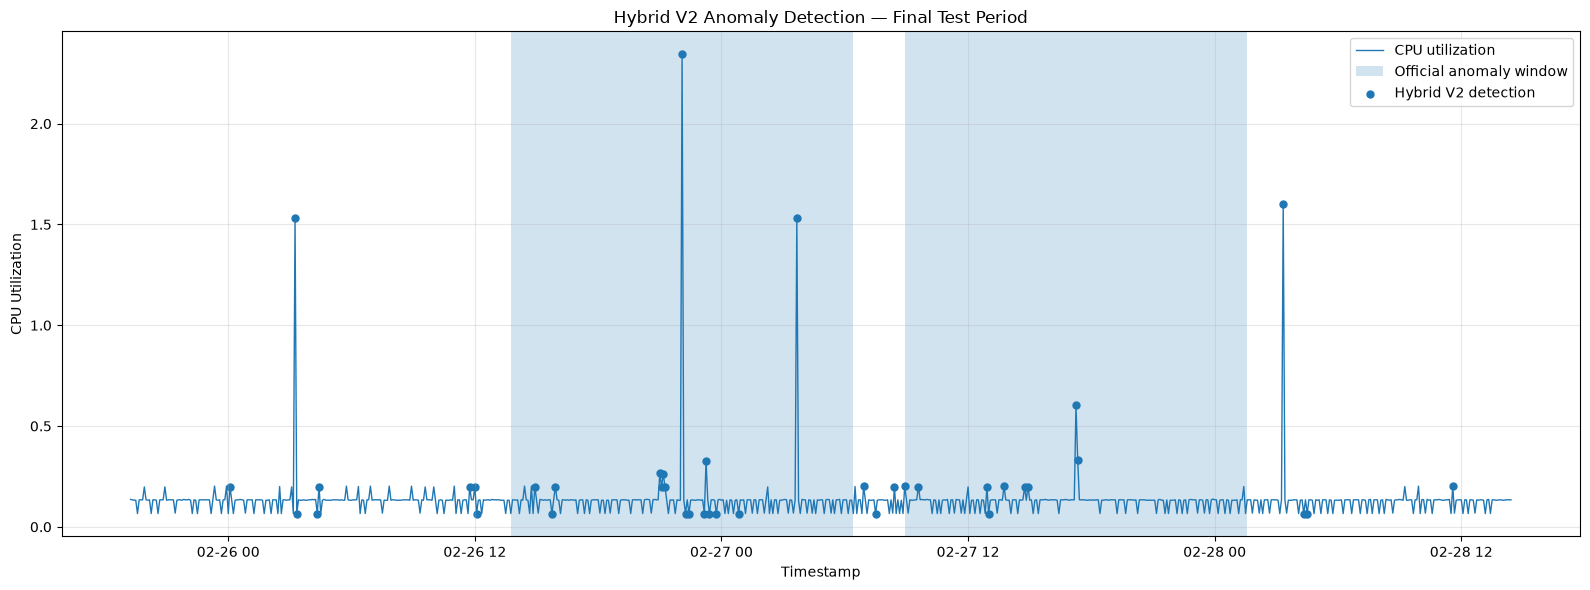

In [ ]:
# Full test-period visualization

plt.figure(figsize=(16, 6))

# Actual CPU utilization
plt.plot(
    hybrid_df["timestamp"],
    hybrid_df["value"],
    label="CPU utilization",
    linewidth=1
)

# Official anomaly windows
for i, (start_time, end_time) in enumerate(dataset_windows):
    start_time = pd.to_datetime(start_time)
    end_time = pd.to_datetime(end_time)

    plt.axvspan(
        start_time,
        end_time,
        alpha=0.2,
        label="Official anomaly window" if i == 0 else None
    )

# Hybrid V2 detections
hybrid_v2_points = hybrid_df[
    hybrid_df["hybrid_v2_predicted_anomaly"] == 1
]

plt.scatter(
    hybrid_v2_points["timestamp"],
    hybrid_v2_points["value"],
    label="Hybrid V2 detection",
    s=25
)

plt.title("Hybrid V2 Anomaly Detection — Final Test Period")
plt.xlabel("Timestamp")
plt.ylabel("CPU Utilization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


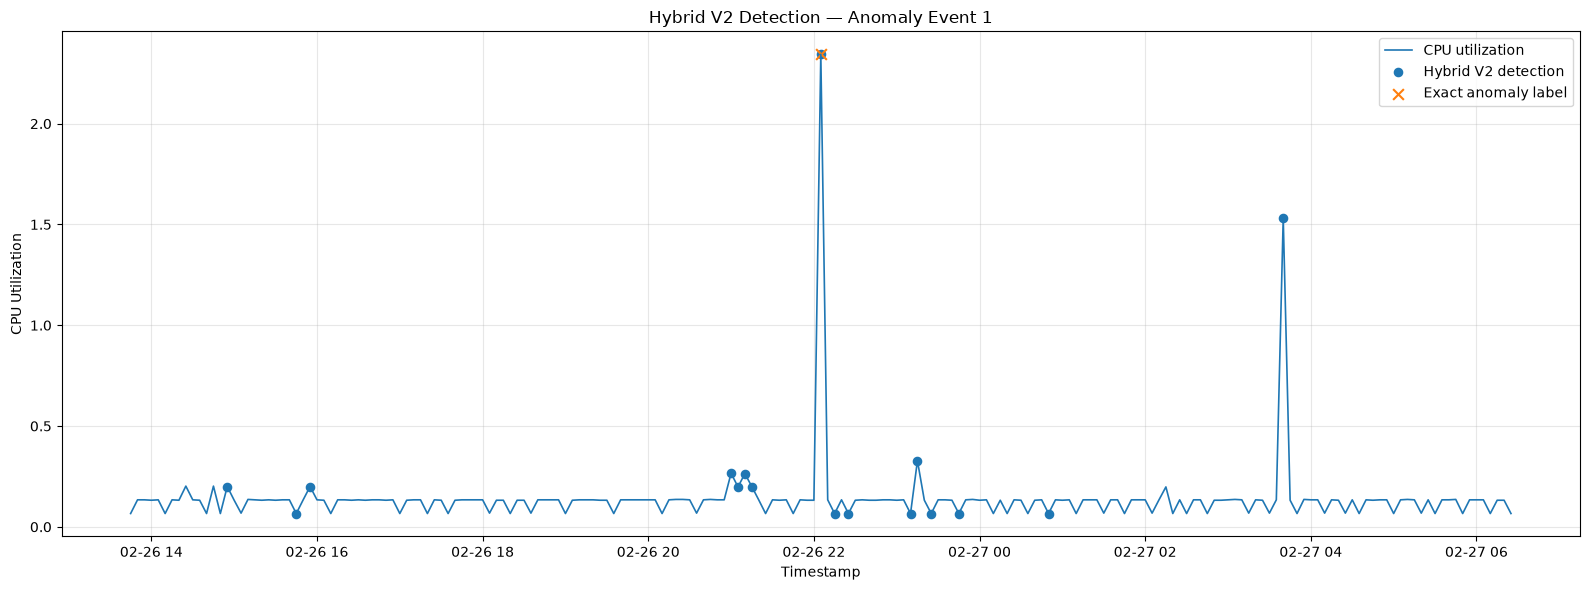

In [ ]:
# Zoomed visualization of the first anomaly event

event1_start = pd.to_datetime(dataset_windows[0][0])
event1_end = pd.to_datetime(dataset_windows[0][1])

event1_df = hybrid_df[
    (hybrid_df["timestamp"] >= event1_start) &
    (hybrid_df["timestamp"] <= event1_end)
].copy()

plt.figure(figsize=(16, 6))

# Actual CPU utilization
plt.plot(
    event1_df["timestamp"],
    event1_df["value"],
    label="CPU utilization",
    linewidth=1.2
)

# Hybrid V2 detections
event1_detections = event1_df[
    event1_df["hybrid_v2_predicted_anomaly"] == 1
]

plt.scatter(
    event1_detections["timestamp"],
    event1_detections["value"],
    label="Hybrid V2 detection",
    s=35
)

# Exact NAB anomaly label
exact_event1 = event1_df[
    event1_df["ground_truth"] == 1
]

plt.scatter(
    exact_event1["timestamp"],
    exact_event1["value"],
    label="Exact anomaly label",
    s=60,
    marker="x"
)

plt.title("Hybrid V2 Detection — Anomaly Event 1")
plt.xlabel("Timestamp")
plt.ylabel("CPU Utilization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

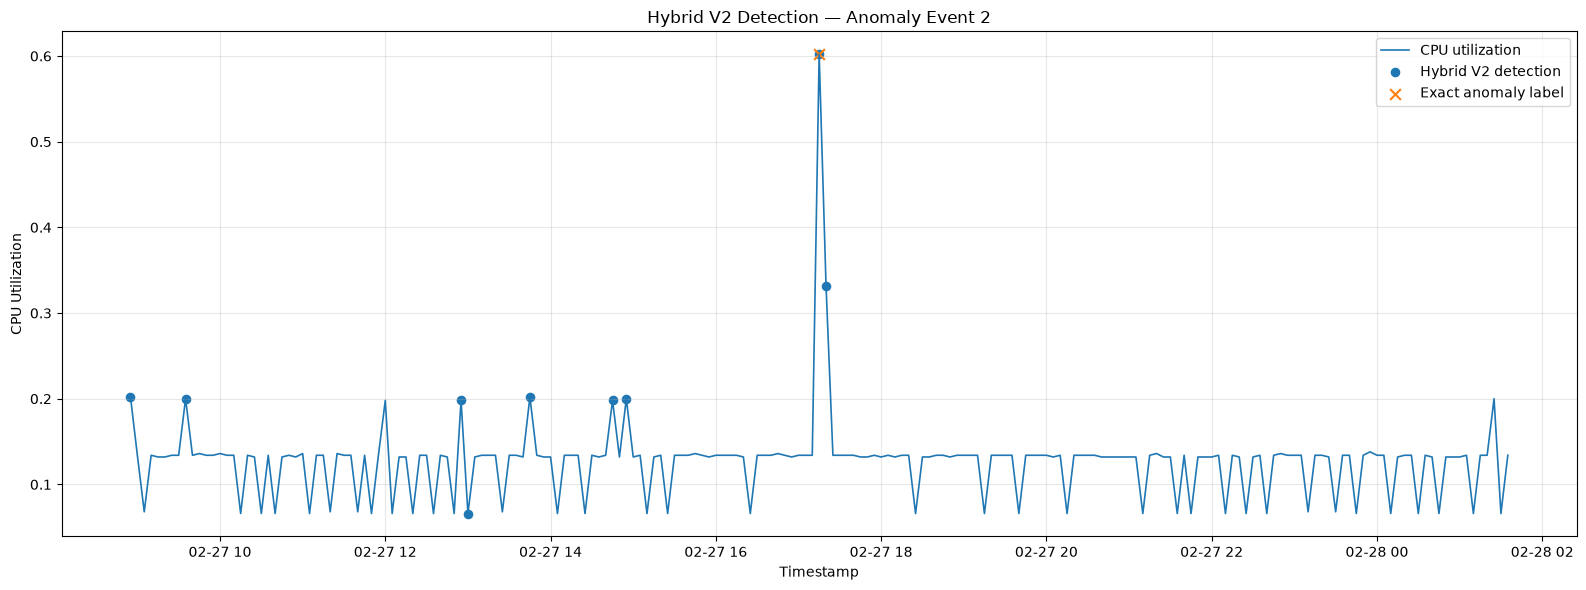

In [ ]:
# Zoomed visualization of the second anomaly event

event2_start = pd.to_datetime(dataset_windows[1][0])
event2_end = pd.to_datetime(dataset_windows[1][1])

event2_df = hybrid_df[
    (hybrid_df["timestamp"] >= event2_start) &
    (hybrid_df["timestamp"] <= event2_end)
].copy()

plt.figure(figsize=(16, 6))

# Actual CPU utilization
plt.plot(
    event2_df["timestamp"],
    event2_df["value"],
    label="CPU utilization",
    linewidth=1.2
)

# Hybrid V2 detections
event2_detections = event2_df[
    event2_df["hybrid_v2_predicted_anomaly"] == 1
]

plt.scatter(
    event2_detections["timestamp"],
    event2_detections["value"],
    label="Hybrid V2 detection",
    s=35
)

# Exact NAB anomaly label
exact_event2 = event2_df[
    event2_df["ground_truth"] == 1
]

plt.scatter(
    exact_event2["timestamp"],
    exact_event2["value"],
    label="Exact anomaly label",
    s=60,
    marker="x"
)

plt.title("Hybrid V2 Detection — Anomaly Event 2")
plt.xlabel("Timestamp")
plt.ylabel("CPU Utilization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

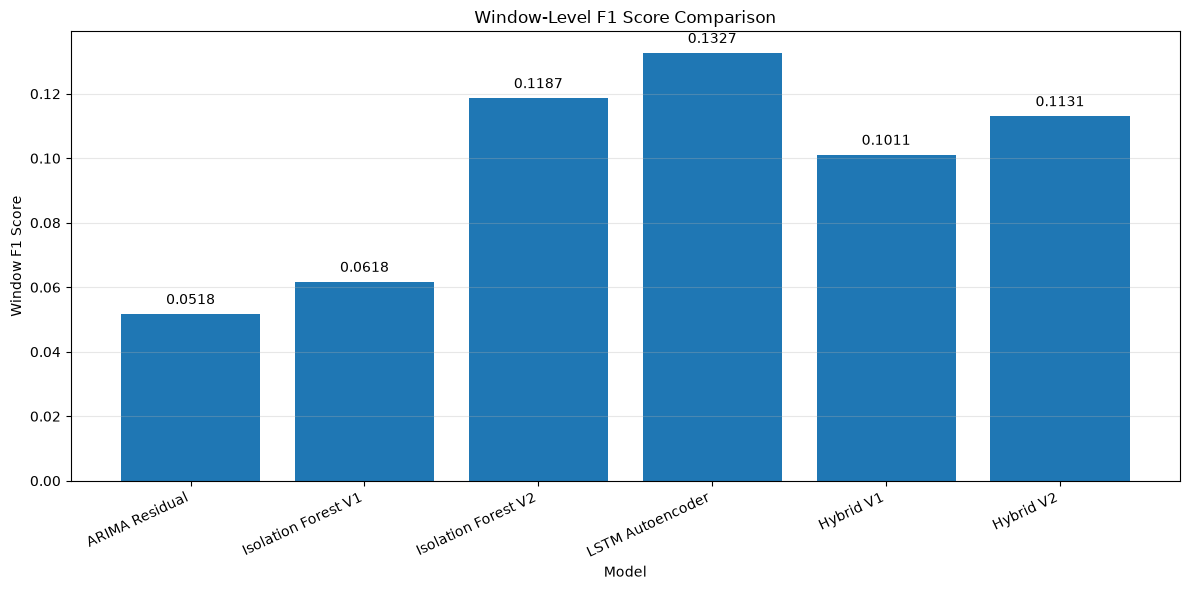

In [ ]:
# Window-level F1 comparison with values displayed above each bar

plt.figure(figsize=(12, 6))

bars = plt.bar(
    model_comparison_final["Model"],
    model_comparison_final["Window F1"]
)

plt.title("Window-Level F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("Window F1 Score")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)

# Add F1 values above each bar
for bar, value in zip(
    bars,
    model_comparison_final["Window F1"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 16. Final Results and Discussion

Six approaches were evaluated for anomaly detection on the final unseen test period: ARIMA Residual, Isolation Forest V1, Isolation Forest V2, LSTM Autoencoder, Hybrid V1, and Hybrid V2.

### Key Findings

- **ARIMA Residual** achieved the strongest point-level performance, with an F1 score of 0.1600 and ROC-AUC of 0.9981. This indicates that forecasting errors were highly effective at ranking the exact labeled anomaly points.
- **LSTM Autoencoder** achieved the highest window-level F1 score of 0.1327. Its unique detections also showed strong alignment with the official anomaly windows.
- **Isolation Forest V2** improved over V1 in window-level F1, achieving 0.1187 while detecting both anomaly events.
- **Hybrid V1** and **Hybrid V2** successfully detected both official anomaly events, demonstrating that combining signals from forecasting, feature-based, and deep-learning approaches can provide complementary information.
- Hybrid V2 achieved a strong point-level ROC-AUC of 0.9950 and a 100% event detection rate, but its window-level F1 of 0.1131 did not exceed the best individual models.
- Model agreement analysis showed substantial disagreement among the three main approaches, supporting the observation that the models capture different characteristics of abnormal behavior.

### Overall Interpretation

The experiments demonstrate that there is no universally best anomaly-detection method for this time-series dataset. Statistical forecasting, machine learning, and deep learning approaches respond differently to abnormal patterns.

The results therefore support a **comparative and hybrid anomaly-detection framework** rather than relying on a single model. However, simple score averaging does not automatically outperform the strongest individual model, highlighting the importance of appropriate score normalization, threshold selection, and evaluation criteria.

### Limitations

- The final test period contains only two exact point-level anomaly labels, making point-level classification metrics sensitive to small changes in predictions.
- The official anomaly windows cover longer anomalous episodes than the exact point labels, so point-level and window-level results measure different aspects of performance.
- Thresholds were selected using training data and were kept fixed during final test evaluation to avoid test-set tuning.
- The current hybrid methods use simple score-combination strategies; more advanced ensemble weighting could be investigated in future work.

### Conclusion

The project successfully developed and compared statistical, machine-learning, deep-learning, and hybrid approaches for time-series anomaly detection. The experiments show that forecasting-based and representation-based methods provide complementary information, while event-level evaluation confirms that several approaches can identify both major anomaly events.

## 17. Project Summary

### Project Pipeline

The complete workflow developed in this project is:

**Raw Time Series**
→ **Data Cleaning & Preprocessing**
→ **Exploratory Data Analysis**
→ **Trend, Seasonality & Stationarity Analysis**
→ **Chronological Train/Validation/Test Split**
→ **ARIMA Forecasting**
→ **Forecast-Residual Anomaly Detection**
→ **Isolation Forest V1**
→ **Isolation Forest V2 with Temporal Features**
→ **LSTM Autoencoder**
→ **Hybrid V1 Score Combination**
→ **Hybrid V2 Percentile-Based Score Combination**
→ **Model Agreement Analysis**
→ **Event-Level Evaluation**
→ **Visualization & Comparative Analysis**

### Main Experimental Components

| Component | Purpose |
|---|---|
| ARIMA | Forecast expected CPU utilization and detect large residuals |
| Isolation Forest V1 | Detect unusual observations using statistical and temporal features |
| Isolation Forest V2 | Improve feature representation using cyclic temporal features |
| LSTM Autoencoder | Learn normal temporal patterns and detect reconstruction anomalies |
| Hybrid V1 | Combine normalized anomaly scores |
| Hybrid V2 | Combine percentile-normalized anomaly scores |
| Agreement Analysis | Study complementary behavior between models |
| Event Evaluation | Determine whether complete anomaly events are detected |

### Final Perspective

The project demonstrates how different statistical, machine-learning, and deep-learning techniques can be applied to the same time-series anomaly-detection problem and evaluated under a common experimental framework.

Rather than assuming that one method is universally superior, the project analyzes the strengths, weaknesses, and complementary behavior of each approach.

In [ ]:
# Export final results for Streamlit dashboard

from pathlib import Path

processed_path = Path("../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

# Export raw test results
test_results.to_csv(
    processed_path / "arima_test_results.csv",
    index=False
)

# Export Isolation Forest V2 results
iso_test_results_v2.to_csv(
    processed_path / "isolation_forest_test_results.csv",
    index=False
)

# Export LSTM Autoencoder results
lstm_test_results.to_csv(
    processed_path / "lstm_test_results.csv",
    index=False
)

# Export Hybrid results
hybrid_df.to_csv(
    processed_path / "hybrid_test_results.csv",
    index=False
)

print("Final results exported successfully.")
print(f"Saved to: {processed_path.resolve()}")

Final results exported successfully.
Saved to: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/data/processed


Project root: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project
Figures will be saved to: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/figures
Dataset loaded: (4032, 2)
Official anomaly windows: 2


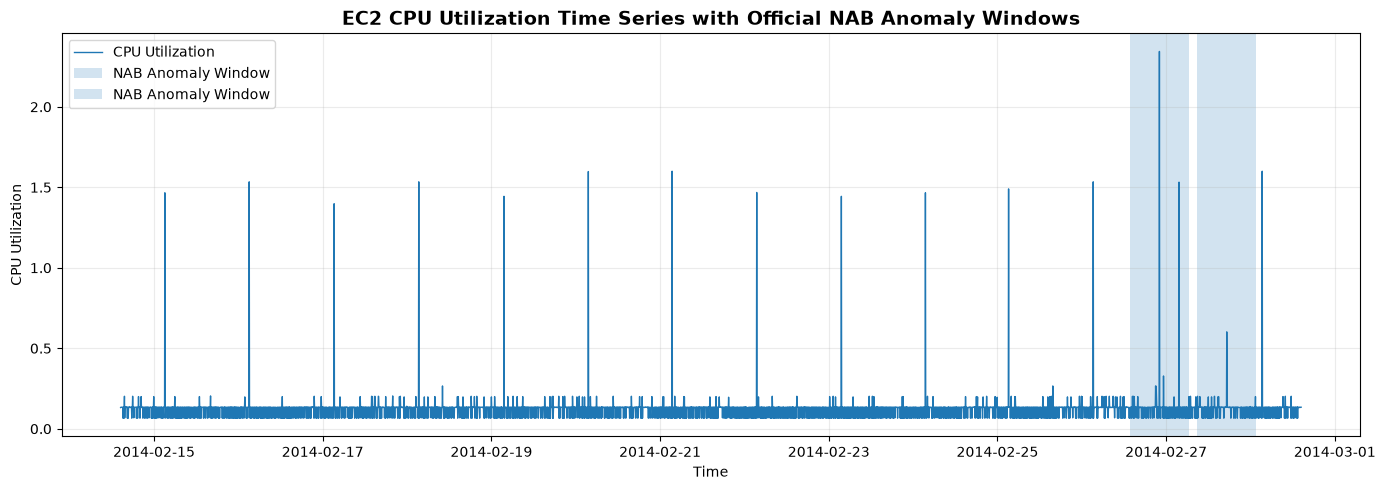

Saved: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/figures/01_time_series_overview.png


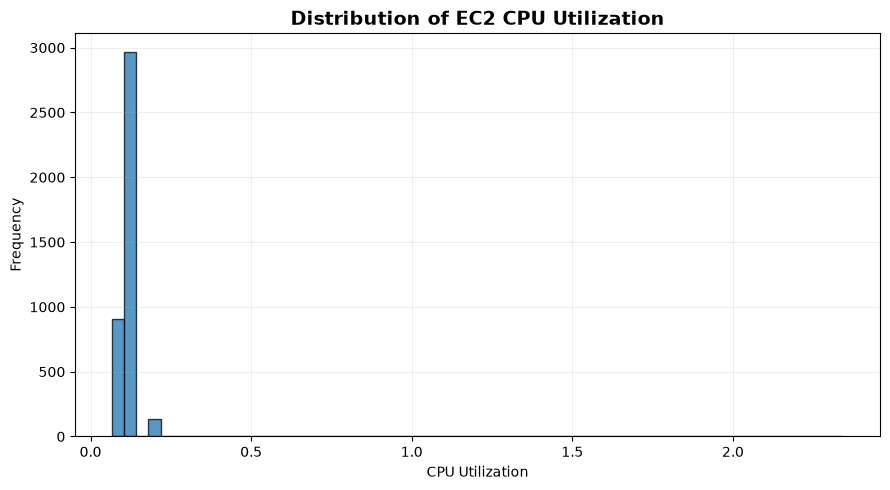

Saved: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/figures/02_cpu_distribution.png


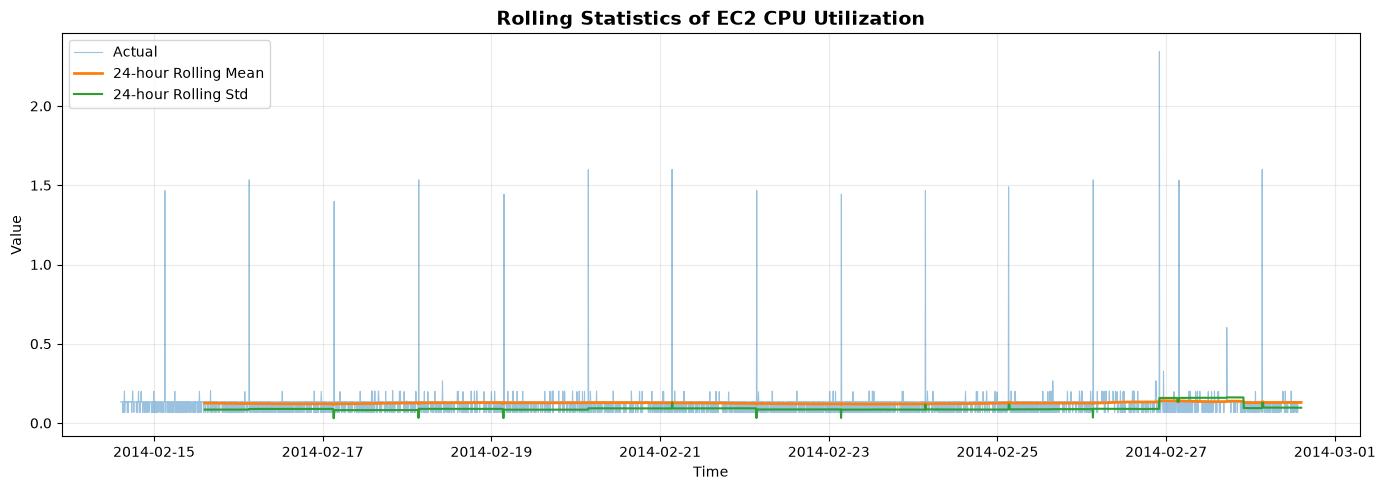

Saved: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/figures/03_rolling_statistics.png


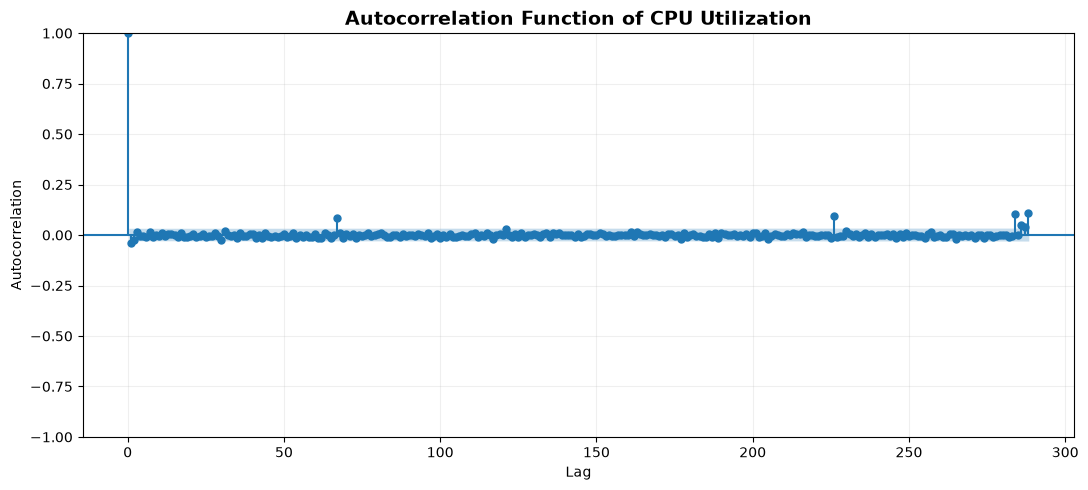

Saved: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/figures/04_acf.png


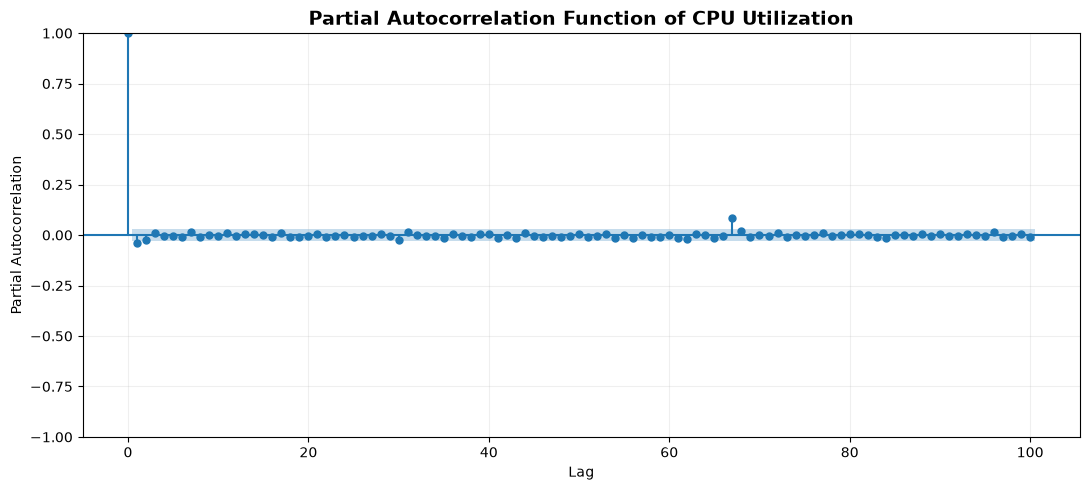

Saved: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/figures/05_pacf.png


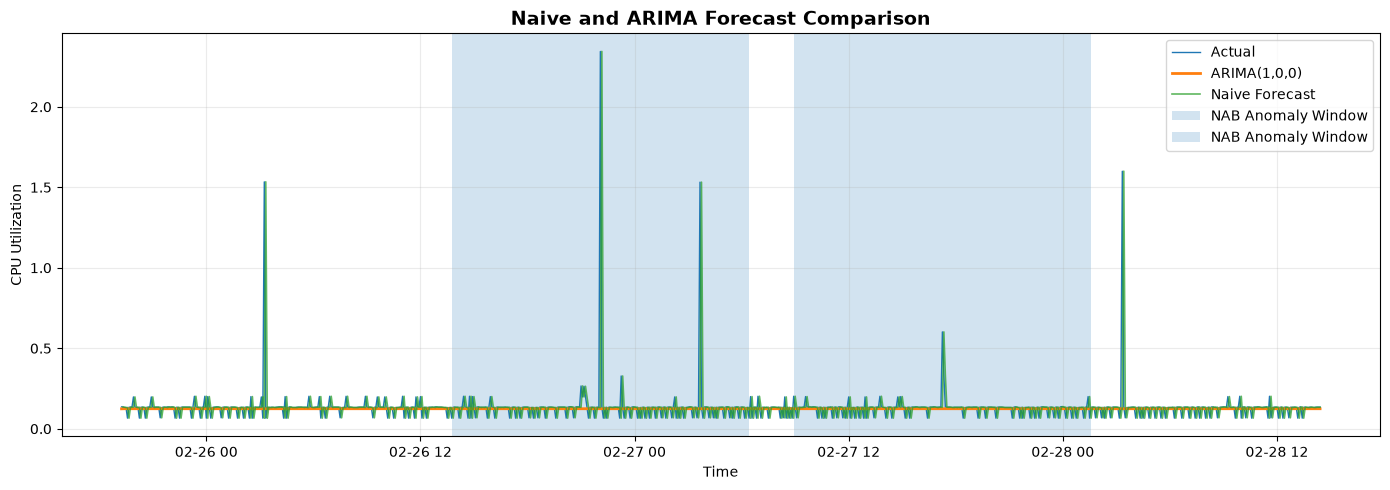

Saved: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/figures/06_naive_vs_arima_forecast.png


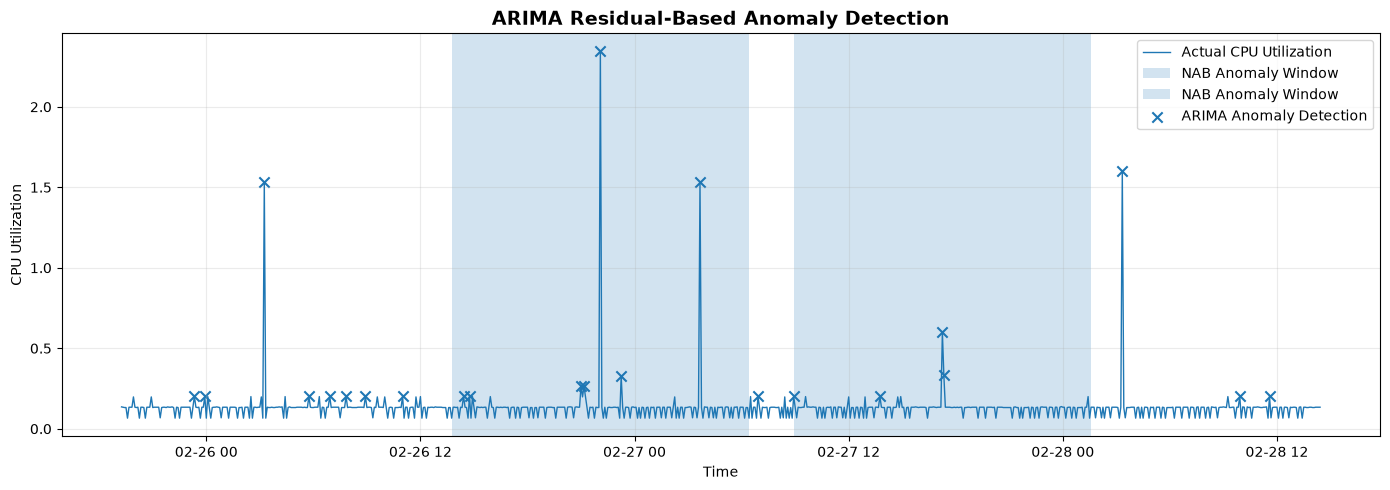

Saved: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/figures/07_arima_anomaly_detection.png


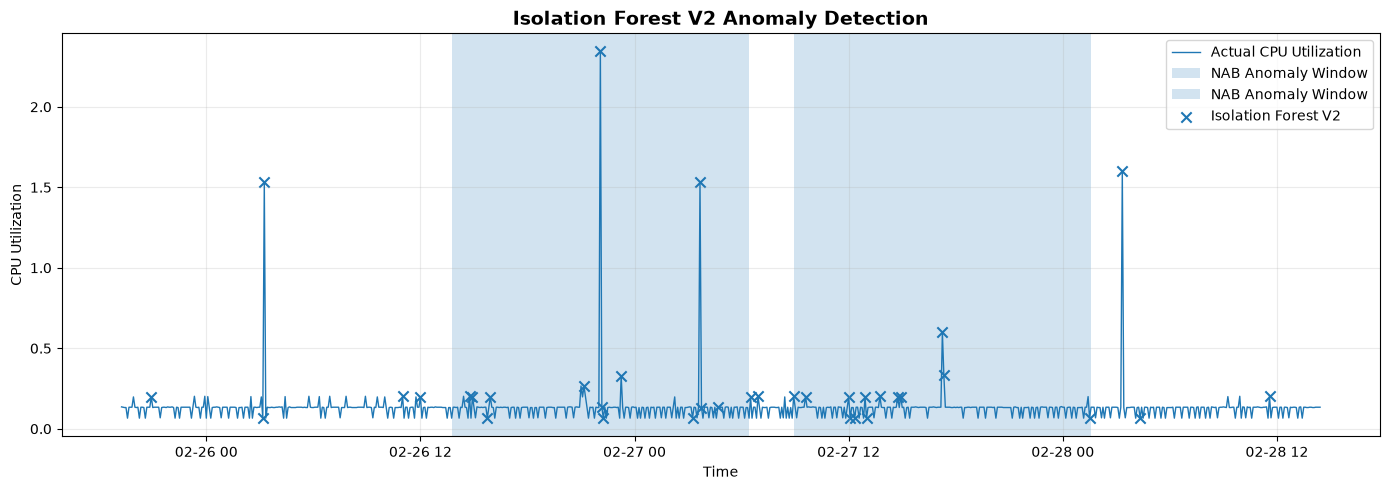

Saved: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/figures/08_isolation_forest_v2.png


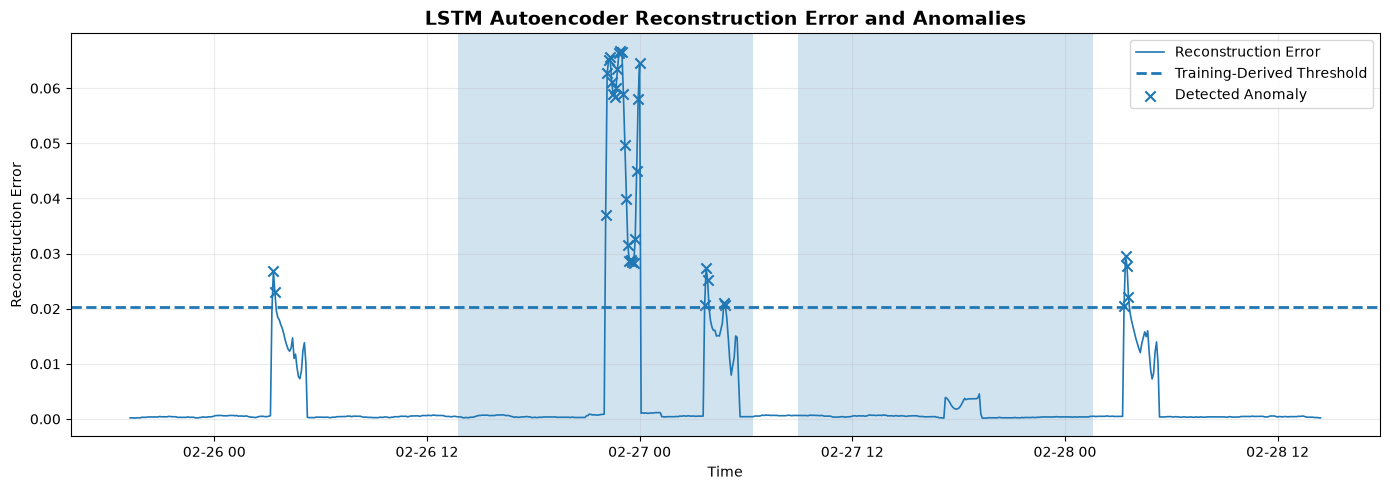

Saved: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/figures/09_lstm_autoencoder.png


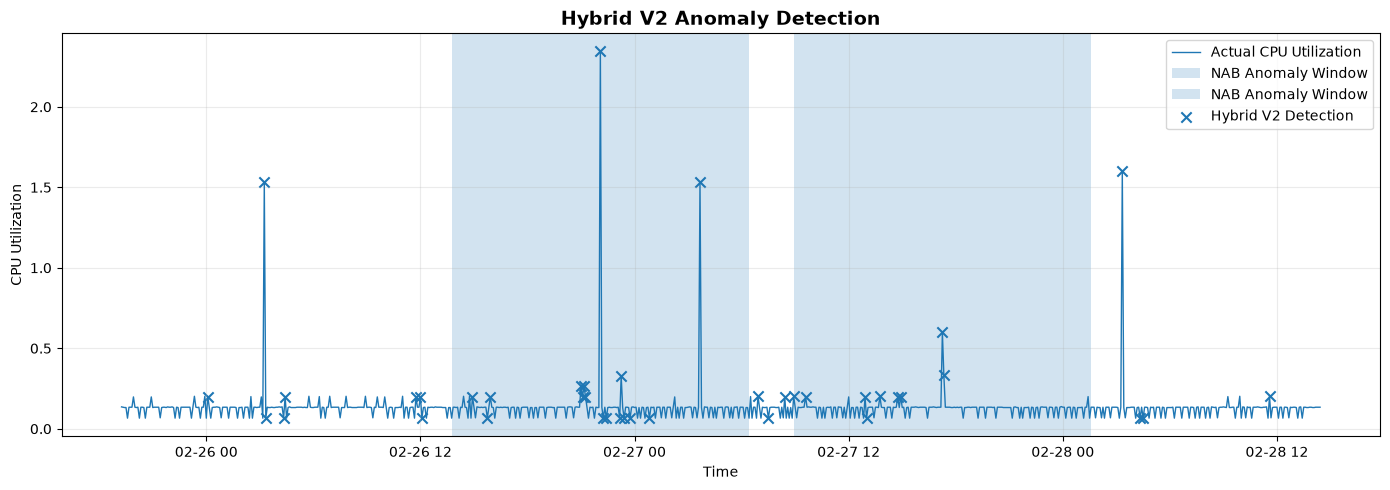

Saved: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/figures/10_hybrid_v2.png


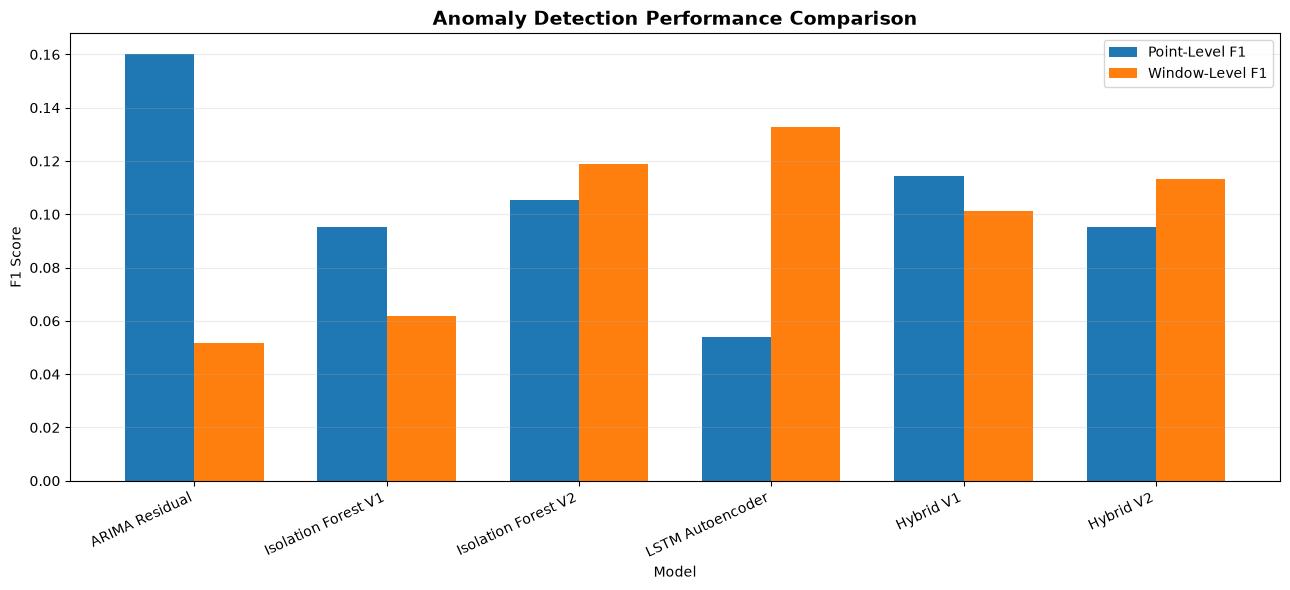

Saved: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/figures/11_model_performance_comparison.png


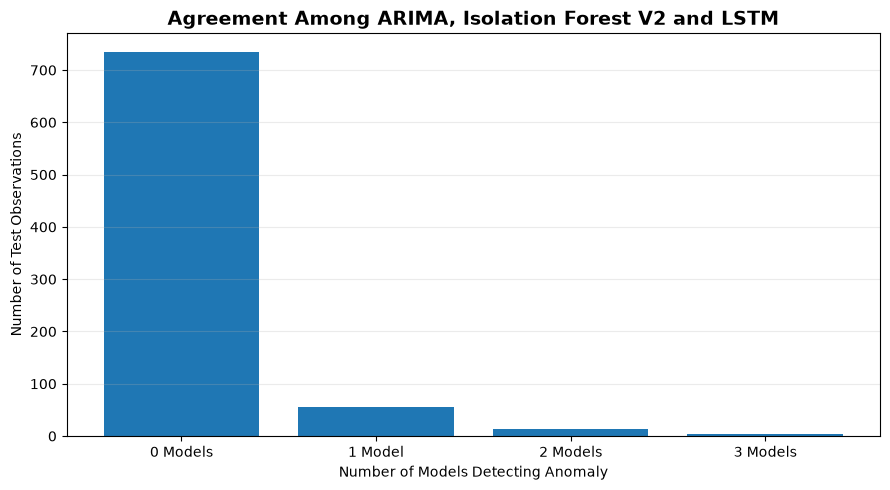

Saved: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/figures/12_model_agreement.png


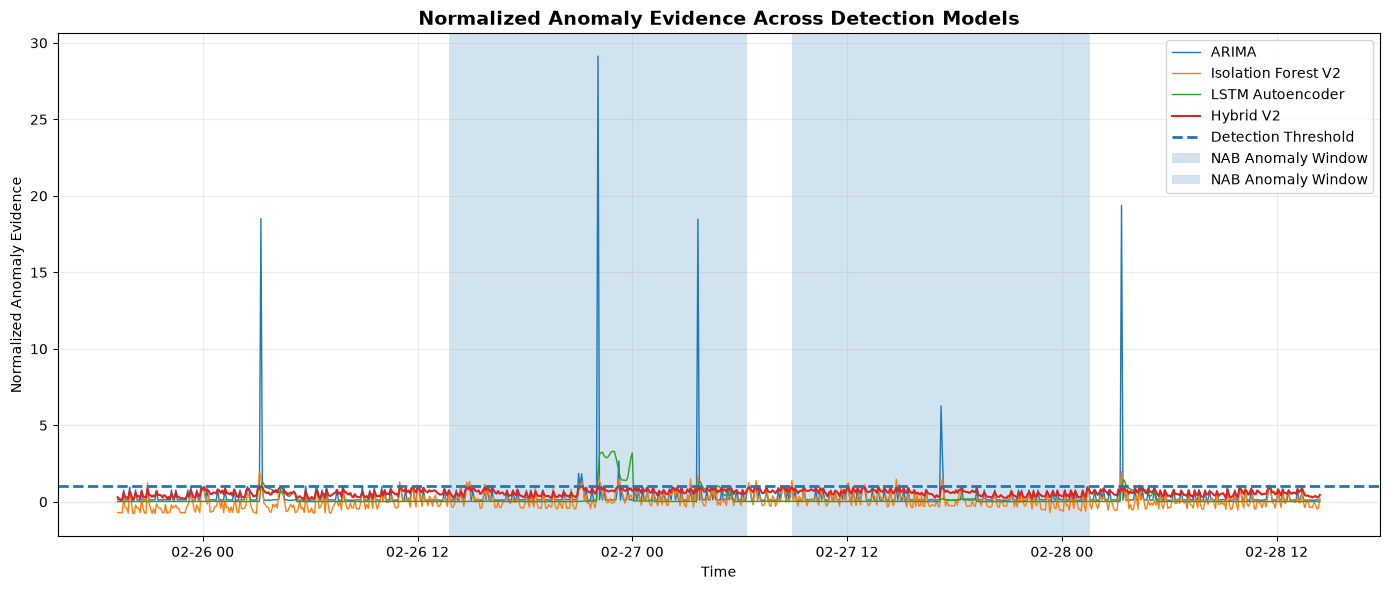

Saved: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/figures/13_anomaly_score_analysis.png


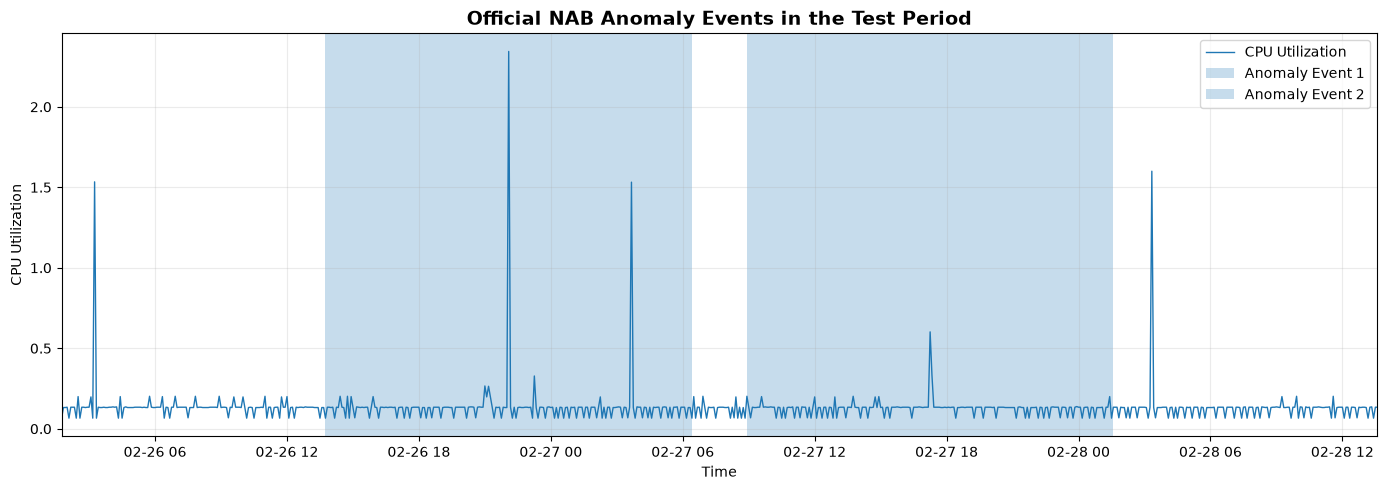

Saved: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/figures/14_anomaly_events.png

ALL REPORT FIGURES GENERATED SUCCESSFULLY
✓ 01_time_series_overview.png
✓ 02_cpu_distribution.png
✓ 03_rolling_statistics.png
✓ 04_acf.png
✓ 05_pacf.png
✓ 06_naive_vs_arima_forecast.png
✓ 07_arima_anomaly_detection.png
✓ 08_isolation_forest_v2.png
✓ 09_lstm_autoencoder.png
✓ 10_hybrid_v2.png
✓ 11_model_performance_comparison.png
✓ 12_model_agreement.png
✓ 13_anomaly_score_analysis.png
✓ 14_anomaly_events.png

Total figures created: 14
Location: /Users/rozykulislam/Downloads/TimeSeries_Anomaly_Project/figures


In [582]:
# ============================================================
# FINAL REPORT FIGURES
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent
FIGURES_DIR = PROJECT_ROOT / "figures"
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
NAB_DIR = DATA_DIR / "nab"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figures will be saved to:", FIGURES_DIR)


# ------------------------------------------------------------
# 2. Load dataset
# ------------------------------------------------------------

raw_path = NAB_DIR / "ec2_cpu_utilization_24ae8d.csv"

df = pd.read_csv(raw_path)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print("Dataset loaded:", df.shape)


# ------------------------------------------------------------
# 3. Load official NAB anomaly windows
# ------------------------------------------------------------

windows_path = NAB_DIR / "combined_windows.json"

with open(windows_path, "r") as f:
    windows_data = json.load(f)

series_key = "realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv"

windows = windows_data[series_key]

parsed_windows = []

for window in windows:
    start = pd.to_datetime(window[0])
    end = pd.to_datetime(window[1])
    parsed_windows.append((start, end))

print("Official anomaly windows:", len(parsed_windows))


# ------------------------------------------------------------
# Helper function: shade anomaly windows
# ------------------------------------------------------------

def add_anomaly_windows(ax):
    for start, end in parsed_windows:
        ax.axvspan(
            start,
            end,
            alpha=0.20,
            label="NAB Anomaly Window"
        )


def save_figure(fig, filename):
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", path)


# ============================================================
# FIGURE 1 — Complete Time-Series Overview
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df["timestamp"],
    df["value"],
    linewidth=1,
    label="CPU Utilization"
)

add_anomaly_windows(ax)

ax.set_title(
    "EC2 CPU Utilization Time Series with Official NAB Anomaly Windows",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Time")
ax.set_ylabel("CPU Utilization")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

save_figure(fig, "01_time_series_overview.png")


# ============================================================
# FIGURE 2 — Distribution of CPU Utilization
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    df["value"],
    bins=60,
    edgecolor="black",
    alpha=0.75
)

ax.set_title(
    "Distribution of EC2 CPU Utilization",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("CPU Utilization")
ax.set_ylabel("Frequency")
ax.grid(alpha=0.20)

fig.tight_layout()

save_figure(fig, "02_cpu_distribution.png")


# ============================================================
# FIGURE 3 — Rolling Mean and Standard Deviation
# ============================================================

rolling_window = 288

df["rolling_mean_24h"] = (
    df["value"]
    .rolling(rolling_window)
    .mean()
)

df["rolling_std_24h"] = (
    df["value"]
    .rolling(rolling_window)
    .std()
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df["timestamp"],
    df["value"],
    alpha=0.45,
    linewidth=0.8,
    label="Actual"
)

ax.plot(
    df["timestamp"],
    df["rolling_mean_24h"],
    linewidth=2,
    label="24-hour Rolling Mean"
)

ax.plot(
    df["timestamp"],
    df["rolling_std_24h"],
    linewidth=1.5,
    label="24-hour Rolling Std"
)

ax.set_title(
    "Rolling Statistics of EC2 CPU Utilization",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

save_figure(fig, "03_rolling_statistics.png")


# ============================================================
# FIGURE 4 — Autocorrelation Function
# ============================================================

clean_values = df["value"].dropna()

fig, ax = plt.subplots(figsize=(11, 5))

plot_acf(
    clean_values,
    lags=288,
    ax=ax,
    alpha=0.05
)

ax.set_title(
    "Autocorrelation Function of CPU Utilization",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
ax.grid(alpha=0.20)

fig.tight_layout()

save_figure(fig, "04_acf.png")


# ============================================================
# FIGURE 5 — Partial Autocorrelation Function
# ============================================================

fig, ax = plt.subplots(figsize=(11, 5))

plot_pacf(
    clean_values,
    lags=100,
    ax=ax,
    alpha=0.05,
    method="ywm"
)

ax.set_title(
    "Partial Autocorrelation Function of CPU Utilization",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Lag")
ax.set_ylabel("Partial Autocorrelation")
ax.grid(alpha=0.20)

fig.tight_layout()

save_figure(fig, "05_pacf.png")


# ============================================================
# FIGURE 6 — Naive vs ARIMA Forecast
# ============================================================

arima_path = PROCESSED_DIR / "arima_test_results.csv"

arima_df = pd.read_csv(arima_path)
arima_df["timestamp"] = pd.to_datetime(arima_df["timestamp"])

arima_df["naive_forecast"] = arima_df["value"].shift(1)

forecast_plot = arima_df.copy()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    forecast_plot["timestamp"],
    forecast_plot["value"],
    linewidth=1,
    label="Actual"
)

ax.plot(
    forecast_plot["timestamp"],
    forecast_plot["forecast"],
    linewidth=2,
    label="ARIMA(1,0,0)"
)

ax.plot(
    forecast_plot["timestamp"],
    forecast_plot["naive_forecast"],
    linewidth=1.2,
    alpha=0.75,
    label="Naive Forecast"
)

add_anomaly_windows(ax)

ax.set_title(
    "Naive and ARIMA Forecast Comparison",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Time")
ax.set_ylabel("CPU Utilization")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

save_figure(fig, "06_naive_vs_arima_forecast.png")


# ============================================================
# FIGURE 7 — ARIMA Residual-Based Anomaly Detection
# ============================================================

ARIMA_THRESHOLD = 0.07615334829925355

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    arima_df["timestamp"],
    arima_df["value"],
    linewidth=1,
    label="Actual CPU Utilization"
)

add_anomaly_windows(ax)

arima_anomalies = arima_df[
    arima_df["absolute_error"] >= ARIMA_THRESHOLD
]

ax.scatter(
    arima_anomalies["timestamp"],
    arima_anomalies["value"],
    marker="x",
    s=55,
    label="ARIMA Anomaly Detection"
)

ax.set_title(
    "ARIMA Residual-Based Anomaly Detection",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Time")
ax.set_ylabel("CPU Utilization")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

save_figure(fig, "07_arima_anomaly_detection.png")


# ============================================================
# FIGURE 8 — Isolation Forest V2
# ============================================================

if_path = PROCESSED_DIR / "isolation_forest_test_results.csv"

if_df = pd.read_csv(if_path)
if_df["timestamp"] = pd.to_datetime(if_df["timestamp"])

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    if_df["timestamp"],
    if_df["value"],
    linewidth=1,
    label="Actual CPU Utilization"
)

add_anomaly_windows(ax)

if_anomalies = if_df[
    if_df["predicted_anomaly"] == 1
]

ax.scatter(
    if_anomalies["timestamp"],
    if_anomalies["value"],
    marker="x",
    s=55,
    label="Isolation Forest V2"
)

ax.set_title(
    "Isolation Forest V2 Anomaly Detection",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Time")
ax.set_ylabel("CPU Utilization")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

save_figure(fig, "08_isolation_forest_v2.png")


# ============================================================
# FIGURE 9 — LSTM Autoencoder
# ============================================================

lstm_path = PROCESSED_DIR / "lstm_test_results.csv"

lstm_df = pd.read_csv(lstm_path)
lstm_df["timestamp"] = pd.to_datetime(lstm_df["timestamp"])

LSTM_THRESHOLD = 0.020251801330746014

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    lstm_df["timestamp"],
    lstm_df["reconstruction_error"],
    linewidth=1.2,
    label="Reconstruction Error"
)

ax.axhline(
    LSTM_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label="Training-Derived Threshold"
)

anomalies_lstm = lstm_df[
    lstm_df["predicted_anomaly"] == 1
]

ax.scatter(
    anomalies_lstm["timestamp"],
    anomalies_lstm["reconstruction_error"],
    marker="x",
    s=55,
    label="Detected Anomaly"
)

for start, end in parsed_windows:
    ax.axvspan(
        start,
        end,
        alpha=0.20
    )

ax.set_title(
    "LSTM Autoencoder Reconstruction Error and Anomalies",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Time")
ax.set_ylabel("Reconstruction Error")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

save_figure(fig, "09_lstm_autoencoder.png")


# ============================================================
# FIGURE 10 — Hybrid V2
# ============================================================

hybrid_path = PROCESSED_DIR / "hybrid_test_results.csv"

hybrid_df = pd.read_csv(hybrid_path)
hybrid_df["timestamp"] = pd.to_datetime(hybrid_df["timestamp"])

HYBRID_THRESHOLD = 0.9321572769953052

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    hybrid_df["timestamp"],
    hybrid_df["value"],
    linewidth=1,
    label="Actual CPU Utilization"
)

add_anomaly_windows(ax)

hybrid_anomalies = hybrid_df[
    hybrid_df["hybrid_v2_score"] >= HYBRID_THRESHOLD
]

ax.scatter(
    hybrid_anomalies["timestamp"],
    hybrid_anomalies["value"],
    marker="x",
    s=55,
    label="Hybrid V2 Detection"
)

ax.set_title(
    "Hybrid V2 Anomaly Detection",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Time")
ax.set_ylabel("CPU Utilization")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

save_figure(fig, "10_hybrid_v2.png")


# ============================================================
# FIGURE 11 — Model Performance Comparison
# ============================================================

results = pd.DataFrame({
    "Model": [
        "ARIMA Residual",
        "Isolation Forest V1",
        "Isolation Forest V2",
        "LSTM Autoencoder",
        "Hybrid V1",
        "Hybrid V2"
    ],
    "Point F1": [
        0.1600,
        0.0952,
        0.1053,
        0.0541,
        0.1143,
        0.0952
    ],
    "Window F1": [
        0.0518,
        0.0618,
        0.1187,
        0.1327,
        0.1011,
        0.1131
    ]
})

x = np.arange(len(results))
width = 0.36

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(
    x - width / 2,
    results["Point F1"],
    width,
    label="Point-Level F1"
)

ax.bar(
    x + width / 2,
    results["Window F1"],
    width,
    label="Window-Level F1"
)

ax.set_title(
    "Anomaly Detection Performance Comparison",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Model")
ax.set_ylabel("F1 Score")
ax.set_xticks(x)
ax.set_xticklabels(results["Model"], rotation=25, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

save_figure(fig, "11_model_performance_comparison.png")


# ============================================================
# FIGURE 12 — Model Agreement
# ============================================================

agreement = pd.DataFrame({
    "Agreement": [
        "0 Models",
        "1 Model",
        "2 Models",
        "3 Models"
    ],
    "Count": [
        734,
        56,
        13,
        4
    ]
})

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    agreement["Agreement"],
    agreement["Count"]
)

ax.set_title(
    "Agreement Among ARIMA, Isolation Forest V2 and LSTM",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Number of Models Detecting Anomaly")
ax.set_ylabel("Number of Test Observations")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

save_figure(fig, "12_model_agreement.png")


# ============================================================
# FIGURE 13 — Normalized Anomaly Score Comparison
# ============================================================

score_df = hybrid_df.copy()

score_df["ARIMA Score"] = (
    score_df["arima_score"] / ARIMA_THRESHOLD
)

score_df["Isolation Forest V2 Score"] = (
    score_df["iso_v2_score"] / 0.08179236078011909
)

score_df["LSTM Score"] = (
    score_df["lstm_score"] / LSTM_THRESHOLD
)

score_df["Hybrid V2 Score"] = score_df["hybrid_v2_score"]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    score_df["timestamp"],
    score_df["ARIMA Score"],
    linewidth=1,
    label="ARIMA"
)

ax.plot(
    score_df["timestamp"],
    score_df["Isolation Forest V2 Score"],
    linewidth=1,
    label="Isolation Forest V2"
)

ax.plot(
    score_df["timestamp"],
    score_df["LSTM Score"],
    linewidth=1,
    label="LSTM Autoencoder"
)

ax.plot(
    score_df["timestamp"],
    score_df["Hybrid V2 Score"],
    linewidth=1.5,
    label="Hybrid V2"
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=2,
    label="Detection Threshold"
)

add_anomaly_windows(ax)

ax.set_title(
    "Normalized Anomaly Evidence Across Detection Models",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Time")
ax.set_ylabel("Normalized Anomaly Evidence")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

save_figure(fig, "13_anomaly_score_analysis.png")


# ============================================================
# FIGURE 14 — Two Anomaly Events
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df["timestamp"],
    df["value"],
    linewidth=1,
    label="CPU Utilization"
)

for i, (start, end) in enumerate(parsed_windows, start=1):

    ax.axvspan(
        start,
        end,
        alpha=0.25,
        label=f"Anomaly Event {i}"
    )

ax.set_xlim(
    parsed_windows[0][0] - pd.Timedelta(hours=12),
    parsed_windows[-1][1] + pd.Timedelta(hours=12)
)

ax.set_title(
    "Official NAB Anomaly Events in the Test Period",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Time")
ax.set_ylabel("CPU Utilization")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

save_figure(fig, "14_anomaly_events.png")


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("ALL REPORT FIGURES GENERATED SUCCESSFULLY")
print("=" * 60)

figure_files = sorted(FIGURES_DIR.glob("*.png"))

for file in figure_files:
    print("✓", file.name)

print(f"\nTotal figures created: {len(figure_files)}")
print(f"Location: {FIGURES_DIR.resolve()}")